# Simulador de sesgos conductuales: efecto disposición y exceso de confianza

**Proyecto 1 — Decision-Making Foundations & Behavioral Finance (ITESO), Prof. Luis Felipe Gómez Estrada.**
Pista principal: **A (efecto disposición)**; la pista B (exceso de confianza) se ejecuta completa como estimador de control cruzado.

| Rol | Responsable de |
|---|---|
| **[SIM] Arquitecto de simulación** | proceso generador de datos: precios, agentes, costos, mecanismos inyectados, reproducibilidad y la restricción de no-información |
| **[ECON] Econometrista conductual** | contabilidad PGR/PLR y sus convenciones, bootstrap por cuenta, regresiones de rotación brutas y netas, errores estándar, diagnóstico de la pendiente bruta |
| **[REF] Árbitro / editor científico** | pre-análisis, interpretación de cada escenario, límites de los estimadores y conclusiones |

**Fecha:** 10 de septiembre de 2026 · **Semilla maestra:** `20260910` · **Tiempo de ejecución:** ≈ 7.7 min en la última ejecución completa (la cifra exacta de esta ejecución está en la última celda).

**Cómo correrlo.** El simulador es `simulador.py`: `python simulador.py` corre los ocho escenarios con sus estimadores y guarda la tabla de resultados en `resultados/tabla_simulador.csv` (≈ 1 min). El informe completo es este cuaderno: se abre en Jupyter desde `C:\ifi\5\Comportamiento\proyecto_1` y se ejecuta con *Restart & Run All*. Reescribe `simulador.py` y los tres módulos que importa (`simlib_precios.py`, `simlib_agentes.py`, `simlib_estimadores.py`), las figuras (`figuras/`) y las tablas (`resultados/`), y exporta `informe.md`. Requiere Python ≥ 3.10 con numpy, pandas, scipy y matplotlib; las versiones usadas se imprimen abajo y en la última celda.

In [1]:
import hashlib
import json
import platform
import time
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
import scipy

RUN_START = time.perf_counter()
MASTER_SEED = 20260910
ROOT = Path.cwd()
assert (ROOT / "simulador_sesgos_conductuales.ipynb").exists(), "run the notebook from its own folder (proyecto_1)"
for sub in ("figuras", "resultados"):
    (ROOT / sub).mkdir(exist_ok=True)
# Keep the master table of the previous run (if any) to prove reproducibility at the end.
PREV_MASTER = ROOT / "resultados" / "tabla_maestra.csv"
previous_master = pd.read_csv(PREV_MASTER) if PREV_MASTER.exists() else None
VERSIONS = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__}
print(" | ".join(f"{k} {v}" for k, v in VERSIONS.items()), f"| semilla maestra {MASTER_SEED}")

python 3.11.9 | numpy 2.4.4 | pandas 2.2.3 | scipy 1.15.3 | matplotlib 3.10.3 | semilla maestra 20260910


## 1. Resumen ejecutivo
**[REF]**

**Qué se inyectó.** Dos sesgos con magnitudes registradas antes de ver resultados:
* disposición $\delta$: el riesgo diario de venta se multiplica por $1\pm\delta$ según el signo frente al costo;
* sobre-precisión $\kappa$: escala el riesgo base.

Se aplicaron a 1,000 cuentas por escenario, sobre 100 valores y 756 días de un modelo de factores con alfa cero, y se recuperaron con los estimadores de Odean (1998) y Barber–Odean (2000).

**Qué se recuperó.**
* PGR − PLR crece con $\delta$ (E2 0.0276, E3 0.0846), y la razón de E2 (1.76) coincide con $(1+\delta)/(1-\delta)=1.86$.
* El nulo queda quieto (E1: 0.0007).
* La pendiente neta mide el costo por unidad de rotación (≈ −1.17 pp).
* La prueba de fuga es nula (p = 0.56).

**Qué se rompió.**
1. Rebalanceo y creencia en reversión, ambos con $\delta=0$, producen una disposición "significativa" (E7 0.0314, E8 0.0236). En E7, contar un recorte como una realización completa fabrica casi todo el efecto: con la convención fraccional queda en 0.0067.
2. Con disposición, la MCO de rotación da una β neta de **+4.30** ("operar paga") por causalidad inversa. La IV con la intensidad *ex ante* la corrige (-0.10).
3. PGR − PLR depende de la historia del mercado. Con $\delta=0.8$, su dispersión entre 20 mundos es 18.67 veces el error estándar del bootstrap por cuenta, que sólo vale condicional a la trayectoria.
4. La β neta no mide la dosis de $\kappa$: su pendiente de costos queda plana entre E4 y E5.
5. $\kappa$ infla PGR − PLR sin tocar $\delta$ (E6).

En el nulo, la β bruta rechaza al 5 %. El Monte Carlo lo identifica como un error tipo I (0 rechazos en 20 mundos), y se reporta sin cambiar la semilla. Se acertaron 33 de 38 predicciones registradas.

## 2. Lectura de fuentes
**[REF]** La carpeta del curso (`C:\ifi\5\Comportamiento`, un nivel arriba de `proyecto_1`) contiene cuatro presentaciones Beamer; ninguna es un resumen de artículo. De cada una se tomó lo siguiente.

| Archivo | Qué es | Qué se tomó |
|---|---|---|
| `001-vnm.tex` | Utilidad esperada, axiomas vNM, Arrow–Pratt, CRRA/CARA, Allais, Rabin | Ningún requisito del proyecto. Tema recurrente usado en §7.5: una aproximación local (aquí $PGR/PLR\approx(1+\delta)/(1-\delta)$) extrapolada fuera de su rango falla. |
| `002-mean-variance.tex` | Markowitz, Merton (1980), Chopra–Ziemba, Jagannathan–Ma | Definición de rotación $\tfrac12\sum_i\lvert\Delta w_i\rvert$ (usada: ½·(compras+ventas)/riqueza). El error estándar de una media es $\sigma/\sqrt{T}$: con 3 años la prueba de fuga sólo detecta fugas de decenas de puntos base. |
| `003-prospect-theory.tex` | Función de valor ($\alpha=\beta=0.88$, $\lambda=2.25$), ponderación de probabilidades, punto de referencia | **Odean (1998): PGR = 0.148, PLR = 0.098** (razón 1.51, diferencia 0.050). El precio de compra como punto de referencia; "el punto de referencia no está modelado". |
| `004-behavioral-biases.tex` | **La consigna del Proyecto 1** y la evidencia de sesgos | Pistas A (PGR/PLR) y B (rendimiento neto contra rotación, comparando coeficientes bruto y neto); "estimar con el error estándar correcto y descartar al menos dos explicaciones rivales"; pre-análisis antes de ver resultados; máximo 6 páginas y código reproducible; "un nulo limpio vale más que un resultado significativo con un confusor sin atender". Referencias: Barber–Odean (2000): rendimiento bruto plano por quintil de rotación y **6.5 puntos/año** perdidos por el quintil más activo (17.9 / 16.4 / 11.4 %); Odean (1999): lo comprado rindió **3.2 puntos menos** que lo vendido al año siguiente, antes de costos; Barber–Odean (2001): género como instrumento (hombres operan 45 % más); Barberis–Xiong (2009): la teoría prospectiva no implica limpiamente el efecto; Grinblatt–Han (2005): el *overhang* de ganancias absorbe buena parte del momento; explicaciones rivales: utilidad de realización, creencia en reversión, aversión al arrepentimiento, motivo fiscal (que predice lo contrario salvo en diciembre). |

**Discrepancias con el prompt (según la regla, ganan los `.tex`):**
1. **"Dos pistas, elija una."** El prompt pide ambos estimadores. Se declara **A** como hipótesis principal y B como estimador de control cruzado. Correr ambos no contradice la consigna; es lo que permite la validación cruzada del §7.5.
2. **"Máximo 6 páginas."** `informe.md` es el entregable de ≤ 6 páginas (celdas marcadas `informe` más la tabla maestra); este cuaderno es el código reproducible y el apéndice técnico completo.
3. **Rúbrica y ponderaciones:** los `.tex` remiten a "the handout", que no está en la carpeta. No hay ponderaciones que extraer; se usan las prioridades del prompt como sustituto.
4. **Notación:** $\delta_i,\kappa_i,W_i,n_i$ y la tabla de escenarios sólo existen en el prompt. En los `.tex`, $\beta$ es la curvatura del brazo de pérdidas; aquí $\beta$ es la pendiente de rotación y la curvatura se llamaría $\alpha_{PT}$ (no se usa, porque el mecanismo principal es el (A)).

## 3. Diseño del simulador
**[SIM]**

**En una línea.** Una trayectoria de precios de un modelo de factores con alfa cero se genera **antes** que los agentes. Sobre ella, 1,000 cuentas por escenario operan con un riesgo diario de venta que se multiplica por $1+\delta$ sobre el costo promedio y por $1-\delta$ debajo de él; $\kappa$ escala el riesgo base. Recompran valores elegidos al azar el mismo día y pagan comisión y diferencial. El econometrista recibe sólo el "estado de cuenta": fotografías previas a la operación en cada día de venta, operaciones y valores diarios. El diseño está implementado en `simulador.py`, el archivo principal, que importa `simlib_precios.py` (precios), `simlib_agentes.py` (agentes y mecanismo inyectado) y `simlib_estimadores.py` (estimadores).

### 3.1 Precios: modelo de un factor de mercado más tres factores de estilo
$$r_{s,t}=\beta_s\left(\tfrac{\mu_M}{252}+f_{M,t}\right)+\textstyle\sum_{k=1}^{3}b_{s,k}f_{k,t}+\varepsilon_{s,t},\qquad f_M\sim\mathcal N\!\left(0,\tfrac{0.16^2}{252}\right),\; f_k\sim\mathcal N\!\left(0,\tfrac{0.05^2}{252}\right),\; \varepsilon_{s,t}\sim\mathcal N\!\left(0,\tfrac{\sigma_{\varepsilon,s}^2}{252}\right)$$

* 100 valores, 756 días hábiles (3 años). $\beta_s\sim\mathcal N(1,0.3^2)$ truncada a $[0.3,1.8]$, $b_{s,k}\sim\mathcal N(0,1)$, $\sigma_{\varepsilon,s}\sim U(20\%,40\%)$, $\mu_M=7\,\%$ anual, tasa libre 0 (todo es rendimiento en exceso). Los precios iniciales son log-uniformes entre \$10 y \$150 y se cotizan al centavo.
* **$E[r_s]=\beta_s\mu_M$: el alfa de todos los valores es cero.** Los rendimientos esperados sólo difieren por riesgo de mercado remunerado y los factores de estilo no tienen prima. "Nadie opera informado" significa aquí que no existe alfa que encontrar.
* Correlación promedio por pares: 0.18 implícita y 0.19 realizada. Volatilidad total media: 34.5 % anual. El mercado realizado en esta trayectoria rindió **2.1 %/año**, con volatilidad de 16.4 %.

**Qué cambia frente a un GBM i.i.d.**
1. Los choques comunes hacen que las cuentas **no sean independientes** (comparten valores), así que los SE transversales pueden quedarse cortos; esto se mide en §7.5.
2. Con betas heterogéneas, rotar cartera cambia la exposición al mercado. Vender ganadoras en un mercado al alza baja la beta, de modo que la rotación es un *proxy* ruidoso del riesgo y el control de beta de la regresión tiene algo real que absorber (§9.4).
3. Toda la muestra es **una** realización del mercado, y de ella depende cuánto pesa el arrastre de caja (§9).

### 3.2 Agentes

| Primitivo | Distribución | Justificación |
|---|---|---|
| $W_i$ capital inicial | log-uniforme en [\$10,000, \$500,000] | La riqueza es sesgada a la derecha; cada orden de magnitud es igual de probable. Cubre desde cuentas minoristas pequeñas hasta grandes. |
| $n_i$ posiciones | entero uniforme {5,…,30} | Rango del enunciado. Es independiente de $W_i$, así que el tamaño de posición $W_i/n_i$ varía de \$333 a \$100,000 y la comisión fija genera heterogeneidad real de costos. |
| $\ell_i$ intensidad base | $U(0.25,1.25)$ ventas por posición y año | Necesidad de liquidez exógena. Da variación *ex ante* de la rotación en todos los escenarios (incluso con $\kappa=0$), y es lo que hace posible el instrumento del §9. |
| $\delta_i$ disposición | **constante poblacional** en E1–E8; $U(0,1)$ en E9 | "δ = 0.3" se lee como constante: cada cuenta tiene exactamente el valor inyectado. E9 agrega la variación transversal que exigen los diagnósticos del §10. |
| $\kappa_i$ sobre-precisión | igual que $\delta_i$ | $h_{0,i}=\ell_i(1+3\kappa_i)/252$: con $\kappa=1$ la intensidad base se cuadruplica. |

$\delta_i$ y $\kappa_i$ salen de **sub-flujos aleatorios distintos** (`child_seed(seed, 0, 3)` y `child_seed(seed, 0, 4)`): son independientes por construcción, no por casualidad. La cópula gaussiana sólo se activa a propósito en la corrida mal especificada del §10.

### 3.3 Costos y la definición de rendimiento bruto y neto
* **Comisión:** \$10 por boleto, de compra o de venta (nivel de un corredor de descuento antes de 2019). Sobre la operación mediana de la muestra, \$2,643, equivale a **38 pb**; sobre la operación media, \$6,487, a 15 pb.
* **Diferencial:** 20 pb cotizados (10 pb por lado), típico de acciones de capitalización media. En dólares son \$0.02 por acción de \$10 y \$0.20 por acción de \$100.
* **Convención (dónde entra el diferencial).** Los precios del simulador son precios *medios*. Las compras se ejecutan a $mid\,(1+s/2)$ y las ventas a $mid\,(1-s/2)$. El rendimiento **bruto** marca todas las posiciones a precio medio, también el día de la operación, así que no contiene comisiones ni diferencial. El costo del diferencial, $\tfrac{s}{2}\times$valor operado a precio medio, va a la línea de costos. **Neto = bruto − (comisiones + diferencial)/riqueza del día anterior**, día por día; con medias aritméticas anualizadas, $r^{neto}_i=r^{bruto}_i-c_i$ es exacta cuenta por cuenta. La versión marcada a precio de ejecución, que es el error definicional, se calcula aparte sólo como ablación (§9).
* La dotación del día 0 se compra a precio medio sin costo y no cuenta como rotación.
* **Rotación** $=\tfrac12(\text{compras}+\text{ventas})$ a precio medio, dividida entre la riqueza media y anualizada. Entran compras y ventas; con reinversión el mismo día son casi iguales.

### 3.4 El mecanismo inyectado y por qué está un nivel debajo de PGR
Cada día, cada posición abierta se vende con probabilidad

$$h_{i,s,t}=h_{0,i}\times\begin{cases}1+\delta_i & mid_{s,t}>c_{i,s}+\$0.005\\ 1-\delta_i & mid_{s,t}<c_{i,s}-\$0.005\\ 1 & \text{empate}\end{cases}$$

donde $c_{i,s}$ es el costo promedio de los lotes abiertos (el punto de referencia del agente). **PGR no se fija en ningún lado.** Es un cociente calculado sólo en días de venta y sobre todas las posiciones, y depende de $\delta$ pero también de $n_i$, de la composición ganadoras/perdedoras que produce la trayectoria de precios y de cuántas ventas caen el mismo día. Si la fracción de ganadoras $f$ fuera igual para todas las cuentas, $PGR\approx(1+\delta)/[n(1+\delta(2f-1))]$ y $PLR\approx(1-\delta)/[n(1+\delta(2f-1))]$: el mapeo $\delta\mapsto PGR-PLR$ ni siquiera es lineal. La rotación también es emergente: $\kappa$ sólo mueve $h_0$.

* **Ventas parciales:** 25 % de las ventas disparadas son recortes del 50 % (si valen ≥ \$100). Lo obtenido compra más de otra posición elegida al azar, y así nacen las posiciones con varios lotes que hacen relevantes las convenciones de base de costo.
* **Recompra (lado comprador):** una salida total se reemplaza por un valor **elegido uniformemente** entre los que la cuenta no posee ni vendió hoy. La elección no usa ninguna información de precios, así que es ortogonal a los rendimientos futuros por construcción.
* **Rezago de redespliegue:** **el mismo día** ($k=0$), sin arrastre de caja. Ablación con $k=21$ días en el §9.

### 3.5 Confusores (E7, E8), ambos con $\delta=0$ y usando sólo precios pasados
* **Rebalanceo (E7):** el objetivo es **peso igual** $1/n_i$ de la riqueza total, con **banda de tolerancia del 25 %**. Si una posición pesa más de $1.25/n_i$, se recorta al objetivo (si el recorte vale ≥ \$100) y lo obtenido compra la posición **más infraponderada**. Las ganadoras se desvían hacia arriba, y recortarlas se ve igual que realizar ganancias.
* **Creencia en reversión (E8):** si el rendimiento de 40 días de un valor supera 12 %, el agente espera una reversión y multiplica su riesgo de venta por 5. **La creencia es falsa**: los choques son i.i.d. y no hay reversión. La regla sólo mira precios pasados.

### 3.6 Pseudocódigo del ciclo diario (cierre del día $t$)
```text
precios[0..T] ya existen; en el día t el agente sólo lee precios[0..t]
para t = 1..T:
    marcar a precio medio -> V_pre ;  r_bruto = V_pre / V_post(t-1) - 1
    para cada posición abierta: signo = sgn(mid_t - costo_promedio)   (empate si |.| < $0.005)
    h = h0 * (1 + delta*signo) * [1 + 4*1(rend_40d > 12%)]          <- factor sólo en E8
    vender si U < h  (25 %: recorte de la mitad);  E7: recortar si peso > 1.25/n
    GUARDAR el estado previo de toda cuenta que vende            <- insumo del econometrista
    liberar lotes FIFO; lo obtenido va a fondos de redespliegue
    liberar los fondos que vencen hoy (k = 0: hoy mismo):
        salida total   -> valor uniforme al azar no poseído
        recorte        -> posición poseída al azar  |  E7: la más infraponderada
    registrar comisiones, diferencial y valor operado -> V_post
```

### 3.7 Escenarios y flujos de semillas
En el texto los escenarios se llaman E1–E8; en el código y en las tablas, `S1`–`S8` (las claves con que se registraron las predicciones). Los ocho escenarios del enunciado regeneran la población completa sobre **la misma trayectoria de precios** (números aleatorios comunes: las diferencias entre escenarios son de comportamiento, no de suerte de mercado). Las corridas adicionales son **agregados, no sustitutos**: E9, población heterogénea con $\delta_i,\kappa_i\sim U(0,1)$ independientes; E9m, la misma con corr($\delta,\kappa$) = 0.6; barridos de $\delta$ y $\kappa$; ablación de caja; mercado GBM; y Monte Carlo sobre trayectorias de precios.

| # | Escenario | $\delta$ | $\kappa$ | Confusor | Expectativa del enunciado |
|---|---|---|---|---|---|
| E1 | Nulo | 0 | 0 | — | ambos estimadores quietos |
| E2 | Disposición baja | 0.3 | 0 | — | disposición positiva, confianza quieta |
| E3 | Disposición alta | 0.8 | 0 | — | disposición positiva y mayor |
| E4 | Rotación baja | 0 | 0.3 | — | disposición quieta, confianza negativa |
| E5 | Rotación alta | 0 | 0.8 | — | confianza más negativa |
| E6 | Ambos | 0.8 | 0.8 | — | interacción |
| E7 | Rebalanceo | 0 | 0 | rebalanceo | disposición espuria |
| E8 | Reversión | 0 | 0 | creencia en reversión | disposición espuria |

## 4. PRE-ANÁLISIS
La celda siguiente se registró (hash SHA-256 y hora UTC) antes de escribir el módulo de estimadores. Se reproduce sin cambios y la celda de código que la sigue verifica que coincide con el registro. El mismo párrafo está copiado, como comentarios (`#`) en texto plano, al inicio de cada archivo `.py` del proyecto.

**[REF] — PRE-ANÁLISIS (registrado antes de ejecutar cualquier estimador; no editado después)**

Inyectamos, con $N=1{,}000$ cuentas por escenario, 100 valores y 756 días, $\delta$ y $\kappa$ como **constantes poblacionales** ($\delta\in\{0,\,0.3,\,0.8\}$, $\kappa\in\{0,\,0.3,\,0.8\}$) sobre un riesgo base diario $h_0=\ell_i(1+3\kappa)/252$ con $\ell_i\sim U(0.25,1.25)$ y multiplicadores $1\pm\delta$ según el dominio respecto del costo promedio; los confusores usan $\delta=\kappa=0$ (rebalanceo: banda de 25 % sobre el peso igual, recorte al objetivo y compra de la posición más infraponderada; reversión: riesgo $\times 5$ si el rendimiento de 40 días supera 12 %). Esperamos, por la aritmética del riesgo condicionado a días de venta, $\widehat{PGR}\approx\widehat{PLR}\approx E[n]/E[n^2]\approx 0.05$ en el nulo y $PGR/PLR\approx(1+\delta)/(1-\delta)$ corregido a la baja por la heterogeneidad de composición: **E1** diferencia con IC que contiene 0 y $\beta_{bruta}$ (MCO e IV) con IC que contiene 0; **E2** diferencia $\approx 0.03$ (0.02–0.04), razón 1.5–2.2; **E3** diferencia $\approx 0.10$ (0.07–0.13), razón 5–11, y **misbehavior esperado**: $\beta_{bruta}^{MCO}>0$ de varios puntos por causalidad inversa, suficiente para que $\beta_{neta}^{MCO}$ no sea negativa, mientras la IV bruta queda en 0; **E4/E5** diferencia en 0 y $\beta_{neta}\approx -1.2$ pp por unidad de rotación anual (rango $-0.7$ a $-1.8$) **igual en ambos**, de modo que anticipamos que el requisito de monotonía de $|\beta_{neta}|$ de 4 a 5 **fallará**: la pendiente mide costo por unidad de rotación, no la dosis de $\kappa$; lo que sí crece es el lastre medio de costos (≈0.8, 1.5 y 2.6 %/año en E1, E4, E5); **E6** diferencia menor que en E3 (carteras más jóvenes, menos acumulación de perdedoras) y razón mayor o igual que en E3, con $\beta_{bruta}^{MCO}>0$ pero diluida respecto de E3; **E7** disposición espuria positiva y significativa (razón 2–5 contando cada recorte como una realización, y al menos 40 % menor con la convención fraccional), $\beta_{bruta}^{MCO}>0$ pequeña; **E8** disposición espuria positiva (razón 1.3–3, diferencia 0.015–0.05) y $\beta_{bruta}^{MCO}>0$. En todos los escenarios esperamos $\beta_{neta}-\beta_{bruta}=-\beta_{costos}$ exacta con rendimientos aritméticos; marcar a precio de ejecución desplaza $\beta_{bruta}$ en exactamente $-0.20$ pp; una ventana de caja de 21 días la desplaza $\approx-(21/252)\times 2.1\,\%\approx-0.2$ pp (el mercado realizado de la trayectoria, conocido porque los precios se generan antes que los agentes, rindió solo 2.1 %/año), probablemente no significativo; la regla de empates afectará menos de 0.1 % de las observaciones; FIFO y lote-por-lote atenuarán la diferencia frente al costo promedio (la referencia del propio agente); el SE por cuenta será ≈ igual al ingenuo en el nulo y mayor cuando $\delta>0$ o hay confusor; la prueba de fuga dará coeficientes nulos (p > 0.05 a 20 y 120 días) y la diferencia comprado-menos-vendido a 252 días será ≈ 0 frente a los −3.2 pp de Odean (1999); en la población heterogénea, corr($\delta,\kappa$) con IC que contiene 0 y corr($\delta$, rotación) negativa; con corr($\delta,\kappa$)=0.6 la $\beta_{bruta}^{MCO}$ sube mientras la IV con $\kappa$ sigue ≈ 0; la curva de recuperación será creciente y convexa en $\delta$, con razón indefinida en $\delta=1$ ($PLR=0$); y la dispersión de $\beta_{bruta}$ entre trayectorias de precios independientes superará el SE bootstrap por cuenta (factor 1.2–3) porque las cuentas comparten valores.

*Antes de este registro solo se ejecutó una prueba mecánica del simulador (identidad contable, tiempo de cómputo y rotación media como calibración del DGP); ningún estimador de PGR/PLR ni de $\beta$ estaba implementado. Nada de lo que aparece debajo de esta celda se usó para revisarla.*

In [2]:
REG = dict(line.split("=", 1) for line in (ROOT / "resultados" / "pre_analisis_registro.txt").read_text().split())
for name in ("pre_analisis.md", "pre_analisis_reglas.json"):
    digest = hashlib.sha256((ROOT / "resultados" / name).read_bytes()).hexdigest()
    print(f"{name:26s} sha256 {digest[:20]}…  coincide con el registro: {digest == REG[name]}")
nb_cells = json.loads((ROOT / "simulador_sesgos_conductuales.ipynb").read_text(encoding="utf-8"))["cells"]
pre_cell = next("".join(c["source"]) for c in nb_cells if "preanalisis" in c["metadata"].get("tags", []))
registered = (ROOT / "resultados" / "pre_analisis.md").read_text(encoding="utf-8").rstrip("\n")
print("La celda de arriba es idéntica al texto registrado:", pre_cell == registered)
print("Registrado (UTC):", REG["registered_utc"])
RULES = json.loads((ROOT / "resultados" / "pre_analisis_reglas.json").read_text(encoding="utf-8"))
pd.DataFrame({k: ["; ".join(" ".join(map(str, r)) for r in v)] for k, v in RULES.items()
              if k != "description"}, index=["predicciones codificadas"]).T

pre_analisis.md            sha256 df22412ecfa7b292bf7d…  coincide con el registro: True
pre_analisis_reglas.json   sha256 ef2be36923492b1f35f1…  coincide con el registro: True
La celda de arriba es idéntica al texto registrado: True
Registrado (UTC): 2026-09-10T23:17:59Z


,predicciones codificadas
S1,diff_ci_contains_0; b_gross_ci_contains_0; iv_...
S2,diff_positive_sig; diff_in 0.02 0.04; ratio_in...
S3,diff_positive_sig; diff_in 0.07 0.13; ratio_in...
S4,diff_ci_contains_0; b_gross_ci_contains_0; b_n...
S5,diff_ci_contains_0; b_gross_ci_contains_0; b_n...
S6,diff_positive_sig; diff_less_than S3; ratio_at...
S7,diff_positive_sig; ratio_in 2.0 5.0; fractiona...
S8,diff_positive_sig; diff_in 0.015 0.05; ratio_i...


## 5. Implementación
**[SIM]** El simulador vive en cuatro archivos `.py` que las celdas `%%writefile` siguientes escriben en la carpeta (`-a` agrega el siguiente bloque al mismo archivo) y que luego se importan:

* **`simulador.py`, el archivo principal.** Define la malla de ocho escenarios, las calibraciones y la semilla maestra. `run_scenario` simula una población y le aplica todos los estimadores, `run_grid` corre los ocho escenarios y `results_table` arma la tabla de resultados. Importa los otros tres módulos y también se puede ejecutar solo: `python simulador.py`.
* `simlib_precios.py`: universo de precios (modelo de factores, cotización al centavo, rendimientos a plazo).
* `simlib_agentes.py`: población, mecanismo inyectado, libro de lotes FIFO y ciclo diario vectorizado sobre cuentas y valores. El único bucle es el de días, que es secuencial por naturaleza.
* `simlib_estimadores.py`: conteos de Odean, bootstraps, regresiones MCO/2SLS con errores HC1 y bootstrap por cuenta, prueba de fuga y diagnósticos.

Cada archivo empieza con el pre-análisis registrado, copiado como comentarios (`#`). Al volver a ejecutar el cuaderno se regeneran los cuatro archivos, así que el cuaderno es autocontenido.

In [3]:
%%writefile simlib_precios.py
"""Price universe for the behavioral-bias simulator.

The whole price path is generated once, before any agent exists, from its own
random stream. Nothing an agent does can feed back into it, which is the
structural half of the "no informed trading" constraint (the statistical half
is the leakage test in ``simlib_estimadores``).

Model: one priced market factor plus ``k`` orthogonal, zero-premium style
factors, heterogeneous loadings and idiosyncratic noise, with CAPM-consistent
drifts (zero alpha for every security).
"""



Overwriting simlib_precios.py


In [4]:
%%writefile -a simlib_precios.py
# ======================================================================================
# PRE-ANALYSIS (registered 2026-09-10T23:17:59Z, before any estimator existed; never
# edited). Official text: resultados/pre_analisis.md (SHA-256 df22412ecfa7b292...).
# This copy renders its LaTeX as plain characters; the wording is unchanged.
# Role of this file: the price universe these expectations are conditioned on (100
#   securities, 756 days, zero alpha; the realized market returned 2.1 %/yr).
# --------------------------------------------------------------------------------------
# [REF] — PRE-ANÁLISIS (registrado antes de ejecutar cualquier estimador; no editado
# después)
#
# Inyectamos, con N = 1,000 cuentas por escenario, 100 valores y 756 días, δ y κ como
# constantes poblacionales (δ ∈ {0, 0.3, 0.8}, κ ∈ {0, 0.3, 0.8}) sobre un riesgo base
# diario h_0=ℓ_i(1+3κ)/252 con ℓ_i ~ U(0.25,1.25) y multiplicadores 1±δ según el dominio
# respecto del costo promedio; los confusores usan δ=κ=0 (rebalanceo: banda de 25 %
# sobre el peso igual, recorte al objetivo y compra de la posición más infraponderada;
# reversión: riesgo × 5 si el rendimiento de 40 días supera 12 %). Esperamos, por la
# aritmética del riesgo condicionado a días de venta, PGR ≈ PLR ≈ E[n]/E[n^2] ≈ 0.05 en
# el nulo y PGR/PLR ≈ (1+δ)/(1-δ) corregido a la baja por la heterogeneidad de
# composición: E1 diferencia con IC que contiene 0 y β_bruta (MCO e IV) con IC que
# contiene 0; E2 diferencia ≈ 0.03 (0.02–0.04), razón 1.5–2.2; E3 diferencia ≈ 0.10
# (0.07–0.13), razón 5–11, y misbehavior esperado: β_bruta^MCO>0 de varios puntos por
# causalidad inversa, suficiente para que β_neta^MCO no sea negativa, mientras la IV
# bruta queda en 0; E4/E5 diferencia en 0 y β_neta ≈ -1.2 pp por unidad de rotación
# anual (rango -0.7 a -1.8) igual en ambos, de modo que anticipamos que el requisito de
# monotonía de |β_neta| de 4 a 5 fallará: la pendiente mide costo por unidad de
# rotación, no la dosis de κ; lo que sí crece es el lastre medio de costos (≈0.8, 1.5 y
# 2.6 %/año en E1, E4, E5); E6 diferencia menor que en E3 (carteras más jóvenes, menos
# acumulación de perdedoras) y razón mayor o igual que en E3, con β_bruta^MCO>0 pero
# diluida respecto de E3; E7 disposición espuria positiva y significativa (razón 2–5
# contando cada recorte como una realización, y al menos 40 % menor con la convención
# fraccional), β_bruta^MCO>0 pequeña; E8 disposición espuria positiva (razón 1.3–3,
# diferencia 0.015–0.05) y β_bruta^MCO>0. En todos los escenarios esperamos
# β_neta-β_bruta=-β_costos exacta con rendimientos aritméticos; marcar a precio de
# ejecución desplaza β_bruta en exactamente -0.20 pp; una ventana de caja de 21 días la
# desplaza ≈ -(21/252) × 2.1 % ≈ -0.2 pp (el mercado realizado de la trayectoria,
# conocido porque los precios se generan antes que los agentes, rindió solo 2.1 %/año),
# probablemente no significativo; la regla de empates afectará menos de 0.1 % de las
# observaciones; FIFO y lote-por-lote atenuarán la diferencia frente al costo promedio
# (la referencia del propio agente); el SE por cuenta será ≈ igual al ingenuo en el nulo
# y mayor cuando δ>0 o hay confusor; la prueba de fuga dará coeficientes nulos (p > 0.05
# a 20 y 120 días) y la diferencia comprado-menos-vendido a 252 días será ≈ 0 frente a
# los −3.2 pp de Odean (1999); en la población heterogénea, corr(δ,κ) con IC que
# contiene 0 y corr(δ, rotación) negativa; con corr(δ,κ)=0.6 la β_bruta^MCO sube
# mientras la IV con κ sigue ≈ 0; la curva de recuperación será creciente y convexa en
# δ, con razón indefinida en δ=1 (PLR=0); y la dispersión de β_bruta entre trayectorias
# de precios independientes superará el SE bootstrap por cuenta (factor 1.2–3) porque
# las cuentas comparten valores.
#
# Antes de este registro solo se ejecutó una prueba mecánica del simulador (identidad
# contable, tiempo de cómputo y rotación media como calibración del DGP); ningún
# estimador de PGR/PLR ni de β estaba implementado. Nada de lo que aparece debajo de
# esta celda se usó para revisarla.
# ======================================================================================

from __future__ import annotations

from dataclasses import dataclass



Appending to simlib_precios.py


In [5]:
%%writefile -a simlib_precios.py
import numpy as np

TRADING_DAYS = 252


@dataclass(frozen=True)
class MarketConfig:
    """Calibration of the price universe (annualized where applicable).

    Attributes:
        n_securities: Number of securities S.
        n_days: Number of trading days T (prices exist for days 0..T).
        mu_market: Expected annual (arithmetic) return of the market factor.
        sigma_market: Annual volatility of the market factor.
        n_style: Number of orthogonal style factors k (zero premium).
        sigma_style: Annual volatility of each style factor.
        beta_mean, beta_sd, beta_min, beta_max: Distribution of market betas.
        idio_vol_low, idio_vol_high: Uniform range of idiosyncratic volatility.
        price0_low, price0_high: Log-uniform range of initial prices (USD).
        tick: Quote grid in USD; mid-quotes are rounded to it.
        gbm: If True, switch off all factors (i.i.d. GBM-like baseline with a
            common drift), kept as the documented fallback model.
    """

    n_securities: int = 100
    n_days: int = 756
    mu_market: float = 0.07
    sigma_market: float = 0.16
    n_style: int = 3
    sigma_style: float = 0.05
    beta_mean: float = 1.0
    beta_sd: float = 0.30
    beta_min: float = 0.30
    beta_max: float = 1.80
    idio_vol_low: float = 0.20
    idio_vol_high: float = 0.40
    price0_low: float = 10.0
    price0_high: float = 150.0
    tick: float = 0.01
    gbm: bool = False




Appending to simlib_precios.py


In [6]:
%%writefile -a simlib_precios.py
@dataclass(frozen=True)
class Market:
    """A realized price universe.

    Attributes:
        prices: (T+1, S) mid-quotes on the tick grid, day 0 included.
        returns: (T, S) simple returns of the quotes, row t is day t-1 -> t.
        factor_returns: (T, 1+k) daily factor returns; column 0 is the market
            factor *including* its drift, the rest are style factors.
        betas: (S,) market loadings.
        loadings: (S, k) style loadings.
        idio_vol: (S,) annual idiosyncratic volatility.
        mu: (S,) expected annual return, equal to ``betas * mu_market``.
        config: The calibration that produced it.
    """

    prices: np.ndarray
    returns: np.ndarray
    factor_returns: np.ndarray
    betas: np.ndarray
    loadings: np.ndarray
    idio_vol: np.ndarray
    mu: np.ndarray
    config: MarketConfig

    @property
    def market_returns(self) -> np.ndarray:
        """(T,) daily return of the market factor (drift included)."""
        return self.factor_returns[:, 0]




Appending to simlib_precios.py


In [7]:
%%writefile -a simlib_precios.py
def simulate_market(cfg: MarketConfig, rng: np.random.Generator) -> Market:
    """Draw loadings, factor paths and idiosyncratic shocks; build quotes.

    Simple daily returns are
    ``r_st = beta_s*(mu_M/252 + f_Mt) + b_s' f_t + e_st`` with Gaussian shocks,
    so the expected annual return of every security is exactly
    ``beta_s * mu_M``: expected returns differ only through priced risk and
    every alpha is zero. A latent price compounds these returns and the
    tradable mid-quote is the latent price rounded to the tick.

    Args:
        cfg: Market calibration.
        rng: Generator reserved for the market; agents never touch it.

    Returns:
        The realized :class:`Market`.
    """
    S, T, k = cfg.n_securities, cfg.n_days, cfg.n_style
    dt = 1.0 / TRADING_DAYS
    if cfg.gbm:
        betas = np.ones(S)
        loadings = np.zeros((S, k))
    else:
        betas = np.clip(rng.normal(cfg.beta_mean, cfg.beta_sd, S),
                        cfg.beta_min, cfg.beta_max)
        loadings = rng.normal(0.0, 1.0, (S, k))
    idio_vol = rng.uniform(cfg.idio_vol_low, cfg.idio_vol_high, S)

    mkt_sigma = 0.0 if cfg.gbm else cfg.sigma_market
    mkt = cfg.mu_market * dt + rng.normal(0.0, mkt_sigma * np.sqrt(dt), T)
    style = rng.normal(0.0, cfg.sigma_style * np.sqrt(dt), (T, k))
    eps = rng.normal(0.0, 1.0, (T, S)) * (idio_vol * np.sqrt(dt))
    if cfg.gbm:
        # Common drift, no common shocks: total volatility = idiosyncratic.
        latent_ret = cfg.mu_market * dt + eps
    else:
        latent_ret = mkt[:, None] * betas + style @ loadings.T + eps

    p0 = np.exp(rng.uniform(np.log(cfg.price0_low), np.log(cfg.price0_high), S))
    latent = p0 * np.vstack([np.ones(S), np.cumprod(1.0 + latent_ret, axis=0)])
    prices = np.maximum(np.round(latent / cfg.tick) * cfg.tick, cfg.tick)
    returns = prices[1:] / prices[:-1] - 1.0
    if cfg.gbm:
        # No common factor exists; the equal-weighted index stands in for the
        # market so that portfolio betas remain defined.
        mkt = latent_ret.mean(axis=1)
    factor_returns = np.column_stack([mkt, style])
    return Market(prices=prices, returns=returns, factor_returns=factor_returns,
                  betas=betas, loadings=loadings, idio_vol=idio_vol,
                  mu=betas * cfg.mu_market, config=cfg)




Appending to simlib_precios.py


In [8]:
%%writefile -a simlib_precios.py
def implied_covariance(market: Market) -> np.ndarray:
    """Annual covariance matrix implied by the factor model.

    ``Sigma = s_M^2 beta beta' + sigma_style^2 B B' + diag(idio_vol^2)``.

    Args:
        market: A realized market (only its loadings and calibration are used).

    Returns:
        (S, S) covariance matrix of annual returns.
    """
    cfg = market.config
    s_m = 0.0 if cfg.gbm else cfg.sigma_market
    cov = s_m ** 2 * np.outer(market.betas, market.betas)
    cov += cfg.sigma_style ** 2 * market.loadings @ market.loadings.T
    cov += np.diag(market.idio_vol ** 2)
    return cov


def correlation_summary(market: Market) -> dict[str, float]:
    """Implied vs realized average pairwise correlation and volatility.

    Args:
        market: A realized market.

    Returns:
        Dict with the mean off-diagonal implied and realized correlations, the
        mean implied and realized annual volatility, and the realized annual
        mean and volatility of the market factor.
    """
    cov = implied_covariance(market)
    vol = np.sqrt(np.diag(cov))
    corr = cov / np.outer(vol, vol)
    off = ~np.eye(len(vol), dtype=bool)
    realized = np.corrcoef(market.returns.T)
    mkt = market.market_returns
    return {
        "corr_implied_mean": float(corr[off].mean()),
        "corr_realized_mean": float(realized[off].mean()),
        "vol_implied_mean": float(vol.mean()),
        "vol_realized_mean": float(market.returns.std(axis=0).mean()
                                   * np.sqrt(TRADING_DAYS)),
        "market_mean_realized": float(mkt.mean() * TRADING_DAYS),
        "market_vol_realized": float(mkt.std() * np.sqrt(TRADING_DAYS)),
    }




Appending to simlib_precios.py


In [9]:
%%writefile -a simlib_precios.py
def realized_reversal(market: Market, window: int = 126, step: int = 21) -> float:
    """Realized cross-sectional reversal of one path (a property of luck, not of the DGP).

    Average cross-sectional correlation between each security's past and next
    ``window``-day residual log return (market component removed with the true
    betas), sampled every ``step`` days. The DGP has no reversal, so across
    paths this averages zero; a negative value on a given path means past
    relative winners happened to lag afterwards, which pays churning and
    rebalancing *ex post* without anyone having information.

    Args:
        market: A realized market.
        window: Look-back and look-ahead length in days.
        step: Sampling interval in days.

    Returns:
        The average correlation.
    """
    lr = np.log1p(market.returns) - np.outer(np.log1p(market.market_returns), market.betas)
    cum = np.vstack([np.zeros(lr.shape[1]), np.cumsum(lr, axis=0)])
    days = range(window, lr.shape[0] - window + 1, step)
    return float(np.mean([np.corrcoef(cum[t] - cum[t - window], cum[t + window] - cum[t])[0, 1]
                          for t in days]))


def forward_returns(prices: np.ndarray, horizon: int) -> np.ndarray:
    """Realized simple return from day t to day t+horizon for every security.

    Args:
        prices: (T+1, S) quotes.
        horizon: Forward window in trading days.

    Returns:
        (T+1, S) array; rows without a full forward window are NaN.
    """
    out = np.full(prices.shape, np.nan)
    out[:-horizon] = prices[horizon:] / prices[:-horizon] - 1.0
    return out


Appending to simlib_precios.py


In [10]:
%%writefile simlib_agentes.py
"""Agent population and trading engine for the behavioral-bias simulator.

Injected mechanism (A, domain-dependent holding hazard): every day each held
position is sold with probability ``h0_i * (1 + delta_i)`` if it trades above
the agent's reference point (average cost of the open lots) and
``h0_i * (1 - delta_i)`` if it trades below. ``h0_i`` grows with ``kappa_i``.
PGR, PLR and turnover are never set: they emerge from these hazards acting on
a price path the agents cannot see ahead of time.
"""



Overwriting simlib_agentes.py


In [11]:
%%writefile -a simlib_agentes.py
# ======================================================================================
# PRE-ANALYSIS (registered 2026-09-10T23:17:59Z, before any estimator existed; never
# edited). Official text: resultados/pre_analisis.md (SHA-256 df22412ecfa7b292...).
# This copy renders its LaTeX as plain characters; the wording is unchanged.
# Role of this file: implements the injected parameters (delta, kappa, h0 = l(1 + 3 kappa)/252,
#   the two confounds) and the trading they produce.
# --------------------------------------------------------------------------------------
# [REF] — PRE-ANÁLISIS (registrado antes de ejecutar cualquier estimador; no editado
# después)
#
# Inyectamos, con N = 1,000 cuentas por escenario, 100 valores y 756 días, δ y κ como
# constantes poblacionales (δ ∈ {0, 0.3, 0.8}, κ ∈ {0, 0.3, 0.8}) sobre un riesgo base
# diario h_0=ℓ_i(1+3κ)/252 con ℓ_i ~ U(0.25,1.25) y multiplicadores 1±δ según el dominio
# respecto del costo promedio; los confusores usan δ=κ=0 (rebalanceo: banda de 25 %
# sobre el peso igual, recorte al objetivo y compra de la posición más infraponderada;
# reversión: riesgo × 5 si el rendimiento de 40 días supera 12 %). Esperamos, por la
# aritmética del riesgo condicionado a días de venta, PGR ≈ PLR ≈ E[n]/E[n^2] ≈ 0.05 en
# el nulo y PGR/PLR ≈ (1+δ)/(1-δ) corregido a la baja por la heterogeneidad de
# composición: E1 diferencia con IC que contiene 0 y β_bruta (MCO e IV) con IC que
# contiene 0; E2 diferencia ≈ 0.03 (0.02–0.04), razón 1.5–2.2; E3 diferencia ≈ 0.10
# (0.07–0.13), razón 5–11, y misbehavior esperado: β_bruta^MCO>0 de varios puntos por
# causalidad inversa, suficiente para que β_neta^MCO no sea negativa, mientras la IV
# bruta queda en 0; E4/E5 diferencia en 0 y β_neta ≈ -1.2 pp por unidad de rotación
# anual (rango -0.7 a -1.8) igual en ambos, de modo que anticipamos que el requisito de
# monotonía de |β_neta| de 4 a 5 fallará: la pendiente mide costo por unidad de
# rotación, no la dosis de κ; lo que sí crece es el lastre medio de costos (≈0.8, 1.5 y
# 2.6 %/año en E1, E4, E5); E6 diferencia menor que en E3 (carteras más jóvenes, menos
# acumulación de perdedoras) y razón mayor o igual que en E3, con β_bruta^MCO>0 pero
# diluida respecto de E3; E7 disposición espuria positiva y significativa (razón 2–5
# contando cada recorte como una realización, y al menos 40 % menor con la convención
# fraccional), β_bruta^MCO>0 pequeña; E8 disposición espuria positiva (razón 1.3–3,
# diferencia 0.015–0.05) y β_bruta^MCO>0. En todos los escenarios esperamos
# β_neta-β_bruta=-β_costos exacta con rendimientos aritméticos; marcar a precio de
# ejecución desplaza β_bruta en exactamente -0.20 pp; una ventana de caja de 21 días la
# desplaza ≈ -(21/252) × 2.1 % ≈ -0.2 pp (el mercado realizado de la trayectoria,
# conocido porque los precios se generan antes que los agentes, rindió solo 2.1 %/año),
# probablemente no significativo; la regla de empates afectará menos de 0.1 % de las
# observaciones; FIFO y lote-por-lote atenuarán la diferencia frente al costo promedio
# (la referencia del propio agente); el SE por cuenta será ≈ igual al ingenuo en el nulo
# y mayor cuando δ>0 o hay confusor; la prueba de fuga dará coeficientes nulos (p > 0.05
# a 20 y 120 días) y la diferencia comprado-menos-vendido a 252 días será ≈ 0 frente a
# los −3.2 pp de Odean (1999); en la población heterogénea, corr(δ,κ) con IC que
# contiene 0 y corr(δ, rotación) negativa; con corr(δ,κ)=0.6 la β_bruta^MCO sube
# mientras la IV con κ sigue ≈ 0; la curva de recuperación será creciente y convexa en
# δ, con razón indefinida en δ=1 (PLR=0); y la dispersión de β_bruta entre trayectorias
# de precios independientes superará el SE bootstrap por cuenta (factor 1.2–3) porque
# las cuentas comparten valores.
#
# Antes de este registro solo se ejecutó una prueba mecánica del simulador (identidad
# contable, tiempo de cómputo y rotación media como calibración del DGP); ningún
# estimador de PGR/PLR ni de β estaba implementado. Nada de lo que aparece debajo de
# esta celda se usó para revisarla.
# ======================================================================================

from __future__ import annotations

import time
from dataclasses import dataclass, field



Appending to simlib_agentes.py


In [12]:
%%writefile -a simlib_agentes.py
import numpy as np
from scipy.stats import norm

from simlib_precios import TRADING_DAYS, Market

TIE_USD = 0.005  # half a cent: |mid - reference| below this is a tie
_EPS_SH = 1e-9   # shares below this are treated as zero


@dataclass(frozen=True)
class BehaviorConfig:
    """Decision-rule parameters shared by every scenario.

    Attributes:
        wealth_low, wealth_high: Log-uniform range of starting capital (USD).
        n_pos_low, n_pos_high: Integer-uniform range of positions held.
        base_rate_low, base_rate_high: Uniform range of the annual baseline
            sale intensity per position (liquidity needs, independent of
            delta, kappa and prices).
        kappa_scale: ``h0 = base_rate * (1 + kappa_scale * kappa) / 252``.
        partial_prob: Probability that a triggered sale is a trim, not an exit.
        partial_fraction: Share of the position sold in a trim.
        rebalance_band: Rebalancers trim when weight > (1 + band) / n.
        mr_window: Trailing window (days) of the mean-reversion belief.
        mr_threshold: Trailing return above which a security is "too high".
        mr_multiplier: Hazard on such securities is ``h0 * (1 + multiplier)``.
        max_lots: Lots kept per position; extra purchases merge into the last.
        min_trade_usd: Trims smaller than this are not worth a ticket: a
            rebalancing trim below it is skipped and a random partial sale
            below it becomes a full exit.
    """

    wealth_low: float = 10_000.0
    wealth_high: float = 500_000.0
    n_pos_low: int = 5
    n_pos_high: int = 30
    base_rate_low: float = 0.25
    base_rate_high: float = 1.25
    kappa_scale: float = 3.0
    partial_prob: float = 0.25
    partial_fraction: float = 0.5
    rebalance_band: float = 0.25
    mr_window: int = 40
    mr_threshold: float = 0.12
    mr_multiplier: float = 4.0
    max_lots: int = 8
    min_trade_usd: float = 100.0




Appending to simlib_agentes.py


In [13]:
%%writefile -a simlib_agentes.py
@dataclass(frozen=True)
class CostConfig:
    """Explicit trading costs.

    Attributes:
        commission_usd: Flat commission per ticket (every buy and every sell).
        spread_bps: Full quoted bid-ask spread in basis points of the mid.
            Buys fill at ``mid*(1+s/2)``, sells at ``mid*(1-s/2)``.
    """

    commission_usd: float = 10.0
    spread_bps: float = 20.0

    @property
    def half_spread(self) -> float:
        """Half spread as a fraction of the mid-quote."""
        return self.spread_bps / 2.0 / 1e4


@dataclass(frozen=True)
class ScenarioConfig:
    """One cell of the scenario grid.

    Attributes:
        key: Short identifier (e.g. ``"S3"``).
        label: Human-readable name.
        delta: Population constant for delta, or None for U(0, 1) draws.
        kappa: Population constant for kappa, or None for U(0, 1) draws.
        confound: ``"none"``, ``"rebalancing"`` or ``"mean_reversion"``.
        n_agents: Number of accounts N.
        cash_lag_days: Days sale proceeds sit in cash before redeployment.
        corr_delta_kappa: Target Pearson correlation of the U(0, 1) marginals
            (Gaussian copula); 0 means independent streams. Heterogeneous only.
    """

    key: str
    label: str
    delta: float | None
    kappa: float | None
    confound: str = "none"
    n_agents: int = 1000
    cash_lag_days: int = 0
    corr_delta_kappa: float = 0.0




Appending to simlib_agentes.py


In [14]:
%%writefile -a simlib_agentes.py
@dataclass(frozen=True)
class Population:
    """Account-level primitives (all arrays have shape (N,)).

    Attributes:
        wealth: Starting capital W_i (USD).
        n_positions: Positions held n_i.
        delta: Disposition strength delta_i.
        kappa: Overprecision / churn intensity kappa_i.
        base_rate: Annual baseline sale intensity per position.
        h0: Daily baseline hazard ``base_rate*(1+kappa_scale*kappa)/252``.
    """

    wealth: np.ndarray
    n_positions: np.ndarray
    delta: np.ndarray
    kappa: np.ndarray
    base_rate: np.ndarray
    h0: np.ndarray

    @property
    def n_agents(self) -> int:
        """Number of accounts."""
        return len(self.wealth)


def child_seed(seed: np.random.SeedSequence, *key: int) -> np.random.SeedSequence:
    """Deterministic sub-stream of ``seed`` addressed by an integer key.

    Unlike ``SeedSequence.spawn`` this does not depend on how many children
    were spawned before, so every stream is individually reproducible.

    Args:
        seed: Parent seed sequence.
        *key: Integers appended to the parent's spawn key.

    Returns:
        The child seed sequence.
    """
    return np.random.SeedSequence(seed.entropy, spawn_key=seed.spawn_key + key)




Appending to simlib_agentes.py


In [15]:
%%writefile -a simlib_agentes.py
def draw_population(scn: ScenarioConfig, beh: BehaviorConfig,
                    seed: np.random.SeedSequence) -> Population:
    """Draw the account population of one scenario.

    Each primitive comes from its own sub-stream, so delta and kappa are
    independent *by construction* whenever both vary: they never share a
    generator. The Gaussian copula is used only when a correlation is asked
    for on purpose (the deliberately mis-specified run of Section 10).

    Args:
        scn: Scenario (constants or None for heterogeneous draws).
        beh: Behavioral calibration.
        seed: Scenario seed; sub-streams 0-4 are used here.

    Returns:
        The :class:`Population`.
    """
    n = scn.n_agents
    g = [np.random.default_rng(child_seed(seed, 0, j)) for j in range(5)]
    wealth = np.exp(g[0].uniform(np.log(beh.wealth_low), np.log(beh.wealth_high), n))
    n_pos = g[1].integers(beh.n_pos_low, beh.n_pos_high + 1, n)
    base = g[2].uniform(beh.base_rate_low, beh.base_rate_high, n)
    if scn.corr_delta_kappa:
        # Pearson corr of Phi(z1), Phi(z2) is (6/pi) asin(rho/2).
        rho = 2.0 * np.sin(np.pi * scn.corr_delta_kappa / 6.0)
        z = g[3].multivariate_normal([0.0, 0.0], [[1.0, rho], [rho, 1.0]], n)
        u_delta, u_kappa = norm.cdf(z[:, 0]), norm.cdf(z[:, 1])
    else:
        u_delta, u_kappa = g[3].uniform(0.0, 1.0, n), g[4].uniform(0.0, 1.0, n)
    delta = u_delta if scn.delta is None else np.full(n, float(scn.delta))
    kappa = u_kappa if scn.kappa is None else np.full(n, float(scn.kappa))
    h0 = base * (1.0 + beh.kappa_scale * kappa) / TRADING_DAYS
    return Population(wealth=wealth, n_positions=n_pos, delta=delta,
                      kappa=kappa, base_rate=base, h0=h0)




Appending to simlib_agentes.py


In [16]:
%%writefile -a simlib_agentes.py
class _Book:
    """Mutable portfolio state of every account.

    Positions are (account, security) cells; each keeps up to ``max_lots``
    FIFO-ordered lots (lot 0 is the oldest). Sale proceeds wait in four
    ring-buffered pools until redeployed: cash for new positions, the number
    of positions to open, cash for a random top-up and cash for the most
    underweight position. With ``lag = 0`` the buffer has a single slot that
    is filled and emptied on the same day.
    """

    def __init__(self, n_agents: int, n_sec: int, max_lots: int, lag: int) -> None:
        shape = (n_agents, n_sec, max_lots)
        self.lot_sh = np.zeros(shape)
        self.lot_px = np.zeros(shape)
        self.lot_day = np.zeros(shape, dtype=np.int32)
        self.n_lots = np.zeros((n_agents, n_sec), dtype=np.int16)
        self.pos_sh = np.zeros((n_agents, n_sec))
        self.pos_cost = np.zeros((n_agents, n_sec))
        self.cash = np.zeros(n_agents)
        self.pools = np.zeros((4, n_agents, lag + 1))
        self.lag = lag

    def held(self) -> np.ndarray:
        """(N, S) mask of open positions."""
        return self.pos_sh > _EPS_SH

    def reference(self) -> np.ndarray:
        """(N, S) average cost of the open lots (0 where nothing is held)."""
        return np.divide(self.pos_cost, self.pos_sh, out=np.zeros_like(self.pos_cost),
                         where=self.held())

    def wealth(self, prices: np.ndarray) -> np.ndarray:
        """(N,) holdings at mid plus idle cash plus undeployed proceeds."""
        return (self.pos_sh * prices).sum(1) + self.cash + self.pools[[0, 2, 3]].sum((0, 2))


class _Recorder:
    """Collects per-day record arrays and concatenates them at the end."""

    def __init__(self) -> None:
        self.tables: dict[str, list[dict[str, np.ndarray]]] = {}

    def add(self, table: str, **cols: np.ndarray) -> None:
        """Append one day's batch of rows to ``table``."""
        self.tables.setdefault(table, []).append(cols)

    def finish(self, table: str) -> dict[str, np.ndarray]:
        """Concatenate a table's batches column by column (empty if unused)."""
        batches = self.tables.get(table, [])
        if not batches:
            return {}
        return {c: np.concatenate([b[c] for b in batches]) for c in batches[0]}




Appending to simlib_agentes.py


In [17]:
%%writefile -a simlib_agentes.py
def _initial_book(pop: Population, prices0: np.ndarray, beh: BehaviorConfig,
                  lag: int, rng: np.random.Generator) -> _Book:
    """Endow each account with n_i distinct random securities, equal dollars.

    The endowment is bought at mid without costs and does not count as
    trading: turnover and costs measure only decisions taken during the sample.

    Args:
        pop: Account population.
        prices0: (S,) day-0 quotes.
        beh: Behavioral calibration (for ``max_lots``).
        lag: Cash-window length in days.
        rng: Generator of day 0.

    Returns:
        The initial :class:`_Book`.
    """
    n, s = pop.n_agents, len(prices0)
    book = _Book(n, s, beh.max_lots, lag)
    order = np.argsort(rng.random((n, s)), axis=1)
    chosen = np.arange(s)[None, :] < pop.n_positions[:, None]
    acc, rank = np.nonzero(chosen)
    sec = order[acc, rank]
    sh = pop.wealth[acc] / pop.n_positions[acc] / prices0[sec]
    book.lot_sh[acc, sec, 0] = sh
    book.lot_px[acc, sec, 0] = prices0[sec]
    book.n_lots[acc, sec] = 1
    book.pos_sh[acc, sec] = sh
    book.pos_cost[acc, sec] = sh * prices0[sec]
    return book




Appending to simlib_agentes.py


In [18]:
%%writefile -a simlib_agentes.py
def _decide_sales(book: _Book, price: np.ndarray, trailing: np.ndarray,
                  pop: Population, scn: ScenarioConfig, beh: BehaviorConfig,
                  rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Apply the day's selling rules using only today's and past quotes.

    Kinds: 1 = full exit, 2 = random partial sale, 3 = rebalancing trim.
    The hazard multiplier is ``1 + delta`` above the reference point,
    ``1 - delta`` below it and 1 at a tie; the mean-reversion believer
    multiplies it by ``1 + mr_multiplier`` on securities whose trailing return
    exceeds the threshold (a belief about past moves, wrong by construction).

    Args:
        book: Current state (before today's trades).
        price: (S,) today's quotes.
        trailing: (S,) quotes ``mr_window`` days ago.
        pop, scn, beh: Population, scenario and calibration.
        rng: Generator of the day.

    Returns:
        ``(shares_sold, kind)``, both (N, S).
    """
    held = book.held()
    gap = price - book.reference()
    sign = np.where(gap > TIE_USD, 1.0, np.where(gap < -TIE_USD, -1.0, 0.0)) * held
    mult = 1.0 + pop.delta[:, None] * sign
    if scn.confound == "mean_reversion":
        hot = price / trailing - 1.0 > beh.mr_threshold
        mult = mult * (1.0 + beh.mr_multiplier * hot[None, :])
    sell = held & (rng.random(held.shape) < pop.h0[:, None] * mult)
    part = sell & (rng.random(held.shape) < beh.partial_prob)
    value = book.pos_sh * price
    part &= beh.partial_fraction * value >= beh.min_trade_usd
    kind = np.where(sell, np.where(part, 2, 1), 0).astype(np.int8)
    sold = np.where(kind == 1, book.pos_sh, 0.0)
    sold += np.where(kind == 2, beh.partial_fraction * book.pos_sh, 0.0)
    if scn.confound == "rebalancing":
        target = book.wealth(price) / pop.n_positions
        excess = value - target[:, None]
        over = held & (kind == 0) & (value > (1.0 + beh.rebalance_band) * target[:, None])
        over &= excess >= beh.min_trade_usd
        kind[over] = 3
        sold += np.where(over, excess / price, 0.0)
    return sold, kind




Appending to simlib_agentes.py


In [19]:
%%writefile -a simlib_agentes.py
def _fifo_relief(lot_sh: np.ndarray, sold: np.ndarray, full: np.ndarray) -> np.ndarray:
    """Shares taken from each lot when ``sold`` shares leave, oldest first.

    Args:
        lot_sh: (M, L) open lot sizes, lot 0 oldest.
        sold: (M,) shares sold.
        full: (M,) True for full exits (every lot is relieved exactly).

    Returns:
        (M, L) relieved shares per lot.
    """
    cum_before = np.cumsum(lot_sh, axis=1) - lot_sh
    relief = np.clip(sold[:, None] - cum_before, 0.0, lot_sh)
    relief[full] = lot_sh[full]
    return relief


def _record_sale_day(book: _Book, rows: np.ndarray, price: np.ndarray, t: int,
                     sold: np.ndarray, kind: np.ndarray,
                     rec: _Recorder) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Write the brokerage snapshot of every account that sells today.

    Only the *state before today's trades* is recorded (what an Odean-style
    econometrician reconstructs from statements): each open position with its
    mid-quote, average, oldest and newest lot costs, shares held and sold,
    plus a lot-level table. Classification is left to the estimators.

    Args:
        book: State before trading.
        rows: Accounts with at least one sale today.
        price: (S,) today's quotes.
        t: Day index.
        sold, kind: Output of :func:`_decide_sales`.
        rec: Recorder.

    Returns:
        ``(account, security, relief)`` for every recorded position.
    """
    r, sec = np.nonzero(book.held()[rows])
    acc = rows[r]
    ls, px = book.lot_sh[acc, sec], book.lot_px[acc, sec]
    nl = book.n_lots[acc, sec].astype(np.int64)
    s_sold, k = sold[acc, sec], kind[acc, sec]
    relief = _fifo_relief(ls, s_sold, k == 1)
    day = np.full(acc.size, t, np.int16)
    rec.add("snapshots", account=acc.astype(np.int32), day=day,
            security=sec.astype(np.int16), mid=price[sec],
            avg_cost=book.pos_cost[acc, sec] / book.pos_sh[acc, sec],
            fifo_cost=px[:, 0], last_cost=px[np.arange(acc.size), nl - 1],
            shares=book.pos_sh[acc, sec].astype(np.float32),
            shares_sold=s_sold.astype(np.float32), n_lots=nl.astype(np.int8), kind=k)
    lr, ll = np.nonzero(ls > _EPS_SH)
    rec.add("lots", account=acc[lr].astype(np.int32), day=day[lr],
            mid=price[sec[lr]], cost=px[lr, ll],
            shares=ls[lr, ll].astype(np.float32),
            shares_sold=relief[lr, ll].astype(np.float32))
    return acc, sec, relief




Appending to simlib_agentes.py


In [20]:
%%writefile -a simlib_agentes.py
def _execute_sales(book: _Book, acc: np.ndarray, sec: np.ndarray, relief: np.ndarray,
                   sold: np.ndarray, kind: np.ndarray, price: np.ndarray, t: int,
                   costs: CostConfig, rec: _Recorder) -> tuple[np.ndarray, np.ndarray]:
    """Relieve lots FIFO, book proceeds into the redeployment pools.

    Sells fill at ``mid*(1-s/2)`` and pay one commission per ticket. Proceeds
    of full exits fund new positions; those of random partial sales fund a
    random top-up; those of rebalancing trims fund the most underweight
    position. Each pool is released ``lag`` days later.

    Args:
        book: State (modified in place).
        acc, sec, relief: Snapshot pairs and their FIFO relief.
        sold, kind: (N, S) decisions of the day.
        price: (S,) quotes.
        t: Day index.
        costs: Cost calibration.
        rec: Recorder (``sales`` table).

    Returns:
        ``(sell_value_mid, n_sell_tickets)`` per account, both (N,).
    """
    s_sold, k = sold[acc, sec], kind[acc, sec]
    m = s_sold > 0
    acc, sec, relief, s_sold, k = acc[m], sec[m], relief[m], s_sold[m], k[m]
    dy = book.lot_day[acc, sec]
    avg = book.pos_cost[acc, sec] / book.pos_sh[acc, sec]
    left = book.lot_sh[acc, sec] - relief
    left[(left < _EPS_SH) | (k == 1)[:, None]] = 0.0
    order = np.argsort(left <= 0.0, axis=1, kind="stable")
    keep = np.take_along_axis(left, order, 1)
    alive = keep > 0.0
    book.lot_px[acc, sec] = np.take_along_axis(book.lot_px[acc, sec], order, 1) * alive
    book.lot_day[acc, sec] = np.take_along_axis(dy, order, 1) * alive
    book.lot_sh[acc, sec] = keep
    book.n_lots[acc, sec] = alive.sum(1)
    book.pos_sh[acc, sec] = keep.sum(1)
    book.pos_cost[acc, sec] = (keep * book.lot_px[acc, sec]).sum(1)

    value = s_sold * price[sec]
    proceeds = value * (1.0 - costs.half_spread) - costs.commission_usd
    hold = (relief * (t - dy)).sum(1) / np.maximum(relief.sum(1), _EPS_SH)
    rec.add("sales", account=acc.astype(np.int32), day=np.full(acc.size, t, np.int16),
            security=sec.astype(np.int16), kind=k, value=value,
            ret_vs_cost=price[sec] / avg - 1.0, hold_days=hold)
    n, slot = book.cash.size, (t + book.lag) % (book.lag + 1)
    for pool, code in ((0, 1), (2, 2), (3, 3)):
        book.pools[pool, :, slot] += np.bincount(acc[k == code], proceeds[k == code], n)
    book.pools[1, :, slot] += np.bincount(acc[k == 1], minlength=n)
    return np.bincount(acc, value, n), np.bincount(acc, minlength=n)




Appending to simlib_agentes.py


In [21]:
%%writefile -a simlib_agentes.py
def _release_pools(book: _Book, price: np.ndarray, t: int, traded: np.ndarray,
                   rng: np.random.Generator) -> tuple[np.ndarray, ...]:
    """Turn the pools due today into buy orders.

    New positions go to securities drawn uniformly among those the account
    neither holds nor traded today: the draw uses no price information at
    all, so it is orthogonal to future returns by construction. Top-ups go
    to a uniformly random held position, or (rebalancers) to the most
    underweight one; neither can be a position traded today.

    Args:
        book: State after today's sales (pools modified in place).
        price: (S,) quotes.
        t: Day index.
        traded: (N, S) securities sold today (modified: new picks added).
        rng: Generator of the day.

    Returns:
        ``(account, security, amount, kind)`` arrays of the orders
        (kind 1 = new position, 2 = top-up).
    """
    slot = t % (book.lag + 1)
    new_cash, new_cnt, rand_cash, under_cash = book.pools[:, :, slot].copy()
    book.pools[:, :, slot] = 0.0
    held = book.held()
    n_sec = held.shape[1]
    out: list[tuple[np.ndarray, ...]] = []
    a = np.nonzero(new_cnt > 0)[0]
    if a.size:
        c = new_cnt[a].astype(np.int64)
        keys = np.where(held[a] | traded[a], np.inf, rng.random((a.size, n_sec)))
        pick = np.argsort(keys, axis=1)[:, : c.max()]
        sec = pick[np.arange(c.max())[None, :] < c[:, None]]
        acc = np.repeat(a, c)
        traded[acc, sec] = True
        out.append((acc, sec, np.repeat(new_cash[a] / c, c), np.ones(acc.size, np.int8)))
    for cash, rule in ((rand_cash, "random"), (under_cash, "underweight")):
        b = np.nonzero(cash != 0.0)[0]
        if not b.size:
            continue
        cand = held[b] & ~traded[b]
        score = rng.random(cand.shape) if rule == "random" else book.pos_sh[b] * price
        target = np.where(cand, score, np.inf).argmin(1)
        none = ~cand.any(1)
        if none.any():
            keys = np.where(held[b[none]] | traded[b[none]], np.inf,
                            rng.random((none.sum(), n_sec)))
            target[none] = keys.argmin(1)
        out.append((b, target, cash[b], np.full(b.size, 2, np.int8)))
    if not out:
        return (np.zeros(0, np.int64),) * 2 + (np.zeros(0), np.zeros(0, np.int8))
    return tuple(np.concatenate(col) for col in zip(*out))




Appending to simlib_agentes.py


In [22]:
%%writefile -a simlib_agentes.py
def _execute_buys(book: _Book, acc: np.ndarray, sec: np.ndarray, amount: np.ndarray,
                  kind: np.ndarray, price: np.ndarray, t: int, costs: CostConfig,
                  rec: _Recorder) -> tuple[np.ndarray, np.ndarray]:
    """Fill buy orders at ``mid*(1+s/2)`` and append a new lot to each.

    Orders on the same (account, security) are merged into one ticket. An
    order that cannot cover its commission is not sent and its cash stays
    idle. When a position already has ``max_lots`` lots the purchase is
    merged into the newest lot at the share-weighted price.

    Args:
        book: State (modified in place).
        acc, sec, amount, kind: Orders from :func:`_release_pools`.
        price: (S,) quotes.
        t: Day index.
        costs: Cost calibration.
        rec: Recorder (``buys`` table).

    Returns:
        ``(buy_value_mid, n_buy_tickets)`` per account, both (N,).
    """
    n, n_sec, max_lots = book.cash.size, price.size, book.lot_sh.shape[2]
    if not acc.size:
        return np.zeros(n), np.zeros(n, np.int64)
    uk, inv = np.unique(acc.astype(np.int64) * n_sec + sec, return_inverse=True)
    amt = np.bincount(inv, amount)
    is_new = np.bincount(inv, kind == 1) > 0
    acc, sec = np.divmod(uk, n_sec)
    ok = amt > costs.commission_usd
    book.cash += np.bincount(acc[~ok], amt[~ok], n)
    acc, sec, amt, is_new = acc[ok], sec[ok], amt[ok], is_new[ok]
    fill = price[sec] * (1.0 + costs.half_spread)
    sh = (amt - costs.commission_usd) / fill
    j = book.n_lots[acc, sec].astype(np.int64)
    merge, jj = j >= max_lots, np.minimum(j, max_lots - 1)
    old_sh, old_px = book.lot_sh[acc, sec, jj], book.lot_px[acc, sec, jj]
    new_sh = np.where(merge, old_sh + sh, sh)
    book.lot_px[acc, sec, jj] = np.where(merge, (old_sh * old_px + sh * fill) / new_sh, fill)
    book.lot_day[acc, sec, jj] = np.where(merge, book.lot_day[acc, sec, jj], t)
    book.lot_sh[acc, sec, jj] = new_sh
    book.n_lots[acc, sec] = np.minimum(j + 1, max_lots)
    book.pos_sh[acc, sec] += sh
    book.pos_cost[acc, sec] += sh * fill
    value = sh * price[sec]
    rec.add("buys", account=acc.astype(np.int32), day=np.full(acc.size, t, np.int16),
            security=sec.astype(np.int16), kind=np.where(is_new, 1, 2).astype(np.int8),
            value=value)
    return np.bincount(acc, value, n), np.bincount(acc, minlength=n)




Appending to simlib_agentes.py


In [23]:
%%writefile -a simlib_agentes.py
@dataclass
class SimulationResult:
    """Everything one scenario run leaves behind (the "brokerage export").

    Daily arrays have shape (T, N); row t-1 refers to day t. Values are USD.

    Attributes:
        scenario, population: Inputs of the run.
        gross: Daily gross return at mid-quotes (all costs excluded).
        commission, spread: Daily commissions paid and spread cost
            (``half_spread * traded value at mid``).
        buy_value, sell_value: Daily traded value at mid.
        value_prev: Previous day's post-trade wealth (return denominator).
        cash_share: (N,) average share of wealth waiting in cash.
        tables: Record tables ``snapshots``, ``lots``, ``sales``, ``buys``,
            ``open_end``, each a dict of equal-length columns.
        runtime_s: Wall-clock seconds of the run.
    """

    scenario: ScenarioConfig
    population: Population
    gross: np.ndarray
    commission: np.ndarray
    spread: np.ndarray
    buy_value: np.ndarray
    sell_value: np.ndarray
    value_prev: np.ndarray
    cash_share: np.ndarray
    tables: dict[str, dict[str, np.ndarray]] = field(default_factory=dict)
    runtime_s: float = 0.0

    @property
    def net(self) -> np.ndarray:
        """Daily net return: gross minus commissions and spread over wealth."""
        return self.gross - (self.commission + self.spread) / self.value_prev


def _day_rng(seed: np.random.SeedSequence, t: int) -> np.random.Generator:
    """Generator of day t: decisions of day t never depend on other days' draws."""
    return np.random.default_rng(child_seed(seed, 1, t))


def _record_open_end(book: _Book, price: np.ndarray, t: int, rec: _Recorder) -> None:
    """Record positions still open at the end (right-censored holding periods)."""
    acc, sec = np.nonzero(book.held())
    ls, dy = book.lot_sh[acc, sec], book.lot_day[acc, sec]
    hold = (ls * (t - dy)).sum(1) / ls.sum(1)
    rec.add("open_end", account=acc.astype(np.int32), security=sec.astype(np.int16),
            ret_vs_cost=price[sec] * book.pos_sh[acc, sec] / book.pos_cost[acc, sec] - 1.0,
            hold_days=hold)




Appending to simlib_agentes.py


In [24]:
%%writefile -a simlib_agentes.py
def simulate_trading(market: Market, pop: Population, scn: ScenarioConfig,
                     beh: BehaviorConfig, costs: CostConfig,
                     seed: np.random.SeedSequence) -> SimulationResult:
    """Run the daily loop of one scenario on a fixed, pre-generated price path.

    Close of day t: mark at mid -> decide sales from today's and past quotes
    -> record the pre-trade snapshot of every selling account -> relieve lots
    and book proceeds -> release the pools due today into purchases -> mark
    again. Only ``market.prices[:t+1]`` is read (tested in Section 6).

    Args:
        market, pop, scn: Price universe, population and scenario.
        beh, costs: Behavioral and cost calibration.
        seed: Scenario seed; the population used sub-stream 0, days use 1.

    Returns:
        The :class:`SimulationResult`.
    """
    start = time.perf_counter()
    prices, n = market.prices, pop.n_agents
    n_days = prices.shape[0] - 1
    book = _initial_book(pop, prices[0], beh, scn.cash_lag_days, _day_rng(seed, 0))
    rec = _Recorder()
    names = ("gross", "commission", "spread", "buy_value", "sell_value", "value_prev")
    out = {k: np.zeros((n_days, n)) for k in names}
    cash_sum = np.zeros(n)
    v_prev = book.wealth(prices[0])
    for t in range(1, n_days + 1):
        rng, price = _day_rng(seed, t), prices[t]
        v_pre = book.wealth(price)
        trailing = prices[max(t - beh.mr_window, 0)]
        sold, kind = _decide_sales(book, price, trailing, pop, scn, beh, rng)
        traded = kind > 0
        rows = np.nonzero(traded.any(1))[0]
        sell_v, sell_n = np.zeros(n), np.zeros(n, np.int64)
        if rows.size:
            acc, sec, relief = _record_sale_day(book, rows, price, t, sold, kind, rec)
            sell_v, sell_n = _execute_sales(book, acc, sec, relief, sold, kind,
                                            price, t, costs, rec)
        orders = _release_pools(book, price, t, traded, rng)
        buy_v, buy_n = _execute_buys(book, *orders, price, t, costs, rec)
        v_post = book.wealth(price)
        out["gross"][t - 1] = v_pre / v_prev - 1.0
        out["commission"][t - 1] = costs.commission_usd * (sell_n + buy_n)
        out["spread"][t - 1] = costs.half_spread * (sell_v + buy_v)
        out["buy_value"][t - 1], out["sell_value"][t - 1] = buy_v, sell_v
        out["value_prev"][t - 1] = v_prev
        cash_sum += (v_post - (book.pos_sh * price).sum(1)) / v_post
        v_prev = v_post
    _record_open_end(book, prices[n_days], n_days, rec)
    tables = {k: rec.finish(k) for k in ("snapshots", "lots", "sales", "buys", "open_end")}
    return SimulationResult(scenario=scn, population=pop, cash_share=cash_sum / n_days,
                            tables=tables, runtime_s=time.perf_counter() - start, **out)


Appending to simlib_agentes.py


In [25]:
%%writefile simlib_estimadores.py
"""Estimators: Odean PGR/PLR accounting and Barber-Odean turnover regressions.

These functions only see what a brokerage export would contain (sale-day
snapshots, trades, daily account values). Ground-truth parameters enter only
where explicitly labelled (the ex-ante instrument and the diagnostics).
"""



Overwriting simlib_estimadores.py


In [26]:
%%writefile -a simlib_estimadores.py
# ======================================================================================
# PRE-ANALYSIS (registered 2026-09-10T23:17:59Z, before any estimator existed; never
# edited). Official text: resultados/pre_analisis.md (SHA-256 df22412ecfa7b292...).
# This copy renders its LaTeX as plain characters; the wording is unchanged.
# Role of this file: implements every estimator whose recovery the paragraph predicts
#   (PGR/PLR, account bootstrap, gross/net OLS and IV slopes, leakage test).
# --------------------------------------------------------------------------------------
# [REF] — PRE-ANÁLISIS (registrado antes de ejecutar cualquier estimador; no editado
# después)
#
# Inyectamos, con N = 1,000 cuentas por escenario, 100 valores y 756 días, δ y κ como
# constantes poblacionales (δ ∈ {0, 0.3, 0.8}, κ ∈ {0, 0.3, 0.8}) sobre un riesgo base
# diario h_0=ℓ_i(1+3κ)/252 con ℓ_i ~ U(0.25,1.25) y multiplicadores 1±δ según el dominio
# respecto del costo promedio; los confusores usan δ=κ=0 (rebalanceo: banda de 25 %
# sobre el peso igual, recorte al objetivo y compra de la posición más infraponderada;
# reversión: riesgo × 5 si el rendimiento de 40 días supera 12 %). Esperamos, por la
# aritmética del riesgo condicionado a días de venta, PGR ≈ PLR ≈ E[n]/E[n^2] ≈ 0.05 en
# el nulo y PGR/PLR ≈ (1+δ)/(1-δ) corregido a la baja por la heterogeneidad de
# composición: E1 diferencia con IC que contiene 0 y β_bruta (MCO e IV) con IC que
# contiene 0; E2 diferencia ≈ 0.03 (0.02–0.04), razón 1.5–2.2; E3 diferencia ≈ 0.10
# (0.07–0.13), razón 5–11, y misbehavior esperado: β_bruta^MCO>0 de varios puntos por
# causalidad inversa, suficiente para que β_neta^MCO no sea negativa, mientras la IV
# bruta queda en 0; E4/E5 diferencia en 0 y β_neta ≈ -1.2 pp por unidad de rotación
# anual (rango -0.7 a -1.8) igual en ambos, de modo que anticipamos que el requisito de
# monotonía de |β_neta| de 4 a 5 fallará: la pendiente mide costo por unidad de
# rotación, no la dosis de κ; lo que sí crece es el lastre medio de costos (≈0.8, 1.5 y
# 2.6 %/año en E1, E4, E5); E6 diferencia menor que en E3 (carteras más jóvenes, menos
# acumulación de perdedoras) y razón mayor o igual que en E3, con β_bruta^MCO>0 pero
# diluida respecto de E3; E7 disposición espuria positiva y significativa (razón 2–5
# contando cada recorte como una realización, y al menos 40 % menor con la convención
# fraccional), β_bruta^MCO>0 pequeña; E8 disposición espuria positiva (razón 1.3–3,
# diferencia 0.015–0.05) y β_bruta^MCO>0. En todos los escenarios esperamos
# β_neta-β_bruta=-β_costos exacta con rendimientos aritméticos; marcar a precio de
# ejecución desplaza β_bruta en exactamente -0.20 pp; una ventana de caja de 21 días la
# desplaza ≈ -(21/252) × 2.1 % ≈ -0.2 pp (el mercado realizado de la trayectoria,
# conocido porque los precios se generan antes que los agentes, rindió solo 2.1 %/año),
# probablemente no significativo; la regla de empates afectará menos de 0.1 % de las
# observaciones; FIFO y lote-por-lote atenuarán la diferencia frente al costo promedio
# (la referencia del propio agente); el SE por cuenta será ≈ igual al ingenuo en el nulo
# y mayor cuando δ>0 o hay confusor; la prueba de fuga dará coeficientes nulos (p > 0.05
# a 20 y 120 días) y la diferencia comprado-menos-vendido a 252 días será ≈ 0 frente a
# los −3.2 pp de Odean (1999); en la población heterogénea, corr(δ,κ) con IC que
# contiene 0 y corr(δ, rotación) negativa; con corr(δ,κ)=0.6 la β_bruta^MCO sube
# mientras la IV con κ sigue ≈ 0; la curva de recuperación será creciente y convexa en
# δ, con razón indefinida en δ=1 (PLR=0); y la dispersión de β_bruta entre trayectorias
# de precios independientes superará el SE bootstrap por cuenta (factor 1.2–3) porque
# las cuentas comparten valores.
#
# Antes de este registro solo se ejecutó una prueba mecánica del simulador (identidad
# contable, tiempo de cómputo y rotación media como calibración del DGP); ningún
# estimador de PGR/PLR ni de β estaba implementado. Nada de lo que aparece debajo de
# esta celda se usó para revisarla.
# ======================================================================================

from __future__ import annotations



Appending to simlib_estimadores.py


In [27]:
%%writefile -a simlib_estimadores.py
import numpy as np
import pandas as pd
from scipy import stats

from simlib_agentes import TIE_USD, SimulationResult
from simlib_precios import TRADING_DAYS, Market, forward_returns

COUNT_NAMES = ("G_r", "G_p", "L_r", "L_p")

#: name -> (reference column or "lot", partial-sale rule)
CONVENTIONS: dict[str, tuple[str, str]] = {
    "avg_count": ("avg_cost", "count"),       # baseline (the agent's own reference)
    "avg_fraction": ("avg_cost", "fraction"),
    "fifo_count": ("fifo_cost", "count"),
    "last_count": ("last_cost", "count"),
    "lot_count": ("lot", "count"),
}


def classify(mid: np.ndarray, reference: np.ndarray, tie: float = TIE_USD) -> np.ndarray:
    """Paper gain (+1), paper loss (-1) or tie (0) of a position.

    Args:
        mid: Mid-quote on the sale day.
        reference: Cost basis under the chosen convention.
        tie: Half-width of the tie band in USD (positions inside it are
            excluded from all four counts).

    Returns:
        Integer array of signs.
    """
    gap = mid - reference
    return np.where(gap > tie, 1, np.where(gap < -tie, -1, 0)).astype(np.int8)




Appending to simlib_estimadores.py


In [28]:
%%writefile -a simlib_estimadores.py
def disposition_counts(sim: SimulationResult, convention: str = "avg_count") -> dict:
    """Per-account Odean counts on sale days under one convention.

    Rules shared by every convention: account-days without a sale contribute
    nothing; positions bought on the sale day are not in the snapshot; ties
    are excluded and counted separately. ``count`` records a (partial) sale
    as one realization; ``fraction`` splits the observation into the share
    sold (realized) and the share kept (paper).

    Args:
        sim: Simulation output (uses the ``snapshots`` and ``lots`` tables).
        convention: Key of :data:`CONVENTIONS`.

    Returns:
        Dict with ``counts`` (N, 4) float array ordered as G_r, G_p, L_r, L_p,
        ``ties`` and ``observations`` (totals incl. ties).
    """
    reference, partial = CONVENTIONS[convention]
    tab = sim.tables["lots" if reference == "lot" else "snapshots"]
    ref = tab["cost"] if reference == "lot" else tab[reference]
    sign = classify(tab["mid"], ref)
    held = tab["shares"].astype(float)
    sold = tab["shares_sold"].astype(float)
    realized = (sold > 0).astype(float) if partial == "count" else np.minimum(sold / held, 1.0)
    n = sim.population.n_agents
    acc = tab["account"]
    cols = [(sign == 1) * realized, (sign == 1) * (1.0 - realized),
            (sign == -1) * realized, (sign == -1) * (1.0 - realized)]
    counts = np.column_stack([np.bincount(acc, c, n) for c in cols])
    return {"counts": counts, "ties": int((sign == 0).sum()), "observations": int(sign.size)}


def pgr_plr(total: np.ndarray) -> dict[str, float]:
    """PGR, PLR, their difference and ratio from pooled counts.

    Args:
        total: Array whose last axis is (G_r, G_p, L_r, L_p).

    Returns:
        Dict of floats (or arrays when ``total`` has leading axes).
    """
    total = np.asarray(total, dtype=float)
    pgr = total[..., 0] / (total[..., 0] + total[..., 1])
    plr = total[..., 2] / (total[..., 2] + total[..., 3])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = pgr / plr
    return {"pgr": pgr, "plr": plr, "diff": pgr - plr, "ratio": ratio}




Appending to simlib_estimadores.py


In [29]:
%%writefile -a simlib_estimadores.py
def _summarize_draws(point: dict, draws: dict, alpha: float = 0.05) -> dict[str, float]:
    """Bootstrap SE and percentile CI for each statistic in ``draws``."""
    out = {}
    for k, v in draws.items():
        finite = v[np.isfinite(v)]
        out[k] = float(point[k])
        out[f"{k}_se"] = float(finite.std(ddof=1)) if finite.size > 1 else np.nan
        lo, hi = (np.quantile(finite, [alpha / 2, 1 - alpha / 2])
                  if finite.size else (np.nan, np.nan))
        out[f"{k}_lo"], out[f"{k}_hi"] = float(lo), float(hi)
    return out


def account_weights(n_accounts: int, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    """Resampling multiplicities of an account bootstrap.

    Row b says how many times each account appears in replication b. The same
    matrix drives the PGR/PLR bootstrap and the regression bootstrap, so both
    estimators are evaluated on identical resampled populations.

    Args:
        n_accounts: Number of accounts N.
        n_boot: Number of replications B.
        rng: Generator.

    Returns:
        (B, N) integer matrix whose rows sum to N.
    """
    return rng.multinomial(n_accounts, np.full(n_accounts, 1.0 / n_accounts), size=n_boot)


def bootstrap_accounts(counts: np.ndarray, weights: np.ndarray) -> tuple[dict, dict]:
    """Account-level (cluster) bootstrap of PGR, PLR, difference and ratio.

    Accounts are resampled with replacement and the four counts are re-pooled
    inside every replication, so all within-account dependence (the same
    positions counted on many sale days, persistent composition) is kept.

    Args:
        counts: (N, 4) per-account counts.
        weights: (B, N) multiplicities from :func:`account_weights`.

    Returns:
        ``(summary, draws)``: point estimates with SEs and 95 % percentile CIs,
        and the raw replicate arrays.
    """
    draws = pgr_plr(weights @ counts)
    return _summarize_draws(pgr_plr(counts.sum(0)), draws), draws




Appending to simlib_estimadores.py


In [30]:
%%writefile -a simlib_estimadores.py
def bootstrap_naive(counts: np.ndarray, n_boot: int,
                    rng: np.random.Generator) -> tuple[dict, dict]:
    """Transaction-level bootstrap that wrongly treats observations as i.i.d.

    Every (account, day, position) observation is resampled independently,
    which is a multinomial draw of the total number of observations over the
    four categories.

    Args:
        counts: (N, 4) per-account counts (integer conventions only).
        n_boot: Number of replications.
        rng: Generator.

    Returns:
        ``(summary, draws)`` as in :func:`bootstrap_accounts`.
    """
    total = counts.sum(0)
    m = int(round(total.sum()))
    draws = pgr_plr(rng.multinomial(m, total / total.sum(), size=n_boot))
    return _summarize_draws(pgr_plr(total), draws), draws




Appending to simlib_estimadores.py


In [31]:
%%writefile -a simlib_estimadores.py
def account_panel(sim: SimulationResult, market: Market) -> pd.DataFrame:
    """One row per account with every variable of the turnover regressions.

    Returns are annualized arithmetic means of daily returns in percent, so
    ``net = gross - costs`` holds exactly account by account. ``gross`` is
    marked at mid-quotes (gross of the spread); ``gross_fill`` marks trades at
    their fill prices, i.e. the definitional error that leaves half the spread
    inside the "gross" return. Turnover is half of purchases plus sales over
    average wealth, annualized (the 1/2 sum|dw| of the mean-variance lecture);
    the endowment at day 0 is not trading.

    Args:
        sim: Simulation output.
        market: Its price universe (for the market-factor beta).

    Returns:
        DataFrame indexed by account.
    """
    g, v, pop = sim.gross, sim.value_prev, sim.population
    ann = TRADING_DAYS * 100.0
    mkt = market.market_returns - market.market_returns.mean()
    return pd.DataFrame({
        "gross": g.mean(0) * ann,
        "net": sim.net.mean(0) * ann,
        "costs": ((sim.commission + sim.spread) / v).mean(0) * ann,
        "commission": (sim.commission / v).mean(0) * ann,
        "spread": (sim.spread / v).mean(0) * ann,
        "gross_fill": (g - sim.spread / v).mean(0) * ann,
        "gross_log": np.log1p(g).mean(0) * ann,
        "net_log": np.log1p(sim.net).mean(0) * ann,
        "turnover": 0.5 * (sim.buy_value + sim.sell_value).sum(0) / v.mean(0)
        * TRADING_DAYS / g.shape[0],
        "beta": mkt @ (g - g.mean(0)) / (mkt @ mkt),
        "vol": g.std(0) * np.sqrt(TRADING_DAYS) * 100.0,
        "log_wealth": np.log(pop.wealth),
        "n_positions": pop.n_positions,
        "delta": pop.delta,
        "kappa": pop.kappa,
        "h0_annual": pop.h0 * TRADING_DAYS,
        "cash_share": sim.cash_share,
    })


CONTROLS = ("log_wealth", "n_positions", "beta")
OUTCOMES = ("gross", "net", "costs", "gross_fill", "gross_log", "net_log")


def _hc1(xhat: np.ndarray, resid: np.ndarray, bread: np.ndarray) -> np.ndarray:
    """HC1 sandwich ``n/(n-k) B^-1 (X' diag(e^2) X) B^-1`` for each outcome."""
    n, k = xhat.shape
    se = []
    for e in resid.T:
        meat = (xhat * e[:, None] ** 2).T @ xhat
        se.append(np.sqrt(np.diag(bread @ meat @ bread) * n / (n - k)))
    return np.array(se).T




Appending to simlib_estimadores.py


In [32]:
%%writefile -a simlib_estimadores.py
def fit_linear(y: np.ndarray, x: np.ndarray, z: np.ndarray | None = None,
               weights: np.ndarray | None = None) -> dict[str, np.ndarray]:
    """OLS (``z is None``) or 2SLS, for several outcomes and bootstrap weights.

    Args:
        y: (n, m) outcomes.
        x: (n, k) regressors including the constant; column 1 is turnover.
        z: (n, k) instruments (``x`` with turnover replaced), or None.
        weights: Optional (B, n) account-bootstrap multiplicities; when given
            the fit is repeated for every row (weighted least squares with
            integer weights is identical to resampling rows).

    Returns:
        Dict with ``coef`` (k, m) and ``se_hc1`` (k, m) for the unweighted fit,
        plus ``boot`` (B, k, m) replicate coefficients when weights are given.
    """
    z = x if z is None else z
    ztz_inv = np.linalg.inv(z.T @ z)
    xhat = z @ (ztz_inv @ (z.T @ x))
    bread = np.linalg.inv(xhat.T @ x)
    coef = bread @ (xhat.T @ y)
    out = {"coef": coef, "se_hc1": _hc1(xhat, y - x @ coef, np.linalg.inv(xhat.T @ xhat))}
    if weights is not None:
        w = weights.astype(float)
        pi = np.linalg.solve(np.einsum("bn,ni,nj->bij", w, z, z),
                             np.einsum("bn,ni,nj->bij", w, z, x))
        xh = np.einsum("ni,bij->bnj", z, pi)
        out["boot"] = np.linalg.solve(np.einsum("bn,bni,nj->bij", w, xh, x),
                                      np.einsum("bn,bni,nm->bim", w, xh, y))
    return out




Appending to simlib_estimadores.py


In [33]:
%%writefile -a simlib_estimadores.py
def turnover_slopes(panel: pd.DataFrame, weights: np.ndarray,
                    instrument: str = "h0_annual") -> pd.DataFrame:
    """Barber-Odean regressions of every outcome on turnover, OLS and 2SLS.

    ``r_i = a + b * Turnover_i + g' X_i + e_i`` with X = log starting wealth,
    number of positions and the account's market beta. The IV column
    instruments realized turnover with the ex-ante baseline hazard implied by
    the agent's parameters (``h0 * 252``), which returns cannot cause.

    Args:
        panel: Output of :func:`account_panel`.
        weights: (B, N) account-bootstrap multiplicities.
        instrument: Panel column used as the excluded instrument.

    Returns:
        Long DataFrame: method, outcome, slope, HC1 SE, bootstrap SE and 95 %
        percentile CI (pp of annual return per unit of annual turnover), N,
        and the first-stage F for the IV rows.
    """
    ones = np.ones(len(panel))
    ctrl = panel[list(CONTROLS)].to_numpy()
    x = np.column_stack([ones, panel["turnover"], ctrl])
    z = np.column_stack([ones, panel[instrument], ctrl])
    y = panel[list(OUTCOMES)].to_numpy()
    first = fit_linear(panel[["turnover"]].to_numpy(), z)
    f_stat = float((first["coef"][1, 0] / first["se_hc1"][1, 0]) ** 2)
    rows = []
    for method, instr in (("OLS", None), ("IV", z)):
        fit = fit_linear(y, x, instr, weights)
        boot = fit["boot"][:, 1, :]
        for j, name in enumerate(OUTCOMES):
            lo, hi = np.quantile(boot[:, j], [0.025, 0.975])
            rows.append({"method": method, "outcome": name, "slope": fit["coef"][1, j],
                         "se_hc1": fit["se_hc1"][1, j], "se_boot": boot[:, j].std(ddof=1),
                         "ci_lo": lo, "ci_hi": hi, "n_accounts": len(panel),
                         "first_stage_F": f_stat if method == "IV" else np.nan})
    return pd.DataFrame(rows)


def _abnormal_forward(market: Market, horizon: int, adjust: bool) -> np.ndarray:
    """(T+1, S) forward returns net of the same-day cross-sectional mean.

    With ``adjust`` the market component ``beta_s * market forward return`` is
    removed first, using the true loadings (a ground-truth risk adjustment).
    """
    fwd = forward_returns(market.prices, horizon)
    if adjust:
        growth = np.concatenate([[1.0], np.cumprod(1.0 + market.market_returns)])
        cum = np.full(growth.shape, np.nan)
        cum[:-horizon] = growth[horizon:] / growth[:-horizon] - 1.0
        fwd = fwd - cum[:, None] * market.betas
    fwd[:-horizon] -= fwd[:-horizon].mean(axis=1, keepdims=True)
    return fwd




Appending to simlib_estimadores.py


In [34]:
%%writefile -a simlib_estimadores.py
def _nw_se(score: np.ndarray, lags: int) -> float:
    """Newey-West (Bartlett) standard deviation of a sum of daily scores."""
    var = score @ score
    for lag in range(1, lags + 1):
        var += 2.0 * (1.0 - lag / (lags + 1.0)) * (score[lag:] @ score[:-lag])
    return float(np.sqrt(var))


def leakage_test(events: list[tuple[np.ndarray, np.ndarray]], market: Market,
                 horizon: int, adjust: bool) -> dict[str, float]:
    """Do bought securities have abnormal forward returns? (should be zero).

    Pooled over every purchase of every account and scenario given, this is
    the regression of the realized ``horizon``-day forward return on a buy
    indicator with day fixed effects (the control group being every security
    on the same day). Overlapping windows make the daily series dependent,
    so the SE is Newey-West with ``horizon`` lags on daily score sums.

    Args:
        events: List of ``(day, security)`` arrays, one pair per run pooled.
        market: The common price universe of those runs.
        horizon: Forward window in days.
        adjust: Remove the beta-scaled market forward return first.

    Returns:
        Dict with the coefficient and SE in percentage points, t, p-value,
        number of purchases and of distinct days.
    """
    ab = _abnormal_forward(market, horizon, adjust)
    day = np.concatenate([e[0] for e in events]).astype(np.int64)
    sec = np.concatenate([e[1] for e in events]).astype(np.int64)
    y = ab[day, sec]
    ok = np.isfinite(y)
    day, y = day[ok], y[ok]
    theta = y.mean()
    score = np.bincount(day, y - theta, minlength=ab.shape[0])
    se = _nw_se(score, horizon) / y.size
    t = theta / se
    return {"horizon": horizon, "adjusted": adjust, "coef_pp": 100 * theta,
            "se_pp": 100 * se, "t": t, "p": 2 * stats.norm.sf(abs(t)),
            "n_buys": int(y.size), "n_days": int(np.unique(day).size)}




Appending to simlib_estimadores.py


In [35]:
%%writefile -a simlib_estimadores.py
def bought_minus_sold(buys: tuple[np.ndarray, np.ndarray],
                      sales: tuple[np.ndarray, np.ndarray], market: Market,
                      horizon: int = 252, adjust: bool = False) -> dict[str, float]:
    """Forward return of securities bought minus securities sold (Odean 1999).

    Args:
        buys, sales: ``(day, security)`` arrays of purchases and sales.
        market: Price universe.
        horizon: Forward window (252 = one year, Odean's horizon).
        adjust: Remove the beta-scaled market forward return first.

    Returns:
        Dict with the difference and its Newey-West SE in pp, t and p-value.
    """
    ab = _abnormal_forward(market, horizon, adjust)
    parts = []
    for day, sec in (buys, sales):
        y = ab[day.astype(np.int64), sec.astype(np.int64)]
        ok = np.isfinite(y)
        parts.append((day[ok].astype(np.int64), y[ok]))
    (db, yb), (ds, ys) = parts
    diff = yb.mean() - ys.mean()
    n_days = ab.shape[0]
    score = (np.bincount(db, yb - yb.mean(), n_days) / yb.size
             - np.bincount(ds, ys - ys.mean(), n_days) / ys.size)
    se = _nw_se(score, horizon)
    return {"horizon": horizon, "adjusted": adjust, "diff_pp": 100 * diff,
            "se_pp": 100 * se, "t": diff / se, "p": 2 * stats.norm.sf(abs(diff / se)),
            "n_buys": int(yb.size), "n_sales": int(ys.size)}




Appending to simlib_estimadores.py


In [36]:
%%writefile -a simlib_estimadores.py
def holding_periods(sim: SimulationResult, n_bins: int = 10) -> pd.DataFrame:
    """Completed holding periods of winners vs losers by decile of delta.

    Winners/losers are classified against the average cost at the sale; the
    share of positions still open at the end (right-censored) is reported per
    domain because strong disposition keeps losers open past the sample.

    Args:
        sim: Simulation output (``sales`` and ``open_end`` tables).
        n_bins: Number of quantile bins of delta.

    Returns:
        DataFrame by delta bin with mean holding days of realized winners and
        losers, their ratio, event counts and censored shares.
    """
    delta = sim.population.delta
    edges = np.quantile(delta, np.linspace(0, 1, n_bins + 1))
    rows = []
    sales, open_end = sim.tables["sales"], sim.tables["open_end"]
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        in_bin = (delta >= lo) & ((delta <= hi) if b == n_bins - 1 else (delta < hi))
        s_mask, o_mask = in_bin[sales["account"]], in_bin[open_end["account"]]
        win, lose = sales["ret_vs_cost"] > 0, sales["ret_vs_cost"] < 0
        o_win, o_lose = open_end["ret_vs_cost"] > 0, open_end["ret_vs_cost"] < 0
        hw = sales["hold_days"][s_mask & win].mean()
        hl = sales["hold_days"][s_mask & lose].mean()
        rows.append({"delta_lo": lo, "delta_hi": hi, "hold_winners": hw, "hold_losers": hl,
                     "ratio_losers_winners": hl / hw, "n_sold_winners": int((s_mask & win).sum()),
                     "n_sold_losers": int((s_mask & lose).sum()),
                     "open_winners": int((o_mask & o_win).sum()),
                     "open_losers": int((o_mask & o_lose).sum())})
    return pd.DataFrame(rows)


def corr_ci(x: np.ndarray, y: np.ndarray, alpha: float = 0.05) -> dict[str, float]:
    """Pearson correlation with a Fisher-z confidence interval.

    Args:
        x, y: Samples of equal length.
        alpha: One minus the confidence level.

    Returns:
        Dict with r, CI bounds, p-value and n.
    """
    r, p = stats.pearsonr(x, y)
    z, half = np.arctanh(r), stats.norm.ppf(1 - alpha / 2) / np.sqrt(len(x) - 3)
    return {"r": float(r), "lo": float(np.tanh(z - half)), "hi": float(np.tanh(z + half)),
            "p": float(p), "n": len(x)}




Appending to simlib_estimadores.py


In [37]:
%%writefile -a simlib_estimadores.py
def sale_day_profile(sim: SimulationResult) -> dict[str, float]:
    """Composition of the account-days that enter the Odean counts.

    Args:
        sim: Simulation output (``snapshots`` table).

    Returns:
        Dict with the number of sale days, positions observed and sold per
        sale day, the share of sale days with two or more sales, the shares
        of paper gains and losses among the observations (average-cost
        classification) and the share of positions holding several lots.
    """
    snap = sim.tables["snapshots"]
    key = snap["account"].astype(np.int64) * (int(snap["day"].max()) + 1) + snap["day"]
    uk, inv = np.unique(key, return_inverse=True)
    sold = np.bincount(inv, snap["shares_sold"] > 0)
    sign = classify(snap["mid"], snap["avg_cost"])
    return {"sale_days": int(uk.size), "positions_per_sale_day": snap["account"].size / uk.size,
            "sold_per_sale_day": float(sold.mean()),
            "share_multi_sale_days": float((sold >= 2).mean()),
            "share_paper_gains": float((sign == 1).mean()),
            "share_paper_losses": float((sign == -1).mean()),
            "share_multi_lot": float((snap["n_lots"] > 1).mean())}




Appending to simlib_estimadores.py


In [38]:
%%writefile -a simlib_estimadores.py
def tiebreak_profile(sim: SimulationResult, market: Market, window: int = 40,
                     threshold: float = 0.12, band: float = 0.25) -> dict[str, float]:
    """Realization rates on sale days split by data PGR/PLR throws away.

    Three splits that separate mechanisms producing the same four counts:
    sign vs cost crossed with the trailing return (a reversal believer reacts
    to the trailing move, a disposition investor to the purchase price);
    sign crossed with the position's weight relative to equal weight (a
    rebalancer reacts to weight); and the share of realized gains that are
    trims rather than full exits (order-level data).

    Args:
        sim: Simulation output (``snapshots`` table).
        market: Price universe (for trailing returns).
        window, threshold: Trailing-return split (same values as the belief).
        band: Overweight split, weight above ``(1 + band)/n``.

    Returns:
        Dict of realization rates (count convention) and the trim share.
    """
    snap = sim.tables["snapshots"]
    day, sec = snap["day"].astype(np.int64), snap["security"].astype(np.int64)
    trail = market.prices[day, sec] / market.prices[np.maximum(day - window, 0), sec] - 1.0
    hot = trail > threshold
    value = snap["shares"] * snap["mid"]
    key = snap["account"].astype(np.int64) * (int(day.max()) + 1) + day
    _, inv = np.unique(key, return_inverse=True)
    weight_x_n = value / np.bincount(inv, value)[inv] * sim.population.n_positions[snap["account"]]
    over = weight_x_n > 1.0 + band
    sign = classify(snap["mid"], snap["avg_cost"])
    realized = snap["shares_sold"] > 0
    out = {}
    for tag, split in (("hot", hot), ("over", over)):
        for s_name, s_val in (("gain", 1), ("loss", -1)):
            for flag, f_name in ((True, tag), (False, f"not_{tag}")):
                m = (sign == s_val) & (split == flag)
                out[f"rate_{s_name}_{f_name}"] = float(realized[m].mean()) if m.any() else np.nan
    gains_realized = realized & (sign == 1)
    out["trim_share_of_gain_realizations"] = float((snap["kind"][gains_realized] >= 2).mean())
    return out




Appending to simlib_estimadores.py


In [39]:
%%writefile -a simlib_estimadores.py
def summarize_run(sim: SimulationResult, market: Market, n_boot: int,
                  rng: np.random.Generator) -> dict:
    """Apply every estimator to one run and drop the bulky raw tables.

    Args:
        sim: Simulation output.
        market: Its price universe.
        n_boot: Account-bootstrap replications (shared by both estimators).
        rng: Generator for the bootstrap.

    Returns:
        Dict with per-convention counts and bootstraps, the naive bootstrap,
        the account panel, the slope table, the purchase/sale event arrays
        needed by the leakage test and the runtime.
    """
    weights = account_weights(sim.population.n_agents, n_boot, rng)
    conv, draws = {}, {}
    for name in CONVENTIONS:
        dc = disposition_counts(sim, name)
        summary, draws[name] = bootstrap_accounts(dc["counts"], weights)
        conv[name] = {**summary, "counts": dc["counts"], "ties": dc["ties"],
                      "observations": dc["observations"]}
    naive, naive_draws = bootstrap_naive(conv["avg_count"]["counts"], n_boot, rng)
    panel = account_panel(sim, market)
    buys, sales = sim.tables["buys"], sim.tables["sales"]
    return {"scenario": sim.scenario, "conventions": conv, "draws": draws,
            "naive": naive, "naive_draws": naive_draws, "panel": panel,
            "profile": sale_day_profile(sim), "tiebreak": tiebreak_profile(sim, market),
            "slopes": turnover_slopes(panel, weights),
            "buys": (buys["day"], buys["security"]), "sales": (sales["day"], sales["security"]),
            "trade_values": np.concatenate([buys["value"], sales["value"]]),
            "sale_hold": (sales["hold_days"], sales["ret_vs_cost"] > 0),
            "runtime_s": sim.runtime_s}


Appending to simlib_estimadores.py


In [40]:
%%writefile simulador.py
"""Behavioral-bias simulator: main entry point (disposition effect + overconfidence).

Simulator design
----------------
1. Prices (``simlib_precios``): one path of 100 securities over 756 trading days from a
   market factor plus three zero-premium style factors. It is generated before any agent
   exists and every security has zero alpha, so informed trading is impossible by
   construction.
2. Agents (``simlib_agentes``): 1,000 accounts per scenario with starting wealth W_i,
   n_i positions, a baseline sale intensity l_i (liquidity needs), disposition delta_i
   and overprecision kappa_i.
3. Injected mechanism (A, domain-dependent holding hazard), one level below PGR/PLR::

       h0_i = l_i * (1 + 3 * kappa_i) / 252                  daily baseline hazard
       P(sell a position today) = h0_i * (1 + delta_i)     above its average cost
                                = h0_i * (1 - delta_i)     below it (h0_i at a tie)

   Proceeds buy a uniformly random security the same day (no cash drag); every trade
   pays a $10 commission and half of a 20 bp spread. PGR, PLR and turnover are never set:
   they emerge. The confounds keep delta = kappa = 0: equal-weight rebalancing with a
   25 % band (S7) and a false belief in reversal, hazard x5 after a +12 % 40-day run (S8).
4. Estimators (``simlib_estimadores``): Odean PGR/PLR with an account bootstrap, and the
   Barber-Odean turnover regression on gross and net returns (OLS, and 2SLS with the
   ex-ante hazard h0_i as instrument).

Usage
-----
    python simulador.py                # 8 scenarios -> resultados/tabla_simulador.csv
    python simulador.py --n-boot 200   # faster, noisier standard errors

The report (``simulador_sesgos_conductuales.ipynb``) imports this module and adds the
diagnostics, figures and analysis.
"""



Overwriting simulador.py


In [41]:
%%writefile -a simulador.py
# ======================================================================================
# PRE-ANALYSIS (registered 2026-09-10T23:17:59Z, before any estimator existed; never
# edited). Official text: resultados/pre_analisis.md (SHA-256 df22412ecfa7b292...).
# This copy renders its LaTeX as plain characters; the wording is unchanged.
# Role of this file: main simulator. It builds the scenario grid that injects these
#   parameters and runs every estimator whose recovery is predicted below.
# --------------------------------------------------------------------------------------
# [REF] — PRE-ANÁLISIS (registrado antes de ejecutar cualquier estimador; no editado
# después)
#
# Inyectamos, con N = 1,000 cuentas por escenario, 100 valores y 756 días, δ y κ como
# constantes poblacionales (δ ∈ {0, 0.3, 0.8}, κ ∈ {0, 0.3, 0.8}) sobre un riesgo base
# diario h_0=ℓ_i(1+3κ)/252 con ℓ_i ~ U(0.25,1.25) y multiplicadores 1±δ según el dominio
# respecto del costo promedio; los confusores usan δ=κ=0 (rebalanceo: banda de 25 %
# sobre el peso igual, recorte al objetivo y compra de la posición más infraponderada;
# reversión: riesgo × 5 si el rendimiento de 40 días supera 12 %). Esperamos, por la
# aritmética del riesgo condicionado a días de venta, PGR ≈ PLR ≈ E[n]/E[n^2] ≈ 0.05 en
# el nulo y PGR/PLR ≈ (1+δ)/(1-δ) corregido a la baja por la heterogeneidad de
# composición: E1 diferencia con IC que contiene 0 y β_bruta (MCO e IV) con IC que
# contiene 0; E2 diferencia ≈ 0.03 (0.02–0.04), razón 1.5–2.2; E3 diferencia ≈ 0.10
# (0.07–0.13), razón 5–11, y misbehavior esperado: β_bruta^MCO>0 de varios puntos por
# causalidad inversa, suficiente para que β_neta^MCO no sea negativa, mientras la IV
# bruta queda en 0; E4/E5 diferencia en 0 y β_neta ≈ -1.2 pp por unidad de rotación
# anual (rango -0.7 a -1.8) igual en ambos, de modo que anticipamos que el requisito de
# monotonía de |β_neta| de 4 a 5 fallará: la pendiente mide costo por unidad de
# rotación, no la dosis de κ; lo que sí crece es el lastre medio de costos (≈0.8, 1.5 y
# 2.6 %/año en E1, E4, E5); E6 diferencia menor que en E3 (carteras más jóvenes, menos
# acumulación de perdedoras) y razón mayor o igual que en E3, con β_bruta^MCO>0 pero
# diluida respecto de E3; E7 disposición espuria positiva y significativa (razón 2–5
# contando cada recorte como una realización, y al menos 40 % menor con la convención
# fraccional), β_bruta^MCO>0 pequeña; E8 disposición espuria positiva (razón 1.3–3,
# diferencia 0.015–0.05) y β_bruta^MCO>0. En todos los escenarios esperamos
# β_neta-β_bruta=-β_costos exacta con rendimientos aritméticos; marcar a precio de
# ejecución desplaza β_bruta en exactamente -0.20 pp; una ventana de caja de 21 días la
# desplaza ≈ -(21/252) × 2.1 % ≈ -0.2 pp (el mercado realizado de la trayectoria,
# conocido porque los precios se generan antes que los agentes, rindió solo 2.1 %/año),
# probablemente no significativo; la regla de empates afectará menos de 0.1 % de las
# observaciones; FIFO y lote-por-lote atenuarán la diferencia frente al costo promedio
# (la referencia del propio agente); el SE por cuenta será ≈ igual al ingenuo en el nulo
# y mayor cuando δ>0 o hay confusor; la prueba de fuga dará coeficientes nulos (p > 0.05
# a 20 y 120 días) y la diferencia comprado-menos-vendido a 252 días será ≈ 0 frente a
# los −3.2 pp de Odean (1999); en la población heterogénea, corr(δ,κ) con IC que
# contiene 0 y corr(δ, rotación) negativa; con corr(δ,κ)=0.6 la β_bruta^MCO sube
# mientras la IV con κ sigue ≈ 0; la curva de recuperación será creciente y convexa en
# δ, con razón indefinida en δ=1 (PLR=0); y la dispersión de β_bruta entre trayectorias
# de precios independientes superará el SE bootstrap por cuenta (factor 1.2–3) porque
# las cuentas comparten valores.
#
# Antes de este registro solo se ejecutó una prueba mecánica del simulador (identidad
# contable, tiempo de cómputo y rotación media como calibración del DGP); ningún
# estimador de PGR/PLR ni de β estaba implementado. Nada de lo que aparece debajo de
# esta celda se usó para revisarla.
# ======================================================================================

from __future__ import annotations



Appending to simulador.py


In [42]:
%%writefile -a simulador.py
import argparse
import time
from pathlib import Path

import numpy as np
import pandas as pd

import simlib_agentes as sa
import simlib_estimadores as se
import simlib_precios as sp

MASTER_SEED = 20260910
MASTER = np.random.SeedSequence(MASTER_SEED)
N_BOOT = 1000
MARKET_CFG, BEH, COSTS = sp.MarketConfig(), sa.BehaviorConfig(), sa.CostConfig()

#: The eight scenarios of the brief. delta and kappa are population constants: every
#: account carries exactly the injected value.
GRID = [sa.ScenarioConfig("S1", "Nulo", 0.0, 0.0),
        sa.ScenarioConfig("S2", "Disposición baja", 0.3, 0.0),
        sa.ScenarioConfig("S3", "Disposición alta", 0.8, 0.0),
        sa.ScenarioConfig("S4", "Rotación baja", 0.0, 0.3),
        sa.ScenarioConfig("S5", "Rotación alta", 0.0, 0.8),
        sa.ScenarioConfig("S6", "Ambos activos", 0.8, 0.8),
        sa.ScenarioConfig("S7", "Confusor: rebalanceo", 0.0, 0.0, "rebalancing"),
        sa.ScenarioConfig("S8", "Confusor: reversión", 0.0, 0.0, "mean_reversion")]
SCN = {s.key: s for s in GRID}
CONFOUND_LABELS = {"none": "—", "rebalancing": "rebalanceo", "mean_reversion": "reversión"}

#: Random-stream map. Every stream is ``child_seed(MASTER, key)``, so each run is
#: reproducible on its own, whatever else ran before it.
STREAMS = [("mercado", "0"), ("escenarios E1–E8 (población y decisiones)", "1–8"),
           ("E9 heterogénea / E9m mal especificada", "9 / 10"),
           ("barrido de δ / barrido de κ", "11–16 / 21–26"),
           ("prueba de invariancia (futuro alterno)", "31"), ("mercados GBM", "40"),
           ("Monte Carlo: población y decisiones / mercado", "500+r / 600+r"),
           ("réplicas de E9 / E9m (misma trayectoria)", "700+r / 720+r"),
           ("bootstrap de cada corrida", "(300, flujo)")]


def build_market(cfg: sp.MarketConfig = MARKET_CFG, stream: int = 0) -> sp.Market:
    """Generate the price universe from its own stream, before any agent exists.

    Args:
        cfg: Market calibration.
        stream: Integer key of the market's random stream (0 = the report's path).

    Returns:
        The realized :class:`simlib_precios.Market`.
    """
    return sp.simulate_market(cfg, np.random.default_rng(sa.child_seed(MASTER, stream)))




Appending to simulador.py


In [43]:
%%writefile -a simulador.py
def run_scenario(scn: sa.ScenarioConfig, stream: int, market: sp.Market,
                 n_boot: int = N_BOOT, keep_sim: bool = False, quiet: bool = False) -> dict:
    """Simulate one population on ``market`` and apply every estimator to it.

    The population and the daily decisions use sub-streams of ``child_seed(MASTER, stream)``
    and the account bootstrap uses ``child_seed(MASTER, 300, stream)``.

    Args:
        scn: Scenario (injected delta and kappa, confound, cash lag).
        stream: Integer key of the scenario's random stream.
        market: Price universe, generated beforehand.
        n_boot: Account-bootstrap replications.
        keep_sim: Also return the raw ``SimulationResult`` under ``"sim"``.
        quiet: Do not print the timing line.

    Returns:
        The dict of :func:`simlib_estimadores.summarize_run` plus ``"seconds"``.
    """
    seed = sa.child_seed(MASTER, stream)
    start = time.perf_counter()
    sim = sa.simulate_trading(market, sa.draw_population(scn, BEH, seed), scn, BEH, COSTS, seed)
    res = se.summarize_run(sim, market, n_boot,
                           np.random.default_rng(sa.child_seed(MASTER, 300, stream)))
    res["seconds"] = time.perf_counter() - start
    if not quiet:
        print(f"{scn.key:>6s}  {scn.label:<34s} flujo {stream:>4}   {res['seconds']:5.1f} s")
    if keep_sim:
        res["sim"] = sim
    return res


def run_grid(market: sp.Market, n_boot: int = N_BOOT, quiet: bool = False) -> dict[str, dict]:
    """Run the eight scenarios of :data:`GRID`; scenario i uses stream i.

    Args:
        market: Price universe shared by all scenarios (common random numbers).
        n_boot: Account-bootstrap replications per scenario.
        quiet: Do not print timing lines.

    Returns:
        Results of :func:`run_scenario` keyed by scenario key (``"S1"`` ... ``"S8"``).
    """
    return {scn.key: run_scenario(scn, i, market, n_boot, quiet=quiet)
            for i, scn in enumerate(GRID, start=1)}


def slope_row(res: dict, method: str, outcome: str) -> pd.Series:
    """One row of a run's slope table (``method`` "OLS"/"IV", ``outcome`` "gross"/"net"/...)."""
    s = res["slopes"]
    return s[(s["method"] == method) & (s["outcome"] == outcome)].iloc[0]




Appending to simulador.py


In [44]:
%%writefile -a simulador.py
def results_table(results: dict[str, dict]) -> pd.DataFrame:
    """Injected parameters, recovered estimates and standard errors, one row per scenario.

    PGR, PLR, their difference and ratio use the baseline convention (average cost, a
    partial sale counts as one realization) with 95 % account-bootstrap percentile
    intervals. Slopes are percentage points of annual return per unit of annual
    turnover: OLS with account-bootstrap and HC1 standard errors, and 2SLS with the
    ex-ante hazard as the instrument.

    Args:
        results: Output of :func:`run_grid`, or any dict of :func:`run_scenario` results.

    Returns:
        DataFrame with one row per scenario.
    """
    rows = []
    for key, res in results.items():
        scn, b = res["scenario"], res["conventions"]["avg_count"]
        og, on, ig, inn = (slope_row(res, m, o) for m, o in
                           (("OLS", "gross"), ("OLS", "net"), ("IV", "gross"), ("IV", "net")))
        rows.append({"Esc.": key, "delta": scn.delta, "kappa": scn.kappa,
                     "confusor": CONFOUND_LABELS[scn.confound],
                     "PGR": b["pgr"], "PLR": b["plr"], "dif": b["diff"], "dif_ee": b["diff_se"],
                     "dif_ic_inf": b["diff_lo"], "dif_ic_sup": b["diff_hi"], "razon": b["ratio"],
                     "razon_ee": b["ratio_se"], "razon_ic_inf": b["ratio_lo"],
                     "razon_ic_sup": b["ratio_hi"],
                     "b_bruta": og.slope, "b_bruta_ee_boot": og.se_boot, "b_bruta_ee_hc1": og.se_hc1,
                     "b_neta": on.slope, "b_neta_ee_boot": on.se_boot, "b_neta_ee_hc1": on.se_hc1,
                     "b_iv_bruta": ig.slope, "b_iv_bruta_ee": ig.se_boot, "b_iv_neta": inn.slope,
                     "b_iv_neta_ee": inn.se_boot, "rotacion_media": res["panel"]["turnover"].mean(),
                     "costo_medio_pp": res["panel"]["costs"].mean(), "n_cuentas": len(res["panel"]),
                     "n_obs_odean": b["observations"]})
    return pd.DataFrame(rows)




Appending to simulador.py


In [45]:
%%writefile -a simulador.py
def main(argv: list[str] | None = None) -> None:
    """Command line: run the eight scenarios, print and save the results table.

    Args:
        argv: Arguments (default: ``sys.argv``); see ``python simulador.py --help``.
    """
    parser = argparse.ArgumentParser(description="Simulador de sesgos conductuales: 8 escenarios.")
    parser.add_argument("--n-boot", type=int, default=N_BOOT,
                        help=f"réplicas del bootstrap por cuenta (default {N_BOOT})")
    parser.add_argument("--out", type=Path,
                        default=Path(__file__).resolve().parent / "resultados" / "tabla_simulador.csv",
                        help="archivo CSV de salida")
    args = parser.parse_args(argv)
    start = time.perf_counter()
    table = results_table(run_grid(build_market(), args.n_boot))
    args.out.parent.mkdir(parents=True, exist_ok=True)
    table.round(6).to_csv(args.out, index=False)
    cols = ["Esc.", "delta", "kappa", "confusor", "PGR", "PLR", "dif", "dif_ee", "razon", "razon_ee",
            "b_bruta", "b_bruta_ee_boot", "b_neta", "b_neta_ee_boot", "b_iv_bruta", "b_iv_bruta_ee",
            "rotacion_media"]
    with pd.option_context("display.width", 220, "display.max_columns", 30,
                           "display.float_format", "{:,.4f}".format):
        print("\n" + table[cols].to_string(index=False))
    print(f"\nTabla guardada en {args.out} ({time.perf_counter() - start:.0f} s)")


if __name__ == "__main__":
    main()


Appending to simulador.py


In [46]:
import dataclasses
import importlib

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import simlib_agentes as sa
import simlib_estimadores as se
import simlib_precios as sp
import simulador as sim

for module in (sp, sa, se, sim):  # the %%writefile cells above may have rewritten them
    importlib.reload(module)
for name in ("simlib_precios.py", "simlib_agentes.py", "simlib_estimadores.py", "simulador.py"):
    text = (ROOT / name).read_text(encoding="utf-8")
    print(f"{name:24s} {len(text.splitlines()):4d} líneas   sha256 {hashlib.sha256(text.encode()).hexdigest()[:16]}…")

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 160, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
COLORS = {"gain": "#1b7837", "loss": "#b2182b", "neutral": "#4d4d4d", "accent": "#2166ac",
          "alt": "#e08214"}
NUM: dict[str, str] = {}  # every number quoted in the prose; the last cell checks the text


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a figure to figuras/ (160 dpi) and display it."""
    fig.savefig(ROOT / "figuras" / name, bbox_inches="tight")
    plt.show()

simlib_precios.py         280 líneas   sha256 147db99b19d26bee…
simlib_agentes.py         693 líneas   sha256 d0ee7c60e6cbb1b2…
simlib_estimadores.py     588 líneas   sha256 da496f6e3a6c2252…
simulador.py              258 líneas   sha256 db584effb746dbfd…


In [47]:
assert sim.MASTER_SEED == MASTER_SEED
MASTER, N_BOOT, MARKET_CFG, BEH, COSTS = sim.MASTER, sim.N_BOOT, sim.MARKET_CFG, sim.BEH, sim.COSTS
GRID, SCN, CONF, slope_row = sim.GRID, sim.SCN, sim.CONFOUND_LABELS, sim.slope_row


def run(scn: sa.ScenarioConfig, stream: int, market: sp.Market | None = None, **kwargs) -> dict:
    """``simulador.run_scenario`` on MARKET unless another market is given."""
    return sim.run_scenario(scn, stream, MARKET if market is None else market, **kwargs)


pd.DataFrame(sim.STREAMS, columns=["uso", "spawn_key bajo la semilla maestra"])

,uso,spawn_key bajo la semilla maestra
0,mercado,0
1,escenarios E1–E8 (población y decisiones),1–8
2,E9 heterogénea / E9m mal especificada,9 / 10
3,barrido de δ / barrido de κ,11–16 / 21–26
4,prueba de invariancia (futuro alterno),31
5,mercados GBM,40
6,Monte Carlo: población y decisiones / mercado,500+r / 600+r
7,réplicas de E9 / E9m (misma trayectoria),700+r / 720+r
8,bootstrap de cada corrida,"(300, flujo)"


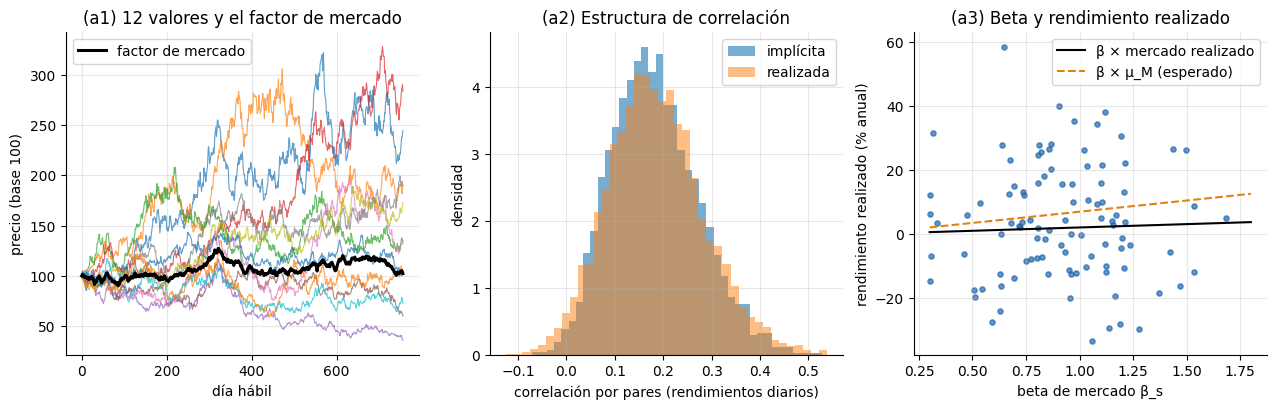

,corr_implied_mean,corr_realized_mean,vol_implied_mean,vol_realized_mean,market_mean_realized,market_vol_realized
valor,0.1828,0.1857,0.3452,0.3481,0.0208,0.1639


In [48]:
MARKET = sim.build_market()
MSUM = sp.correlation_summary(MARKET)
cov = sp.implied_covariance(MARKET)
vol = np.sqrt(np.diag(cov))
off = ~np.eye(len(vol), dtype=bool)
fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.2))
days = np.arange(MARKET.prices.shape[0])
for s in np.random.default_rng(0).choice(MARKET_CFG.n_securities, 12, replace=False):
    ax[0].plot(days, 100 * MARKET.prices[:, s] / MARKET.prices[0, s], lw=0.8, alpha=0.7)
ax[0].plot(days, 100 * np.concatenate([[1.0], np.cumprod(1 + MARKET.market_returns)]),
           color="k", lw=2.2, label="factor de mercado")
ax[0].set(xlabel="día hábil", ylabel="precio (base 100)", title="(a1) 12 valores y el factor de mercado")
ax[0].legend()
ax[1].hist((cov / np.outer(vol, vol))[off], bins=40, alpha=0.6, density=True, label="implícita")
ax[1].hist(np.corrcoef(MARKET.returns.T)[off], bins=40, alpha=0.5, density=True, label="realizada")
ax[1].set(xlabel="correlación por pares (rendimientos diarios)", ylabel="densidad",
          title="(a2) Estructura de correlación")
ax[1].legend()
grid_b = np.linspace(0.3, 1.8, 10)
ax[2].scatter(MARKET.betas, MARKET.returns.mean(0) * 25200, s=14, color=COLORS["accent"], alpha=0.7)
ax[2].plot(grid_b, grid_b * MSUM["market_mean_realized"] * 100, color="k", label="β × mercado realizado")
ax[2].plot(grid_b, grid_b * MARKET_CFG.mu_market * 100, color=COLORS["alt"], ls="--",
           label="β × μ_M (esperado)")
ax[2].set(xlabel="beta de mercado β_s", ylabel="rendimiento realizado (% anual)",
          title="(a3) Beta y rendimiento realizado")
ax[2].legend()
savefig(fig, "fig_a_precios_factores.png")
NUM.update(corr_implied=f"{MSUM['corr_implied_mean']:.2f}", corr_realized=f"{MSUM['corr_realized_mean']:.2f}",
           vol_implied=f"{100 * MSUM['vol_implied_mean']:.1f} %",
           mkt_realized=f"{100 * MSUM['market_mean_realized']:.1f}",
           mkt_vol=f"{100 * MSUM['market_vol_realized']:.1f}")
pd.Series(MSUM, name="valor").to_frame().T

**Figura (a).** Izquierda: 12 valores al azar y el factor de mercado, base 100. Centro: distribución de las correlaciones por pares implícitas en el modelo y realizadas en la muestra. Derecha: rendimiento anual realizado de cada valor contra su beta. La dispersión alrededor de la recta es riesgo idiosincrático puro, sin alfa, y la pendiente la fija el único mercado realizado de la muestra.

In [49]:
t_block = time.perf_counter()
MAIN = sim.run_grid(MARKET)
print(f"Ocho escenarios con estimadores y bootstrap ({N_BOOT} réplicas): "
      f"{time.perf_counter() - t_block:.1f} s")
trade_values = MAIN["S1"]["trade_values"]
NUM.update(median_trade=f"{np.median(trade_values):,.0f}",
           median_trade_bps=f"{1e4 * COSTS.commission_usd / np.median(trade_values):.0f}",
           mean_trade=f"{trade_values.mean():,.0f}",
           mean_trade_bps=f"{1e4 * COSTS.commission_usd / trade_values.mean():.0f}")

    S1  Nulo                               flujo    1     3.8 s


    S2  Disposición baja                   flujo    2     3.8 s


    S3  Disposición alta                   flujo    3     3.6 s


    S4  Rotación baja                      flujo    4     4.6 s


    S5  Rotación alta                      flujo    5     5.5 s


    S6  Ambos activos                      flujo    6     5.1 s


    S7  Confusor: rebalanceo               flujo    7     5.6 s


    S8  Confusor: reversión                flujo    8     4.4 s
Ocho escenarios con estimadores y bootstrap (1000 réplicas): 36.5 s


## 6. Validación de la restricción principal
**[SIM]** La restricción ("los rendimientos futuros son independientes de la decisión de operar") se verifica dos veces.

1. **Estructural.** Si en el día $t$ el motor leyera algún precio posterior a $t$, cambiar el futuro cambiaría decisiones pasadas. Se corren los tres tipos de regla (disposición E3, rebalanceo E7 y reversión E8) sobre la trayectoria original y sobre otra idéntica hasta $t^*=378$ con un futuro distinto, con la misma población y los mismos números aleatorios. Todo lo anterior a $t^*$ debe coincidir bit a bit, y lo posterior debe diferir, porque si no la prueba no tendría poder.
2. **Estadística (prueba de fuga).** Con todas las compras de las 8 poblaciones juntas, se estima la regresión del rendimiento realizado a 20 y 120 días del valor comprado sobre un indicador de compra con efectos fijos de día; el grupo de control es el universo del mismo día. Hay miles de compras pero sólo 100 valores y una trayectoria, así que el SE es Newey–West sobre las sumas diarias con tantos rezagos como días tiene la ventana. Se agrega la comparación de Odean (1999): rendimiento a 252 días de lo comprado menos lo vendido.

In [50]:
T_STAR = 378
other = sp.simulate_market(MARKET_CFG, np.random.default_rng(sa.child_seed(MASTER, 31)))
alt_prices = MARKET.prices.copy()
alt_prices[T_STAR + 1:] = np.maximum(np.round(
    MARKET.prices[T_STAR] * other.prices[T_STAR + 1:] / other.prices[T_STAR], 2), 0.01)
ALT = dataclasses.replace(MARKET, prices=alt_prices, returns=alt_prices[1:] / alt_prices[:-1] - 1.0)


def records_until(sim: sa.SimulationResult, table: str, last_day: int) -> dict:
    """Columns of a record table restricted to days <= last_day."""
    tab = sim.tables[table]
    keep = tab["day"] <= last_day
    return {c: v[keep] for c, v in tab.items()}


rows = []
for key, stream in (("S3", 3), ("S7", 7), ("S8", 8)):
    seed = sa.child_seed(MASTER, stream)
    pop = sa.draw_population(SCN[key], BEH, seed)
    a, b = (sa.simulate_trading(m, pop, SCN[key], BEH, COSTS, seed) for m in (MARKET, ALT))
    equal = all(np.array_equal(records_until(a, t, T_STAR)[c], records_until(b, t, T_STAR)[c])
                for t in ("sales", "buys", "snapshots") for c in a.tables[t])
    equal &= np.array_equal(a.gross[:T_STAR], b.gross[:T_STAR])
    after = [np.column_stack([s.tables["sales"][c][s.tables["sales"]["day"] > T_STAR]
                              for c in ("account", "day", "security")]) for s in (a, b)]
    shared = len({tuple(r) for r in after[0]} & {tuple(r) for r in after[1]})
    rows.append({"escenario": key, "ventas hasta t*": int((a.tables["sales"]["day"] <= T_STAR).sum()),
                 "todo idéntico hasta t*": equal,
                 "ventas después de t* (original / alterno)": f"{len(after[0])} / {len(after[1])}",
                 "ventas coincidentes después de t*": shared})
INVARIANCE = pd.DataFrame(rows)
after_s3 = INVARIANCE.loc[0, "ventas después de t* (original / alterno)"].split(" / ")[0]
NUM.update(inv_after_S3=f"{int(after_s3):,}", inv_shared_S3=f"{INVARIANCE.loc[0, 'ventas coincidentes después de t*']:,}")
INVARIANCE

,escenario,ventas hasta t*,todo idéntico hasta t*,ventas después de t* (original / alterno),ventas coincidentes después de t*
0,S3,18260,True,14364 / 19697,8012
1,S7,48130,True,47471 / 48954,25083
2,S8,34604,True,29199 / 37451,11509


In [51]:
events = [MAIN[k]["buys"] for k in MAIN]
LEAK = pd.DataFrame([se.leakage_test(events, MARKET, h, adj) for h in (20, 120) for adj in (False, True)])
LEAK["ajuste"] = np.where(LEAK["adjusted"], "β × mercado", "crudo")
pooled_buys = tuple(np.concatenate([MAIN[k]["buys"][j] for k in MAIN]) for j in (0, 1))
pooled_sales = tuple(np.concatenate([MAIN[k]["sales"][j] for k in MAIN]) for j in (0, 1))
BMS = pd.DataFrame([{"escenario": k, **se.bought_minus_sold(MAIN[k]["buys"], MAIN[k]["sales"], MARKET, 252, adj)}
                    for k in list(MAIN) for adj in (False, True)]
                   + [{"escenario": "todos", **se.bought_minus_sold(pooled_buys, pooled_sales, MARKET, 252, adj)}
                      for adj in (False, True)])
LEAK.to_csv(ROOT / "resultados" / "prueba_fuga.csv", index=False)
BMS.to_csv(ROOT / "resultados" / "comprado_menos_vendido.csv", index=False)
NUM.update(leak20_p=f"{LEAK.loc[0, 'p']:.2f}", leak120_p=f"{LEAK.loc[2, 'p']:.2f}",
           leak20_coef=f"{LEAK.loc[0, 'coef_pp']:+.3f}", leak120_coef=f"{LEAK.loc[2, 'coef_pp']:+.3f}",
           leak20_se=f"{LEAK.loc[0, 'se_pp']:.3f}", leak120_se=f"{LEAK.loc[2, 'se_pp']:.3f}",
           leak_nbuys=f"{LEAK.loc[0, 'n_buys']:,}",
           bms_all=f"{BMS.iloc[-2]['diff_pp']:+.2f}", bms_all_se=f"{BMS.iloc[-2]['se_pp']:.2f}",
           bms_all_adj=f"{BMS.iloc[-1]['diff_pp']:+.2f}", bms_all_adj_se=f"{BMS.iloc[-1]['se_pp']:.2f}",
           bms_n_sig=str(int((BMS["p"] < 0.05).sum())), bms_n=str(len(BMS)),
           bms_sig_list=", ".join(sorted({k.replace("S", "E") for k in BMS.loc[BMS["p"] < 0.05, "escenario"]})))
for key in ("S7", "S8"):
    row = BMS[(BMS["escenario"] == key) & ~BMS["adjusted"]].iloc[0]
    NUM.update({f"bms_{key}": f"{row['diff_pp']:+.2f}", f"bms_{key}_se": f"{row['se_pp']:.2f}",
                f"bms_{key}_t": f"{row['t']:.1f}"})
NUM["leak_mde"] = f"{2.8 * LEAK.loc[2, 'se_pp']:.2f}"  # 80 % power at 5 %: 2.8 standard errors
display(LEAK[["horizon", "ajuste", "coef_pp", "se_pp", "t", "p", "n_buys", "n_days"]]
        .rename(columns={"horizon": "ventana (días)", "coef_pp": "coef. (pp)", "se_pp": "EE NW (pp)",
                         "n_buys": "N compras", "n_days": "N días"}))
BMS.pivot(index="escenario", columns="adjusted", values=["diff_pp", "se_pp"]).round(2)

,ventana (días),ajuste,coef. (pp),EE NW (pp),t,p,N compras,N días
0,20,crudo,-0.0060,0.0197,-0.3074,0.7585,555515,736
1,20,β × mercado,-0.0025,0.0186,-0.1362,0.8916,555515,736
2,120,crudo,0.0347,0.0591,0.5862,0.5578,484493,636
3,120,β × mercado,0.0269,0.0620,0.4333,0.6648,484493,636


diff_pp          se_pp       
adjusted    False   True   False  True 
escenario                              
S1        -0.3200 -0.3100 0.2800 0.2700
S2        -0.1400 -0.1200 0.2300 0.2500
S3         0.4100  0.3800 0.6600 0.6100
S4        -0.4200 -0.4100 0.2200 0.2100
S5         0.0200  0.0300 0.1100 0.1000
S6         0.5200  0.4500 0.4900 0.4800
S7         2.1800  1.8600 0.9000 0.9100
S8         0.5300  0.5000 0.3400 0.3200
todos      0.4600  0.3900 0.3300 0.3200

**[SIM] — Interpretación**

* **Estructural.** En los tres tipos de regla, todas las ventas, compras, fotografías y rendimientos hasta $t^*$ coinciden bit a bit entre el mercado original y el alterno. Después de $t^*$ divergen: en E3 sólo 8,012 de 14,364 ventas coinciden. La prueba tiene poder: los agentes sí reaccionan a los precios, pero sólo a los que ya se revelaron.
* **Estadística.** Con 555,515 compras agrupadas de los ocho escenarios, el coeficiente del indicador de compra es -0.006 pp a 20 días (EE 0.020, p = 0.76) y +0.035 pp a 120 días (EE 0.059, p = 0.56). Es nulo crudo y ajustado por β.
* **Odean (1999).** Tampoco aparece su resultado: lo comprado menos lo vendido a 252 días da +0.46 pp (EE 0.33), frente a −3.2 pp en sus datos. De 18 comparaciones (crudas y ajustadas), 2 son significativas al 5 %, todas en E7; la cruda de E7 da +2.18 pp (t = 2.4). Es el rebalanceador, que compra perdedoras recientes y vende ganadoras recientes. Como la prueba estructural descarta fuga, se lee como un rasgo de esta trayectoria (reversión transversal realizada, §7.5) y no como información.
* **Poder.** El EE a 120 días es 0.059 pp: con 80 % de potencia la prueba detecta fugas de 0.17 pp por ventana. Como advierte Merton (1980) en el `.tex` de media-varianza, la precisión la fijan el lapso calendario y los 100 valores, no el número de compras.

## 7. Resultados
### 7.1 Convenciones de la contabilidad de Odean
**[ECON]** Se declaran antes de mostrar resultados y todas están implementadas en `simlib_estimadores.disposition_counts`.

* **Días sin venta:** una cuenta que no vendió nada ese día no aporta a ningún conteo.
* **Estado previo:** se clasifica cada posición abierta *antes* de las operaciones del día, al precio medio del día. Las posiciones compradas ese mismo día no entran.
* **Ventas parciales (base):** vender cualquier parte de una posición cuenta como **una** realización. *Alternativa:* la observación se reparte en la fracción vendida (realizada) y la conservada (papel). Se escoge la convención de Odean porque es la que puede replicarse con registros de operaciones sin conocer la intención de quien vende; la alternativa se reporta en §7.3, y en E7 resulta decisiva.
* **Base de costo (base):** **costo promedio** de los lotes abiertos, que es el que muestra un estado de cuenta y además el punto de referencia del agente. *Alternativas:* FIFO (el lote más antiguo, que es el que se libera primero), último lote comprado, y lote por lote (cada lote es una observación contra su propio precio).
* **Empates:** si $\lvert mid - c\rvert <$ \$0.005 (medio centavo), la posición se **excluye** de los cuatro conteos. La regla afectó 0.07–0.11 % de las observaciones según el escenario (tabla 7.3).

In [52]:
def stats_of(res: dict) -> dict:
    """The numbers a pre-registered rule may refer to."""
    b = res["conventions"]["avg_count"]
    og, on, ig = (slope_row(res, m, o) for m, o in (("OLS", "gross"), ("OLS", "net"), ("IV", "gross")))
    return {"diff": b["diff"], "lo": b["diff_lo"], "hi": b["diff_hi"], "ratio": b["ratio"],
            "bg": og.slope, "bg_lo": og.ci_lo, "bg_hi": og.ci_hi, "bn": on.slope, "bn_lo": on.ci_lo,
            "bn_hi": on.ci_hi, "bn_se": on.se_boot, "ig_lo": ig.ci_lo, "ig_hi": ig.ci_hi,
            "frac": res["conventions"]["avg_fraction"]["diff"]}


STAT = {k: stats_of(v) for k, v in MAIN.items()}
CHECKS = {
    "diff_ci_contains_0": lambda s: s["lo"] <= 0 <= s["hi"],
    "diff_positive_sig": lambda s: s["lo"] > 0,
    "diff_in": lambda s, a, b: a <= s["diff"] <= b,
    "ratio_in": lambda s, a, b: a <= s["ratio"] <= b,
    "b_gross_ci_contains_0": lambda s: s["bg_lo"] <= 0 <= s["bg_hi"],
    "iv_gross_ci_contains_0": lambda s: s["ig_lo"] <= 0 <= s["ig_hi"],
    "b_gross_positive": lambda s: s["bg"] > 0,
    "b_gross_positive_sig": lambda s: s["bg_lo"] > 0,
    "b_net_not_negative_sig": lambda s: s["bn_hi"] >= 0,
    "b_net_negative_sig": lambda s: s["bn_hi"] < 0,
    "b_net_minus_gross_in": lambda s, a, b: a <= s["bn"] - s["bg"] <= b,
    "b_net_within_2se_of": lambda s, k: abs(s["bn"] - STAT[k]["bn"]) <= 2 * np.hypot(s["bn_se"], STAT[k]["bn_se"]),
    "diff_greater_than": lambda s, k: s["diff"] > STAT[k]["diff"],
    "diff_less_than": lambda s, k: s["diff"] < STAT[k]["diff"],
    "ratio_at_least": lambda s, k: s["ratio"] >= STAT[k]["ratio"],
    "b_gross_less_than": lambda s, k: s["bg"] < STAT[k]["bg"],
    "fractional_diff_reduction_at_least": lambda s, r: 1 - s["frac"] / s["diff"] >= r,
}
EVAL = pd.DataFrame([{"Esc.": k, "predicción": " ".join(map(str, rule)),
                      "acierto": bool(CHECKS[rule[0]](STAT[k], *rule[1:]))}
                     for k, rules in RULES.items() if k != "description" for rule in rules])
EVAL.to_csv(ROOT / "resultados" / "preanalisis_evaluacion.csv", index=False)
HITS = EVAL.groupby("Esc.")["acierto"].agg(["sum", "count"])
MISSES = EVAL[~EVAL["acierto"]].groupby("Esc.")["predicción"].agg("; ".join)
print(f"Predicciones registradas acertadas: {EVAL['acierto'].sum()} de {len(EVAL)}")
EVAL[~EVAL["acierto"]]

Predicciones registradas acertadas: 33 de 38


,Esc.,predicción,acierto
1,S1,b_gross_ci_contains_0,False
15,S4,diff_ci_contains_0,False
25,S6,diff_less_than S3,False
26,S6,ratio_at_least S3,False
31,S7,ratio_in 2.0 5.0,False


### 7.2 Tabla maestra de los ocho escenarios
**[ECON]** Diferencias y razones con SE por **bootstrap de cuentas** (1,000 réplicas, IC percentil 95 %). Pendientes en **puntos porcentuales de rendimiento anual por unidad de rotación anual** (1 = 100 % de la cartera al año), con SE bootstrap por cuenta y HC1. IV = 2SLS con la intensidad *ex ante* $h_{0,i}$ como instrumento de la rotación realizada. La columna *Pre-análisis* cuenta las predicciones codificadas que se cumplieron.

In [53]:
MASTER_TABLE = sim.results_table(MAIN)  # built by the main simulator
MASTER_TABLE["preanalisis"] = [f"{HITS.loc[k, 'sum']}/{HITS.loc[k, 'count']}" for k in MASTER_TABLE["Esc."]]
MASTER_TABLE.round(6).to_csv(ROOT / "resultados" / "tabla_maestra.csv", index=False)


def est(v: float, s: float, d: int = 3) -> str:
    """'estimate (SE)' string."""
    return f"{v:.{d}f} ({s:.{d}f})"


SHOW = pd.DataFrame({
    "δ": MASTER_TABLE["delta"], "κ": MASTER_TABLE["kappa"], "Confusor": MASTER_TABLE["confusor"],
    "PGR": MASTER_TABLE["PGR"].map("{:.4f}".format), "PLR": MASTER_TABLE["PLR"].map("{:.4f}".format),
    "PGR−PLR (EE)": [est(v, s, 4) for v, s in zip(MASTER_TABLE["dif"], MASTER_TABLE["dif_ee"])],
    "IC 95 %": [f"[{a:.4f}, {b:.4f}]" for a, b in zip(MASTER_TABLE["dif_ic_inf"], MASTER_TABLE["dif_ic_sup"])],
    "PGR/PLR (EE)": [est(v, s, 2) for v, s in zip(MASTER_TABLE["razon"], MASTER_TABLE["razon_ee"])],
    "β bruta (EE boot / HC1)": [f"{v:+.2f} ({s:.2f} / {h:.2f})" for v, s, h in zip(
        MASTER_TABLE["b_bruta"], MASTER_TABLE["b_bruta_ee_boot"], MASTER_TABLE["b_bruta_ee_hc1"])],
    "β neta (EE boot / HC1)": [f"{v:+.2f} ({s:.2f} / {h:.2f})" for v, s, h in zip(
        MASTER_TABLE["b_neta"], MASTER_TABLE["b_neta_ee_boot"], MASTER_TABLE["b_neta_ee_hc1"])],
    "β IV bruta (EE)": [est(v, s, 2) for v, s in zip(MASTER_TABLE["b_iv_bruta"], MASTER_TABLE["b_iv_bruta_ee"])],
    "β IV neta (EE)": [est(v, s, 2) for v, s in zip(MASTER_TABLE["b_iv_neta"], MASTER_TABLE["b_iv_neta_ee"])],
    "Rotación media": MASTER_TABLE["rotacion_media"].map("{:.2f}".format),
    "N cuentas": MASTER_TABLE["n_cuentas"], "N obs.": MASTER_TABLE["n_obs_odean"].map("{:,}".format),
    "Pre-análisis": MASTER_TABLE["preanalisis"]}).set_axis(MASTER_TABLE["Esc."])
SHOW

,δ,κ,Confusor,PGR,PLR,PGR−PLR (EE),IC 95 %,PGR/PLR (EE),β bruta (EE boot / HC1),β neta (EE boot / HC1),β IV bruta (EE),β IV neta (EE),Rotación media,N cuentas,N obs.,Pre-análisis
Esc.,,,,,,,,,,,,,,,,
S1,0.0000,0.0000,—,0.0506,0.0498,0.0007 (0.0005),"[-0.0002, 0.0017]",1.01 (0.01),+1.39 (0.61 / 0.61),+0.17 (0.63 / 0.62),0.83 (0.63),-0.50 (0.65),0.67,1000,"793,855",2/3
S2,0.3000,0.0000,—,0.0641,0.0365,0.0276 (0.0006),"[0.0265, 0.0289]",1.76 (0.02),+1.71 (0.55 / 0.58),+0.68 (0.56 / 0.59),0.29 (0.65),-0.92 (0.66),0.67,1000,"780,830",5/5
S3,0.8000,0.0000,—,0.0973,0.0127,0.0846 (0.0010),"[0.0827, 0.0868]",7.66 (0.12),+5.26 (0.58 / 0.61),+4.30 (0.59 / 0.61),1.05 (0.70),-0.10 (0.70),0.63,1000,"656,085",7/7
S4,0.0000,0.3000,—,0.0515,0.0522,-0.0008 (0.0004),"[-0.0015, -0.0000]",0.98 (0.01),+0.33 (0.34 / 0.34),-0.84 (0.35 / 0.35),0.21 (0.35),-1.07 (0.37),1.24,1000,"1,444,318",3/4
S5,0.0000,0.8000,—,0.0552,0.0552,0.0000 (0.0003),"[-0.0006, 0.0006]",1.00 (0.01),+0.09 (0.19 / 0.20),-1.06 (0.22 / 0.22),0.06 (0.19),-1.17 (0.22),2.19,1000,"2,353,100",5/5
S6,0.8000,0.8000,—,0.1157,0.0157,0.1000 (0.0010),"[0.0981, 0.1022]",7.38 (0.06),+1.74 (0.28 / 0.28),+0.69 (0.30 / 0.29),0.03 (0.32),-1.13 (0.34),1.76,1000,"1,837,305",4/6
S7,0.0000,0.0000,rebalanceo,0.0663,0.0349,0.0314 (0.0005),"[0.0306, 0.0324]",1.90 (0.01),+0.69 (0.46 / 0.48),-0.47 (0.48 / 0.49),0.55 (0.50),-0.76 (0.52),0.97,1000,"1,846,218",3/4
S8,0.0000,0.0000,reversión,0.0647,0.0412,0.0236 (0.0005),"[0.0226, 0.0245]",1.57 (0.01),+0.76 (0.38 / 0.37),-0.22 (0.39 / 0.38),-0.29 (0.39),-1.35 (0.40),1.14,1000,"1,222,056",4/4


### 7.3 Robustez a las convenciones
**[ECON]** $\widehat{PGR}-\widehat{PLR}$ (SE bootstrap por cuenta) según la base de costo y la regla de ventas parciales, y la frecuencia de empates excluidos.

In [54]:
LABELS = {"avg_count": "costo promedio (base)", "fifo_count": "FIFO (lote más antiguo)",
          "last_count": "último lote", "lot_count": "lote por lote", "avg_fraction": "promedio, fracción vendida"}
ROBUST = pd.DataFrame({lab: [est(MAIN[k]["conventions"][c]["diff"], MAIN[k]["conventions"][c]["diff_se"], 4)
                             for k in MAIN] for c, lab in LABELS.items()}, index=list(MAIN))
ROBUST["cambio fracción vs. base"] = [f"{100 * (MAIN[k]['conventions']['avg_fraction']['diff'] / MAIN[k]['conventions']['avg_count']['diff'] - 1):+.0f} %"
                                      if STAT[k]["lo"] > 0 else "n.a. (nulo)" for k in MAIN]
TIES = pd.DataFrame({"empates excluidos": [MAIN[k]["conventions"]["avg_count"]["ties"] for k in MAIN],
                     "observaciones": [MAIN[k]["conventions"]["avg_count"]["observations"] for k in MAIN]},
                    index=list(MAIN))
TIES["% de observaciones"] = 100 * TIES["empates excluidos"] / TIES["observaciones"]
ROBUST.to_csv(ROOT / "resultados" / "robustez_convenciones.csv")
chg = {k: {c: 100 * (MAIN[k]["conventions"][c]["diff"] / MAIN[k]["conventions"]["avg_count"]["diff"] - 1)
           for c in LABELS if c != "avg_count"} for k in MAIN if STAT[k]["lo"] > 0}
others = [abs(v) for k, d in chg.items() if k != "S7" for v in d.values()]
NUM.update(conv_min=f"{min(others):.0f}", conv_max=f"{max(others):.0f}",
           **{f"frac_chg_{k}": f"{chg[k]['avg_fraction']:+.0f}" for k in chg},
           **{f"lot_chg_{k}": f"{chg[k]['lot_count']:+.0f}" for k in chg})
NUM.update(tie_min=f"{TIES['% de observaciones'].min():.2f}", tie_max=f"{TIES['% de observaciones'].max():.2f}")
display(ROBUST)
TIES

,costo promedio (base),FIFO (lote más antiguo),último lote,lote por lote,"promedio, fracción vendida",cambio fracción vs. base
S1,0.0007 (0.0005),0.0008 (0.0005),0.0008 (0.0005),0.0007 (0.0005),0.0004 (0.0005),n.a. (nulo)
S2,0.0276 (0.0006),0.0269 (0.0006),0.0263 (0.0006),0.0249 (0.0006),0.0242 (0.0005),-12 %
S3,0.0846 (0.0010),0.0829 (0.0010),0.0798 (0.0010),0.0774 (0.0010),0.0742 (0.0009),-12 %
S4,-0.0008 (0.0004),-0.0007 (0.0004),-0.0006 (0.0004),-0.0008 (0.0004),-0.0008 (0.0003),n.a. (nulo)
S5,0.0000 (0.0003),-0.0000 (0.0003),0.0000 (0.0003),-0.0002 (0.0003),-0.0000 (0.0003),n.a. (nulo)
S6,0.1000 (0.0010),0.0967 (0.0010),0.0898 (0.0009),0.0853 (0.0009),0.0875 (0.0009),-13 %
S7,0.0314 (0.0005),0.0268 (0.0004),0.0346 (0.0005),0.0148 (0.0003),0.0067 (0.0002),-79 %
S8,0.0236 (0.0005),0.0230 (0.0005),0.0238 (0.0005),0.0219 (0.0005),0.0206 (0.0004),-13 %


,empates excluidos,observaciones,% de observaciones
S1,597,793855,0.0752
S2,519,780830,0.0665
S3,436,656085,0.0665
S4,1300,1444318,0.0900
S5,2509,2353100,0.1066
S6,1734,1837305,0.0944
S7,1334,1846218,0.0723
S8,952,1222056,0.0779


### 7.4 Inferencia: bootstrap por cuenta contra bootstrap ingenuo por observación
**[ECON]** Cada réplica remuestrea las 1,000 cuentas con reemplazo y re-agrega los cuatro conteos. La versión ingenua remuestrea las observaciones (cuenta, día, posición) como si fueran i.i.d., lo que equivale a una multinomial sobre los cuatro tipos.

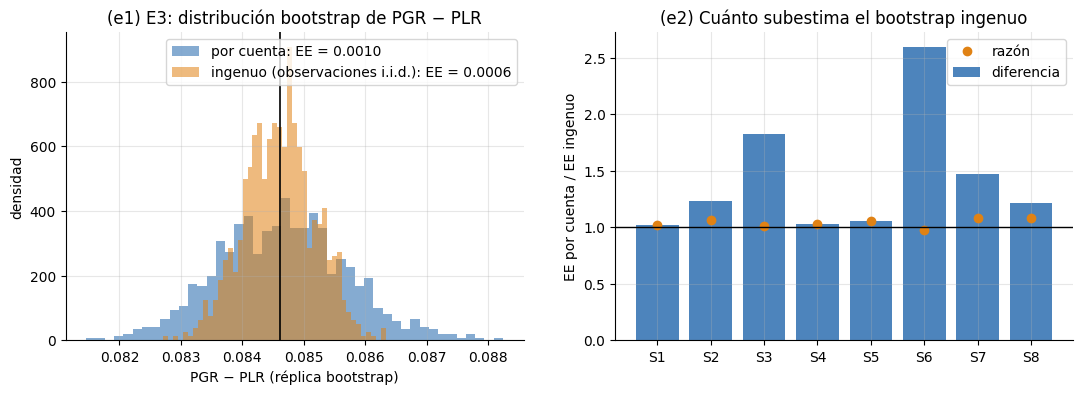

,EE cuenta (dif.),EE ingenuo (dif.),EE cuenta (razón),EE ingenuo (razón),N cuentas,N obs.,cociente EE (dif.),cociente EE (razón)
S1,0.0005,0.0005,0.0103,0.0101,1000,793855,1.0226,1.0216
S2,0.0006,0.0005,0.0186,0.0175,1000,780830,1.2316,1.0625
S3,0.0010,0.0006,0.1178,0.1170,1000,656085,1.8298,1.0071
S4,0.0004,0.0004,0.0072,0.0070,1000,1444318,1.0328,1.0293
S5,0.0003,0.0003,0.0057,0.0054,1000,2353100,1.0595,1.0583
S6,0.0010,0.0004,0.0575,0.0588,1000,1837305,2.5971,0.9771
S7,0.0005,0.0003,0.0140,0.0129,1000,1846218,1.4756,1.0828
S8,0.0005,0.0004,0.0131,0.0121,1000,1222056,1.2183,1.0835


In [55]:
BOOT = pd.DataFrame({
    "EE cuenta (dif.)": [MAIN[k]["conventions"]["avg_count"]["diff_se"] for k in MAIN],
    "EE ingenuo (dif.)": [MAIN[k]["naive"]["diff_se"] for k in MAIN],
    "EE cuenta (razón)": [MAIN[k]["conventions"]["avg_count"]["ratio_se"] for k in MAIN],
    "EE ingenuo (razón)": [MAIN[k]["naive"]["ratio_se"] for k in MAIN],
    "N cuentas": [len(MAIN[k]["panel"]) for k in MAIN],
    "N obs.": [MAIN[k]["conventions"]["avg_count"]["observations"] for k in MAIN]}, index=list(MAIN))
BOOT["cociente EE (dif.)"] = BOOT["EE cuenta (dif.)"] / BOOT["EE ingenuo (dif.)"]
BOOT["cociente EE (razón)"] = BOOT["EE cuenta (razón)"] / BOOT["EE ingenuo (razón)"]
BOOT.to_csv(ROOT / "resultados" / "bootstrap_cuenta_vs_ingenuo.csv")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for draws, lab, col in ((MAIN["S3"]["draws"]["avg_count"]["diff"], "por cuenta", COLORS["accent"]),
                        (MAIN["S3"]["naive_draws"]["diff"], "ingenuo (observaciones i.i.d.)", COLORS["alt"])):
    ax[0].hist(draws, bins=45, density=True, alpha=0.55, color=col, label=f"{lab}: EE = {draws.std(ddof=1):.4f}")
ax[0].axvline(STAT["S3"]["diff"], color="k", lw=1.2)
ax[0].set(xlabel="PGR − PLR (réplica bootstrap)", ylabel="densidad",
          title="(e1) E3: distribución bootstrap de PGR − PLR")
ax[0].legend()
ax[1].bar(BOOT.index, BOOT["cociente EE (dif.)"], color=COLORS["accent"], alpha=0.8, label="diferencia")
ax[1].plot(BOOT.index, BOOT["cociente EE (razón)"], "o", color=COLORS["alt"], label="razón")
ax[1].axhline(1, color="k", lw=1)
ax[1].set(ylabel="EE por cuenta / EE ingenuo", title="(e2) Cuánto subestima el bootstrap ingenuo")
ax[1].legend()
savefig(fig, "fig_e_bootstrap.png")
NUM.update(**{f"bootratio_{k}": f"{BOOT.loc[k, 'cociente EE (dif.)']:.2f}" for k in MAIN})
BOOT.round(5)

**Figura (e).** Izquierda: en E3 el bootstrap ingenuo produce una distribución de PGR − PLR 1.83 veces más estrecha. Derecha: cociente de SE por escenario; la línea en 1 marca igualdad.

**[ECON]** Como se registró, el cociente para la diferencia es ≈ 1 en el nulo (1.02) y crece con $\delta$ (hasta 2.60 en E6). El bootstrap ingenuo sólo subestima cuando hay heterogeneidad persistente entre cuentas en la propensión a realizar. Una sorpresa: para la **razón** el cociente es ≈ 1 en todos los escenarios. La varianza de la razón la domina el error relativo de PLR, un conteo pequeño cuyo ruido es casi binomial, y no la dependencia dentro de la cuenta.

### 7.5 Validación del simulador
**[ECON]** Cuatro pruebas: nulo quieto, monotonía, silencio cruzado y curva de recuperación. Para responder la objeción de [REF] sobre los SE de $\beta$ se agrega un **Monte Carlo sobre trayectorias de precios**: 20 mundos independientes, cada uno con mercado y población nuevos, para E1, E3 y E5.

In [56]:
R_MC, MC_KEYS = 20, ("S1", "S3", "S5")
mc_rows, t_block = [], time.perf_counter()
for r in range(R_MC):
    world = sp.simulate_market(MARKET_CFG, np.random.default_rng(sa.child_seed(MASTER, 600 + r)))
    reversal = sp.realized_reversal(world)
    for k in MC_KEYS:
        res = run(SCN[k], 500 + r, world, n_boot=200, quiet=True)
        s, og = stats_of(res), slope_row(res, "OLS", "gross")
        mc_rows.append({"Esc.": k, "mundo": r, "mercado": 100 * world.market_returns.mean() * 252,
                        "reversión": reversal,
                        "dif": s["diff"], "dif_ee": res["conventions"]["avg_count"]["diff_se"],
                        "b_bruta": og.slope, "b_bruta_ee": og.se_boot, "b_neta": s["bn"],
                        "b_costos": slope_row(res, "OLS", "costs").slope})
MC = pd.DataFrame(mc_rows)
MC.to_csv(ROOT / "resultados" / "monte_carlo_trayectorias.csv", index=False)
print(f"Monte Carlo: {R_MC} mundos × {len(MC_KEYS)} escenarios en {time.perf_counter() - t_block:.0f} s")
g = MC.groupby("Esc.")
MC_SUM = pd.DataFrame({
    "media dif": g["dif"].mean(), "DE dif entre mundos": g["dif"].std(), "EE boot medio (dif)": g["dif_ee"].mean(),
    "media β bruta": g["b_bruta"].mean(), "DE β bruta entre mundos": g["b_bruta"].std(),
    "EE boot medio (β)": g["b_bruta_ee"].mean(), "media β costos": g["b_costos"].mean(),
    "rechazos β=0 al 5 % (EE boot)": g.apply(lambda d: (np.abs(d["b_bruta"] / d["b_bruta_ee"]) > 1.96).mean(),
                                             include_groups=False),
    "corr(dif, mercado)": g.apply(lambda d: d["dif"].corr(d["mercado"]), include_groups=False),
    "corr(β bruta, reversión)": g.apply(lambda d: d["b_bruta"].corr(d["reversión"]), include_groups=False)})
REV_BASE, rev_worlds = sp.realized_reversal(MARKET), MC.drop_duplicates("mundo")["reversión"]
NUM.update(rev_base=f"{REV_BASE:+.3f}", rev_mc_mean=f"{rev_worlds.mean():+.3f}", rev_mc_sd=f"{rev_worlds.std():.3f}",
           rev_z=f"{(REV_BASE - rev_worlds.mean()) / rev_worlds.std():+.1f}",
           **{f"rev_corr_{k}": f"{MC_SUM.loc[k, 'corr(β bruta, reversión)']:+.2f}" for k in MC_KEYS})
MC_SUM["DE/EE (dif)"] = MC_SUM["DE dif entre mundos"] / MC_SUM["EE boot medio (dif)"]
MC_SUM["DE/EE (β)"] = MC_SUM["DE β bruta entre mundos"] / MC_SUM["EE boot medio (β)"]
honest_t = STAT["S1"]["bg"] / MC_SUM.loc["S1", "DE β bruta entre mundos"]
NUM.update(R_MC=str(R_MC), mc_ratio_b_S1=f"{MC_SUM.loc['S1', 'DE/EE (β)']:.2f}",
           mc_ratio_b_S3=f"{MC_SUM.loc['S3', 'DE/EE (β)']:.2f}", mc_ratio_b_S5=f"{MC_SUM.loc['S5', 'DE/EE (β)']:.2f}",
           mc_ratio_d_S1=f"{MC_SUM.loc['S1', 'DE/EE (dif)']:.2f}", mc_ratio_d_S3=f"{MC_SUM.loc['S3', 'DE/EE (dif)']:.2f}",
           mc_mean_b_S1=f"{MC_SUM.loc['S1', 'media β bruta']:+.2f}", mc_sd_b_S1=f"{MC_SUM.loc['S1', 'DE β bruta entre mundos']:.2f}",
           mc_reject_S1=f"{100 * MC_SUM.loc['S1', 'rechazos β=0 al 5 % (EE boot)']:.0f}",
           mc_reject_S5=f"{100 * MC_SUM.loc['S5', 'rechazos β=0 al 5 % (EE boot)']:.0f}",
           mc_corr_S3=f"{MC_SUM.loc['S3', 'corr(dif, mercado)']:.2f}", honest_t_S1=f"{honest_t:.2f}",
           mc_mean_d_S3=f"{MC_SUM.loc['S3', 'media dif']:.4f}", mc_sd_d_S3=f"{MC_SUM.loc['S3', 'DE dif entre mundos']:.4f}",
           mc_se_d_S3=f"{MC_SUM.loc['S3', 'EE boot medio (dif)']:.4f}",
           mc_min_d_S3=f"{MC[MC['Esc.'] == 'S3']['dif'].min():.4f}", mc_max_d_S3=f"{MC[MC['Esc.'] == 'S3']['dif'].max():.4f}",
           mc_mean_b_S3=f"{MC_SUM.loc['S3', 'media β bruta']:+.2f}", mc_sd_b_S3=f"{MC_SUM.loc['S3', 'DE β bruta entre mundos']:.2f}",
           mc_se_b_S3=f"{MC_SUM.loc['S3', 'EE boot medio (β)']:.2f}", mc_se_b_S1=f"{MC_SUM.loc['S1', 'EE boot medio (β)']:.2f}",
           mc_reject_S3=f"{100 * MC_SUM.loc['S3', 'rechazos β=0 al 5 % (EE boot)']:.0f}")
MC_SUM.T.round(4)

Monte Carlo: 20 mundos × 3 escenarios en 228 s


Esc.,S1,S3,S5
media dif,-0.0000,0.0862,-0.0001
DE dif entre mundos,0.0006,0.0194,0.0003
EE boot medio (dif),0.0005,0.0010,0.0003
media β bruta,0.0094,4.4754,0.0292
DE β bruta entre mundos,0.5908,1.6944,0.1903
EE boot medio (β),0.6034,0.6649,0.2029
media β costos,1.1004,0.9095,1.3237
rechazos β=0 al 5 % (EE boot),0.0000,1.0000,0.0000
"corr(dif, mercado)",-0.1918,-0.7999,-0.0610
"corr(β bruta, reversión)",-0.1873,0.2659,-0.2448


In [57]:
t_block = time.perf_counter()
DELTA_SWEEP = {d: run(sa.ScenarioConfig(f"δ={d:.1f}", "barrido de δ (κ = 0)", d, 0.0), 11 + j)
               for j, d in enumerate(np.round(np.arange(0.0, 1.01, 0.2), 1))}
KAPPA_SWEEP = {c: run(sa.ScenarioConfig(f"κ={c:.1f}", "barrido de κ (δ = 0)", 0.0, c), 21 + j, n_boot=300)
               for j, c in enumerate(np.round(np.arange(0.0, 1.01, 0.2), 1))}
print(f"Barridos: {time.perf_counter() - t_block:.1f} s")
SWEEP_D = pd.DataFrame({d: {"dif": r["conventions"]["avg_count"]["diff"], "lo": r["conventions"]["avg_count"]["diff_lo"],
                            "hi": r["conventions"]["avg_count"]["diff_hi"], "razon": r["conventions"]["avg_count"]["ratio"],
                            "razon_lo": r["conventions"]["avg_count"]["ratio_lo"],
                            "razon_hi": r["conventions"]["avg_count"]["ratio_hi"],
                            "PLR": r["conventions"]["avg_count"]["plr"],
                            "ganancias en papel": r["profile"]["share_paper_gains"]} for d, r in DELTA_SWEEP.items()}).T
SWEEP_K = pd.DataFrame({c: {"β neta": slope_row(r, "OLS", "net").slope, "EE β neta": slope_row(r, "OLS", "net").se_boot,
                            "β costos": slope_row(r, "OLS", "costs").slope, "β bruta": slope_row(r, "OLS", "gross").slope,
                            "rotación media": r["panel"]["turnover"].mean(), "costo medio (pp/año)": r["panel"]["costs"].mean(),
                            "dif": r["conventions"]["avg_count"]["diff"]} for c, r in KAPPA_SWEEP.items()}).T
SWEEP_D.to_csv(ROOT / "resultados" / "curva_recuperacion_delta.csv")
SWEEP_K.to_csv(ROOT / "resultados" / "barrido_kappa.csv")
steps = np.diff(SWEEP_D["dif"].astype(float))
NUM.update(sweepd_diffs=", ".join(f"{v:.4f}" for v in SWEEP_D["dif"]),
           sweepd_steps=", ".join(f"{v:.4f}" for v in steps),
           sweepd_ratios=", ".join(f"{v:.2f}" for v in SWEEP_D["razon"].iloc[:-1]),
           sweepd_gain_first=f"{100 * SWEEP_D['ganancias en papel'].iloc[0]:.1f}",
           sweepd_gain_last=f"{100 * SWEEP_D['ganancias en papel'].iloc[-1]:.1f}",
           sweepd_convex=str(bool((np.diff(steps) > 0).all())),
           sweepk_bn=", ".join(f"{abs(v):.2f}" for v in SWEEP_K["β neta"]),
           sweepk_bc_min=f"{SWEEP_K['β costos'].min():.2f}", sweepk_bc_max=f"{SWEEP_K['β costos'].max():.2f}",
           sweepk_turn_last=f"{SWEEP_K['rotación media'].iloc[-1]:.2f}",
           sweepk_cost_first=f"{SWEEP_K['costo medio (pp/año)'].iloc[0]:.2f}",
           sweepk_cost_last=f"{SWEEP_K['costo medio (pp/año)'].iloc[-1]:.2f}")
display(SWEEP_D.round(4))
SWEEP_K.round(3)

 δ=0.0  barrido de δ (κ = 0)               flujo   11     3.7 s


 δ=0.2  barrido de δ (κ = 0)               flujo   12     3.7 s


 δ=0.4  barrido de δ (κ = 0)               flujo   13     3.6 s


 δ=0.6  barrido de δ (κ = 0)               flujo   14     3.7 s


 δ=0.8  barrido de δ (κ = 0)               flujo   15     3.5 s


...

 κ=0.6  barrido de κ (δ = 0)               flujo   24     6.6 s


 κ=0.8  barrido de κ (δ = 0)               flujo   25     6.8 s


 κ=1.0  barrido de κ (δ = 0)               flujo   26     7.2 s
Barridos: 57.2 s


,dif,lo,hi,razon,razon_lo,razon_hi,PLR,ganancias en papel
0.0000,0.0005,-0.0004,0.0015,1.0104,0.9913,1.0295,0.0496,0.5050
0.2000,0.0192,0.0181,0.0203,1.4691,1.4395,1.5005,0.0408,0.4855
0.4000,0.0383,0.0370,0.0396,2.1814,2.1393,2.2317,0.0324,0.4696
0.6000,0.0598,0.0583,0.0615,3.5844,3.4991,3.6720,0.0231,0.4539
0.8000,0.0843,0.0823,0.0865,7.5419,7.3144,7.7649,0.0129,0.4413
1.0000,0.1150,0.1127,0.1175,inf,NaN,NaN,0.0000,0.4245


,β neta,EE β neta,β costos,β bruta,rotación media,costo medio (pp/año),dif
0.0000,-1.3210,0.5810,1.0040,-0.3160,0.6610,0.7390,-0.0000
0.2000,-0.4800,0.4810,1.1980,0.7170,1.0460,1.2820,-0.0000
0.4000,-0.4780,0.3250,1.1480,0.6700,1.4230,1.5940,-0.0000
0.6000,-0.7040,0.2410,1.1690,0.4650,1.8600,2.0800,-0.0000
0.8000,-1.1840,0.2430,1.2590,0.0740,2.2050,2.7230,-0.0000
1.0000,-1.1730,0.1830,1.0640,-0.1080,2.6380,3.1070,-0.0000


In [58]:
def ci_text(lo: float, hi: float, d: int = 2) -> str:
    """'[lo, hi]' string."""
    return f"[{lo:.{d}f}, {hi:.{d}f}]"


iv = {k: slope_row(MAIN[k], "IV", "gross") for k in MAIN}
bc = {k: slope_row(MAIN[k], "OLS", "costs").slope for k in MAIN}
quiet = lambda lo, hi: "✔ quieto" if lo <= 0 <= hi else "✘ no quieto"
gap_45, se_45 = abs(STAT["S5"]["bn"]) - abs(STAT["S4"]["bn"]), np.hypot(STAT["S4"]["bn_se"], STAT["S5"]["bn_se"])
mono_net = ("✔ crece" if gap_45 > 0 else "✘ no crece") + (", significativo" if abs(gap_45) > 1.96 * se_45
                                                         else ", no significativo")
cost_flat = "plano (< 0.1 pp)" if abs(bc["S5"] - bc["S4"]) < 0.1 else "cambia"
VALID = pd.DataFrame([
    ("Nulo — PGR−PLR (E1)", f"{STAT['S1']['diff']:+.4f}", ci_text(STAT["S1"]["lo"], STAT["S1"]["hi"], 4),
     quiet(STAT["S1"]["lo"], STAT["S1"]["hi"])),
    ("Nulo — β bruta MCO (E1), EE bootstrap", f"{STAT['S1']['bg']:+.2f}", ci_text(STAT["S1"]["bg_lo"], STAT["S1"]["bg_hi"]),
     quiet(STAT["S1"]["bg_lo"], STAT["S1"]["bg_hi"])),
    ("Nulo — β bruta MCO (E1), DE Monte Carlo", f"t = {honest_t:.2f}",
     ci_text(STAT["S1"]["bg"] - 1.96 * MC_SUM.loc["S1", "DE β bruta entre mundos"],
             STAT["S1"]["bg"] + 1.96 * MC_SUM.loc["S1", "DE β bruta entre mundos"]),
     "✔ quieto" if abs(honest_t) < 1.96 else "✘ no quieto"),
    ("Nulo — β bruta IV (E1)", f"{iv['S1'].slope:+.2f}", ci_text(iv["S1"].ci_lo, iv["S1"].ci_hi),
     quiet(iv["S1"].ci_lo, iv["S1"].ci_hi)),
    ("Monotonía — PGR−PLR: E2 → E3", f"{STAT['S2']['diff']:.4f} → {STAT['S3']['diff']:.4f}", "",
     "✔ crece" if STAT["S3"]["lo"] > STAT["S2"]["hi"] else "✘"),
    ("Monotonía — |β neta|: E4 → E5", f"{abs(STAT['S4']['bn']):.2f} → {abs(STAT['S5']['bn']):.2f}",
     f"dif. {gap_45:+.2f} (EE {se_45:.2f})", mono_net),
    ("   descomposición: β costos E4 → E5", f"{bc['S4']:.3f} → {bc['S5']:.3f}", "", cost_flat),
    ("   descomposición: β bruta E4 → E5", f"{STAT['S4']['bg']:+.2f} → {STAT['S5']['bg']:+.2f}", "",
     f"cambio {STAT['S5']['bg'] - STAT['S4']['bg']:+.2f}"),
    ("Silencio cruzado — β bruta MCO en E2 / E3", f"{STAT['S2']['bg']:+.2f} / {STAT['S3']['bg']:+.2f}",
     f"{ci_text(STAT['S2']['bg_lo'], STAT['S2']['bg_hi'])} / {ci_text(STAT['S3']['bg_lo'], STAT['S3']['bg_hi'])}",
     f"{quiet(STAT['S2']['bg_lo'], STAT['S2']['bg_hi'])} / {quiet(STAT['S3']['bg_lo'], STAT['S3']['bg_hi'])}"),
    ("Silencio cruzado — β bruta IV en E2 / E3", f"{iv['S2'].slope:+.2f} / {iv['S3'].slope:+.2f}",
     f"{ci_text(iv['S2'].ci_lo, iv['S2'].ci_hi)} / {ci_text(iv['S3'].ci_lo, iv['S3'].ci_hi)}",
     f"{quiet(iv['S2'].ci_lo, iv['S2'].ci_hi)} / {quiet(iv['S3'].ci_lo, iv['S3'].ci_hi)}"),
    ("Silencio cruzado — PGR−PLR en E4 / E5", f"{STAT['S4']['diff']:+.4f} / {STAT['S5']['diff']:+.4f}",
     f"{ci_text(STAT['S4']['lo'], STAT['S4']['hi'], 4)} / {ci_text(STAT['S5']['lo'], STAT['S5']['hi'], 4)}",
     f"{quiet(STAT['S4']['lo'], STAT['S4']['hi'])} / {quiet(STAT['S5']['lo'], STAT['S5']['hi'])}"),
], columns=["prueba", "estimación", "IC 95 %", "veredicto"])
VALID.to_csv(ROOT / "resultados" / "validacion.csv", index=False)
VALID.set_index("prueba")  # plain DataFrame: pandas' Styler would need jinja2

,estimación,IC 95 %,veredicto
prueba,,,
Nulo — PGR−PLR (E1),+0.0007,"[-0.0002, 0.0017]",✔ quieto
"Nulo — β bruta MCO (E1), EE bootstrap",+1.39,"[0.20, 2.64]",✘ no quieto
"Nulo — β bruta MCO (E1), DE Monte Carlo",t = 2.36,"[0.23, 2.55]",✘ no quieto
Nulo — β bruta IV (E1),+0.83,"[-0.40, 2.07]",✔ quieto
Monotonía — PGR−PLR: E2 → E3,0.0276 → 0.0846,,✔ crece
Monotonía — |β neta|: E4 → E5,0.84 → 1.06,dif. +0.23 (EE 0.42),"✔ crece, no significativo"
descomposición: β costos E4 → E5,1.165 → 1.158,,plano (< 0.1 pp)
descomposición: β bruta E4 → E5,+0.33 → +0.09,,cambio -0.24
Silencio cruzado — β bruta MCO en E2 / E3,+1.71 / +5.26,"[0.62, 2.73] / [4.03, 6.35]",✘ no quieto / ✘ no quieto


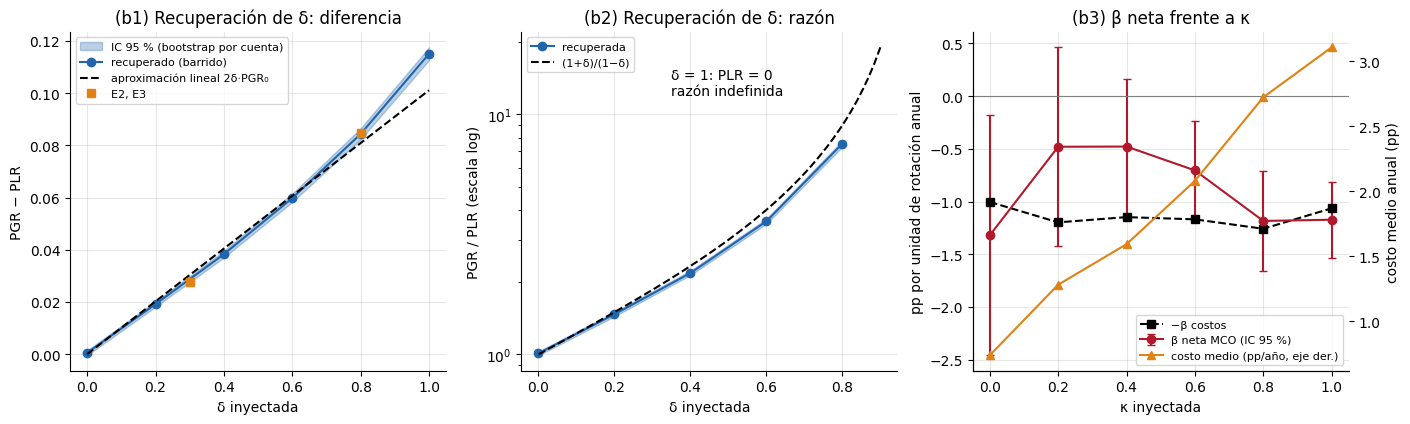

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.4))
d = SWEEP_D.index.to_numpy(float)
ax[0].fill_between(d, SWEEP_D["lo"].astype(float), SWEEP_D["hi"].astype(float), alpha=0.3,
                   color=COLORS["accent"], label="IC 95 % (bootstrap por cuenta)")
ax[0].plot(d, SWEEP_D["dif"], "o-", color=COLORS["accent"], label="recuperado (barrido)")
ax[0].plot(d, 2 * d * MAIN["S1"]["conventions"]["avg_count"]["pgr"], "--", color="k",
           label="aproximación lineal 2δ·PGR₀")
ax[0].plot([0.3, 0.8], [STAT["S2"]["diff"], STAT["S3"]["diff"]], "s", color=COLORS["alt"], label="E2, E3")
ax[0].set(xlabel="δ inyectada", ylabel="PGR − PLR", title="(b1) Recuperación de δ: diferencia")
ax[0].legend(fontsize=8)
finite = d < 1.0
ax[1].semilogy(d[finite], SWEEP_D["razon"][finite].astype(float), "o-", color=COLORS["accent"], label="recuperada")
ax[1].fill_between(d[finite], SWEEP_D["razon_lo"][finite].astype(float), SWEEP_D["razon_hi"][finite].astype(float),
                   alpha=0.3, color=COLORS["accent"])
grid_d = np.linspace(0, 0.9, 60)
ax[1].semilogy(grid_d, (1 + grid_d) / (1 - grid_d), "--", color="k", label="(1+δ)/(1−δ)")
ax[1].annotate(f"δ = 1: PLR = {SWEEP_D.loc[1.0, 'PLR']:.0f}\nrazón indefinida", xy=(0.8, 8), xytext=(0.35, 12))
ax[1].set(xlabel="δ inyectada", ylabel="PGR / PLR (escala log)", title="(b2) Recuperación de δ: razón")
ax[1].legend(fontsize=8)
k = SWEEP_K.index.to_numpy(float)
ax[2].errorbar(k, SWEEP_K["β neta"], yerr=1.96 * SWEEP_K["EE β neta"].astype(float), fmt="o-",
               color=COLORS["loss"], capsize=3, label="β neta MCO (IC 95 %)")
ax[2].plot(k, -SWEEP_K["β costos"], "s--", color="k", label="−β costos")
ax[2].axhline(0, color="grey", lw=0.8)
ax[2].set(xlabel="κ inyectada", ylabel="pp por unidad de rotación anual", title="(b3) β neta frente a κ")
twin = ax[2].twinx()
twin.plot(k, SWEEP_K["costo medio (pp/año)"], "^-", color=COLORS["alt"], label="costo medio (pp/año, eje der.)")
twin.set_ylabel("costo medio anual (pp)")
twin.grid(False)
handles = ax[2].get_legend_handles_labels()[0] + twin.get_legend_handles_labels()[0]
ax[2].legend(handles=handles, fontsize=8, loc="lower right")
savefig(fig, "fig_b_recuperacion.png")

**Figura (b).** (b1) PGR − PLR recuperado según la $\delta$ inyectada, con bandas bootstrap por cuenta y la aproximación de primer orden $2\delta\cdot PGR_0$. (b2) La razón, en escala logarítmica, contra $(1+\delta)/(1-\delta)$; en $\delta=1$ no hay pérdidas realizadas y la razón no existe. (b3) Barrido de $\kappa$: la pendiente neta y el costo por unidad de rotación (−β costos) quedan planos mientras el costo medio anual crece con $\kappa$.

**[REF] — Interpretación de la validación (§7.5)**

1. **Nulo.**
   - La disposición queda quieta en E1 (IC [-0.0002, 0.0017]). La β bruta MCO, +1.39, **no**.
   - Antes de interpretar nada se depuró. En 20 mundos independientes, con mercado y población nuevos, la β bruta de E1 promedia +0.01. Su DE (0.59) coincide con el EE bootstrap medio (0.60; cociente 0.98), y la prueba al 5 % rechazó en el 0 % de los mundos. El estimador es insesgado y está bien calibrado: el rechazo de esta semilla es una cola de una distribución correcta y se reporta sin cambiar la semilla.
   - E4 es el espejo del lado de la disposición: -0.0008, con IC [-0.0015, -0.0000], justo en el borde. Con unas quince pruebas nulas en la tabla, dos rechazos marginales al 5 % están dentro de lo esperable.
2. **Monotonía.**
   - PGR − PLR crece de E2 a E3 sin traslape de los IC.
   - $|\beta_{neta}|$ crece de E4 a E5 (β neta -0.84 → -1.06) sólo en la estimación puntual, y no por la razón que supone el enunciado: la pendiente de costos casi no cambia (1.17 → 1.16).
   - En el barrido de $\kappa$, $|\beta_{neta}|$ toma los valores 1.32, 0.48, 0.48, 0.70, 1.18, 1.17: no es monótona. El costo medio, en cambio, sube de 0.74 a 3.11 pp/año. La dosis de $\kappa$ está en el nivel, no en la pendiente.
3. **Silencio cruzado.** La disposición calla cuando sólo actúa $\kappa$. La confianza **no calla** cuando sólo actúa $\delta$: la MCO bruta de E3 es +5.26 por causalidad inversa (§9), mientras la IV queda en +1.05.
4. **Curva de recuperación.**
   - Para $\delta=0,0.2,\dots,1$, PGR − PLR vale 0.0005, 0.0192, 0.0383, 0.0598, 0.0843, 0.1150. Es creciente y convexa (incrementos de 0.0186, 0.0191, 0.0215, 0.0246, 0.0307), porque las perdedoras se acumulan (las ganancias en papel bajan de 50.5 % a 42.4 %) y reducen el denominador de los días de venta.
   - La aproximación lineal de primer orden sólo vale cerca de $\delta=0$, igual que la de Arrow–Pratt en `001-vnm.tex`.
   - La razón (1.01, 1.47, 2.18, 3.58, 7.54) se aleja cada vez más por debajo de $(1+\delta)/(1-\delta)$ y en $\delta=1$ no existe ($PLR=0$). Es inestable justo donde la disposición es más fuerte.
5. **Lo que nadie pidió y más importa.**
   - En E3, la DE de PGR − PLR entre mundos es 0.0194 (rango 0.0619–0.1333), **18.67 veces** el EE bootstrap por cuenta (0.0010), y su correlación con el rendimiento del mercado de cada mundo es -0.80: en mercados bajistas se acumulan perdedoras y la diferencia crece.
   - El bootstrap por cuenta es correcto *condicional a la historia de precios*. Como estimador de $\delta$, un solo historial, como el de Odean, informa bastante menos de lo que sugiere su IC. Para β en E3 el cociente es 2.55: la causalidad inversa también depende de la trayectoria.
   - La trayectoria de la tabla maestra tiene además su propia huella. Su reversión transversal realizada (`realized_reversal`, la correlación entre el rendimiento residual de 126 días pasados y el de los 126 siguientes; negativa = reversión) es -0.058, contra una media de +0.024 entre mundos (DE 0.051; z = -1.6). Entre mundos, la β bruta se correlaciona con ella en -0.19 en E1 y -0.24 en E5: más reversión, más β bruta. Seis poblaciones heterogéneas nuevas sobre esta misma trayectoria dan una IV(h₀) bruta media de +0.46 (DE 0.24): esta historia premió un poco la rotación sin que nadie tuviera información.

## 8. Análisis por escenario
**[ECON]** Primero, dos insumos que usan las discusiones de abajo. La composición de los días de venta (cuántas posiciones se observan y se venden, cuántos días tienen ventas múltiples, qué fracción está en ganancia) y las tasas de realización partidas por información que PGR/PLR descarta: rendimiento reciente de 40 días, peso en cartera y tipo de orden.

In [60]:
PROFILE = pd.DataFrame({k: MAIN[k]["profile"] for k in MAIN}).T
TIEBREAK = pd.DataFrame({k: MAIN[k]["tiebreak"] for k in MAIN}).T
PROFILE.to_csv(ROOT / "resultados" / "perfil_dias_de_venta.csv")
TIEBREAK.to_csv(ROOT / "resultados" / "desempates.csv")
for k in ("S1", "S3", "S5", "S6"):
    NUM[f"pos_{k}"] = f"{PROFILE.loc[k, 'positions_per_sale_day']:.1f}"
    NUM[f"multi_{k}"] = f"{100 * PROFILE.loc[k, 'share_multi_sale_days']:.1f}"
    NUM[f"gains_{k}"] = f"{100 * PROFILE.loc[k, 'share_paper_gains']:.1f}"
    NUM[f"pgr_{k}"] = f"{MAIN[k]['conventions']['avg_count']['pgr']:.4f}"
    NUM[f"plr_{k}"] = f"{MAIN[k]['conventions']['avg_count']['plr']:.4f}"
for k in MAIN:
    NUM[f"diff_{k}"], NUM[f"ratio_{k}"] = f"{STAT[k]['diff']:.4f}", f"{STAT[k]['ratio']:.2f}"
    NUM[f"diffse_{k}"] = f"{MAIN[k]['conventions']['avg_count']['diff_se']:.4f}"
    NUM[f"bg_{k}"], NUM[f"bn_{k}"] = f"{STAT[k]['bg']:+.2f}", f"{STAT[k]['bn']:+.2f}"
    NUM[f"bgse_{k}"], NUM[f"bnse_{k}"] = f"{slope_row(MAIN[k], 'OLS', 'gross').se_boot:.2f}", f"{STAT[k]['bn_se']:.2f}"
    NUM[f"iv_{k}"], NUM[f"ivse_{k}"] = f"{iv[k].slope:+.2f}", f"{iv[k].se_boot:.2f}"
    NUM[f"ivn_{k}"] = f"{slope_row(MAIN[k], 'IV', 'net').slope:+.2f}"
    NUM[f"bc_{k}"], NUM[f"turn_{k}"] = f"{bc[k]:.2f}", f"{MAIN[k]['panel']['turnover'].mean():.2f}"
    NUM[f"cost_{k}"] = f"{MAIN[k]['panel']['costs'].mean():.2f}"
    NUM[f"frac_{k}"] = f"{MAIN[k]['conventions']['avg_fraction']['diff']:.4f}"
    NUM[f"lot_{k}"] = f"{MAIN[k]['conventions']['lot_count']['diff']:.4f}"
    NUM[f"fifo_{k}"] = f"{MAIN[k]['conventions']['fifo_count']['diff']:.4f}"
    NUM[f"trim_{k}"] = f"{100 * TIEBREAK.loc[k, 'trim_share_of_gain_realizations']:.0f}"
    for c in ("rate_gain_hot", "rate_gain_not_hot", "rate_loss_hot", "rate_loss_not_hot",
              "rate_gain_over", "rate_gain_not_over", "rate_loss_over", "rate_loss_not_over"):
        NUM[f"{c}_{k}"] = f"{TIEBREAK.loc[k, c]:.3f}"
    NUM[f"difflo_{k}"], NUM[f"diffhi_{k}"] = f"{STAT[k]['lo']:.4f}", f"{STAT[k]['hi']:.4f}"
    NUM[f"multilot_{k}"] = f"{100 * PROFILE.loc[k, 'share_multi_lot']:.0f}"
    NUM[f"gap_{k}"] = f"{STAT[k]['bg'] - iv[k].slope:+.2f}"
NUM["hits"], NUM["n_rules"] = str(int(EVAL["acierto"].sum())), str(len(EVAL))
# E6 vs E3: composition term 1/(1 + delta(2f - 1)) of the sale-day approximation (Section 3.4)
comp = {k: 1.0 / (1.0 + 0.8 * (2.0 * PROFILE.loc[k, "share_paper_gains"] - 1.0)) for k in ("S3", "S6")}
NUM.update(comp_pct=f"{100 * (comp['S6'] / comp['S3'] - 1):.1f}",
           diff_up_pct=f"{100 * (STAT['S6']['diff'] / STAT['S3']['diff'] - 1):.1f}",
           pgr_up_pct_S5=f"{100 * (MAIN['S5']['conventions']['avg_count']['pgr'] / MAIN['S1']['conventions']['avg_count']['pgr'] - 1):.1f}")
display(PROFILE.round(4))
TIEBREAK.round(4)

,sale_days,positions_per_sale_day,sold_per_sale_day,share_multi_sale_days,share_paper_gains,share_paper_losses,share_multi_lot
S1,"38,441.0000",20.6513,1.0367,0.0358,0.5044,0.4948,0.1483
S2,"37,574.0000",20.7811,1.0333,0.0323,0.4782,0.5212,0.1460
S3,"31,768.0000",20.6524,1.0269,0.0263,0.4372,0.5621,0.1400
S4,"70,360.0000",20.5275,1.0642,0.0613,0.5029,0.4962,0.1790
S5,"116,811.0000",20.1445,1.1124,0.1026,0.4967,0.5022,0.1966
S6,"89,365.0000",20.5596,1.0836,0.0783,0.3699,0.6291,0.2031
S7,"89,375.0000",20.6570,1.0697,0.0666,0.5378,0.4615,0.5686
S8,"60,285.0000",20.2713,1.0584,0.0555,0.4680,0.5313,0.1754


,rate_gain_hot,rate_gain_not_hot,rate_loss_hot,rate_loss_not_hot,rate_gain_over,rate_gain_not_over,rate_loss_over,rate_loss_not_over,trim_share_of_gain_realizations
S1,0.0507,0.0505,0.0494,0.0499,0.0507,0.0505,0.0510,0.0497,0.2515
S2,0.0621,0.0651,0.0363,0.0365,0.0642,0.0641,0.0383,0.0363,0.2478
S3,0.0928,0.0996,0.0121,0.0128,0.0997,0.0961,0.0144,0.0125,0.2458
S4,0.0522,0.0511,0.0531,0.0522,0.0516,0.0514,0.0534,0.0520,0.2476
S5,0.0553,0.0552,0.0537,0.0553,0.0552,0.0553,0.0561,0.0550,0.2433
S6,0.1101,0.1192,0.0147,0.0158,0.1171,0.1150,0.0167,0.0154,0.2487
S7,0.1163,0.0434,0.0821,0.0320,0.9946,0.0226,0.9966,0.0221,0.7540
S8,0.1222,0.0322,0.1284,0.0331,0.0702,0.0621,0.0422,0.0410,0.2482


**[REF] — Escenarios 1 a 5 (tratamiento breve)**

* **E1 (nulo).**
  - PGR = 0.0506, PLR = 0.0498, diferencia 0.0007 (EE 0.0005): quieto. El nivel coincide con lo registrado ($E[n]/E[n^2]\approx0.048$) y es un tercio del 0.148 de Odean (1998). **Los niveles de PGR no se pueden comparar entre poblaciones con distinto número de posiciones; la razón sí.**
  - La β bruta MCO es +1.39 (EE 0.61). Su IC bootstrap excluye el cero y **falla la predicción registrada**: se diagnostica en la discusión de abajo y en §7.5.
* **E2 (δ = 0.3).**
  - Diferencia 0.0276 y razón 1.76, frente a $(1+\delta)/(1-\delta)=1.86$: recuperación correcta. Con este mapeo, la razón de Odean (1.51) corresponde a $\delta\approx0.20$.
  - β bruta MCO +1.71, positiva pero dentro del ruido; IV +0.29.
* **E3 (δ = 0.8).**
  - Diferencia 0.0846 y razón 7.66, por debajo de 9 porque las cuentas con muchas perdedoras venden menos seguido y pesan distinto en PGR y en PLR.
  - La β bruta MCO es **+5.26** (EE 0.58) y la neta **+4.30**. Es la mala conducta registrada de antemano: causalidad inversa. La IV bruta es +1.05.
* **E4 y E5 (κ = 0.3 y 0.8).** La disposición queda prácticamente quieta: 0.0000 en E5 y -0.0008 en E4, esta última con IC [-0.0015, -0.0000]. Es un rechazo marginal (y de signo contrario al de la disposición) que §7.5 trata como error tipo I.
  - β neta -0.84 y -1.06, ambas significativas, con −β costos ≈ −1.17 y −1.16: prácticamente iguales. $|\beta_{neta}|$ crece en el punto sólo porque la bruta pasa de +0.33 a +0.09, que es ruido.
  - La dosis de $\kappa$ aparece en el nivel: la rotación media va de 0.67 a 1.24 y a 2.19, y el costo medio de 0.81 a 1.50 y a 2.55 pp/año.
  - $\kappa$ también sube el *nivel* de PGR en el nulo (E1 → E5: 0.0506 → 0.0552) porque los días con dos o más ventas pasan de 3.6 % a 10.3 %. La razón no se mueve (1.01 → 1.00).

**[REF] — Escenario 6: ambos sesgos activos**

Con $\delta=\kappa=0.8$, la diferencia es 0.1000, contra 0.0846 en E3 (+18.2 %), y la razón es 7.38 contra 7.66. **Fallaron las dos predicciones registradas para la interacción**: esperábamos una diferencia menor y una razón mayor o igual. El perfil de los días de venta explica por qué. Hay dos efectos y empujan en la misma dirección:
1. **Composición.** Con $\kappa$ alto, la fracción de ganancias en papel cae de 43.7 % a 37.0 %: las ganadoras salen 3.4 veces más rápido y cada posición nueva nace medio diferencial por debajo de su costo. El término $1/(1+\delta(2f-1))$ de la aproximación del §3.4 sube 13.6 %.
2. **Saturación.** Los días con dos o más ventas pasan de 2.6 % a 7.8 %.

En el pre-análisis supusimos que carteras más jóvenes acumularían *menos* perdedoras; la dirección del efecto composición estaba al revés.

Del lado de la confianza la predicción sí se cumplió. La MCO bruta baja a +1.74 (E3: +5.26), porque $\kappa$ agrega variación exógena de la rotación que diluye la covarianza de la causalidad inversa. La IV queda en +0.03.

**Discusión del equipo (E6)**

**[REF]:** La diferencia subió con $\kappa$. ¿Es una interacción conductual entre $\delta$ y $\kappa$ o un artefacto de la contabilidad?

**[ECON]:** Es contable. En el nulo, $\kappa$ por sí sola sube PGR de 0.0506 a 0.0552 (+9.2 %) sin mover la razón (1.01 → 1.00). En E6, el cambio de composición (43.7 % → 37.0 % de ganancias en papel) explica 13.6 de los 18.2 puntos porcentuales de aumento, y la saturación el resto.

**[REF]:** Entonces, ¿qué estadístico recupera $\delta$ sin contaminarse de $\kappa$?

**[ECON]:** Ninguno de los dos está limpio. La razón se movió menos que la diferencia (7.66 → 7.38), pero ambas dependen de la composición. Lo invariante es el cociente de riesgos por posición-día, que en los dos escenarios vale $1.8/0.2=9$ por construcción; un estimador de riesgo sobre las tenencias diarias completas lo recuperaría (§11).

**[REF] — Escenario 7: rebalanceo sin disposición**

Sin disposición ($\delta=0$), el rebalanceador produce PGR − PLR = 0.0314 (IC [0.0306, 0.0324]) con razón 1.90. Es un **falso positivo** tan significativo como el efecto verdadero de E2 ($\delta=0.3$). La razón quedó por debajo del rango registrado (2–5), porque hay menos recortes de los que estimamos, pero el signo y la significancia se cumplieron.

Aquí las convenciones deciden la respuesta:
* Con la convención fraccional la diferencia cae a 0.0067 (-79 %); lote por lote queda en 0.0148 y con FIFO en 0.0268.
* En los otros escenarios con efecto, las mismas alternativas mueven la diferencia entre 1 % y 15 %.
* La causa es mecánica: el 57 % de las posiciones observadas en E7 tiene varios lotes (en E1, el 15 %), porque las compras de reposición promedian a la baja a las perdedoras, y el 75 % de las ganancias realizadas son recortes parciales.

Del lado de la confianza nada es significativo: β bruta MCO +0.69 (EE 0.46), IV +0.55.

**Discusión del equipo (E7)**

**[REF]:** Si esto fuera un panel real, ¿con qué argumento diríamos que no es disposición?

**[ECON]:** Con tres números que ya produjeron la tabla 11.1 y el §7.3:
1. El 75 % de las ganancias realizadas son recortes, contra 25 % en E3.
2. La convención fraccional cambia la diferencia en -79 % en E7 y sólo -12 % en E3.
3. La tasa de realización depende del **peso** y no del signo: 0.995 para ganancias sobreponderadas y 0.997 para pérdidas sobreponderadas, contra 0.023 y 0.022 cuando no lo están.

**[REF]:** Pero la convención de Odean es la de conteo. ¿Estamos diciendo que la convención estándar es justo la que vuelve indistinguible al rebalanceador?

**[ECON]:** Sí. Contar como realización completa un recorte que vende una fracción de la posición convierte cada ajuste de pesos en una "ganancia realizada". Por eso la convención fraccional y los datos de órdenes no son un detalle de robustez: son el diagnóstico.

**[REF] — Escenario 8: creencia (falsa) en la reversión**

Con $\delta=0$, la creencia falsa en la reversión produce PGR − PLR = 0.0236 y razón 1.57, dentro de los rangos registrados: otro falso positivo.

A diferencia de E7, las convenciones casi no importan (fraccional 0.0206, lote por lote 0.0219), porque estas ventas son salidas completas. La huella está en otro lado: la tasa de realización depende del movimiento de los últimos 40 días y no del signo frente al costo.

| En E8 | subió > 12 % en 40 días | no subió |
|---|---|---|
| ganancia | 0.122 | 0.032 |
| pérdida | 0.128 | 0.033 |

Del lado de la confianza: β bruta MCO +0.76 (EE 0.38), IV -0.29.

**Discusión del equipo (E8)**

**[REF]:** El estimador castiga una creencia como si fuera una preferencia. ¿Hay algo en los conteos que la delate?

**[ECON]:** En los cuatro conteos, nada. Condicionando en el movimiento reciente, la separación es total: una *pérdida* que subió más de 12 % se vende con tasa 0.128, casi la misma que una ganancia que subió (0.122). En E3 pasa lo contrario: 0.012 contra 0.093.

**[REF]:** ¿Y al creyente le cuesta estar equivocado?

**[SIM]:** Antes de costos, no se distingue de cero: lo comprado menos lo vendido a 252 días en E8 da +0.53 pp (EE 0.34), porque en este mundo no hay reversión ni momento que aprovechar. Lo que paga es la rotación: su costo medio es 1.20 pp/año, contra 0.81 en E1.

**Discusión del equipo (E1 y E3: cuando el estimador de confianza se porta mal)**

**[REF]:** En E1 se rechaza β bruta = 0 al 5 %. El enunciado dice que en ese caso hay que depurar antes de interpretar. ¿Es un error de código?

**[ECON]:** Se depuró con tres pruebas que se ejecutan en este cuaderno:
1. La prueba estructural y la de fuga (§6) descartan que se use información futura.
2. El Monte Carlo sobre 20 mundos (§7.5) da una β bruta media de +0.01 en E1, con DE (0.59) igual al EE bootstrap y 0 % de rechazos: no hay sesgo ni SE mal calibrado.
3. Lo que queda es un componente propio de esta trayectoria (reversión transversal realizada -0.058, z = -1.6; seis réplicas heterogéneas sobre la misma trayectoria dan una IV(h₀) media de +0.46) más una cola de la muestra de cuentas.

Ninguna de las dos cosas es un error, y ninguna justifica cambiar la semilla.

**[REF]:** ¿Y E3, donde la pendiente neta sale positiva?

**[ECON]:** La MCO bruta es +5.26 y la IV +1.05; la brecha es causalidad inversa. Una cuenta con suerte acumula ganadoras, las vende rápido (riesgo × 1.8) y registra más rotación. Con datos reales esa brecha sólo se ve con un instrumento como el género de Barber–Odean (2001). Aquí sale gratis porque conocemos $h_{0,i}$.

## 9. Diagnóstico de la pendiente bruta
**[ECON]** Como aquí no se puede operar informado, una pendiente bruta distinta de cero sólo puede venir de cinco fuentes: (1) una violación de la restricción, (2) arrastre de caja, (3) diferencial dentro del precio, (4) efectos de capitalización y (5) causalidad inversa. Cada una se prueba con una ablación ejecutada; ninguna se descarta sólo con argumentos.

* (1) La descartan la prueba estructural y la de fuga del §6.
* (2) Se repiten los ocho escenarios con una **ventana de caja de 21 días**, con la misma población y las mismas decisiones aleatorias.
* (3) Se recalcula el rendimiento bruto **marcando las operaciones al precio de ejecución** en vez del precio medio.
* (4) Se usan rendimientos **logarítmicos** en lugar de aritméticos.
* (5) Se usa **2SLS con la intensidad ex ante $h_{0,i}$**, que los rendimientos no pueden causar.

Además se verifica la identidad $\beta_{neta}-\beta_{bruta}=-\beta_{costos}$.

In [61]:
t_block = time.perf_counter()
LAG = {k: run(dataclasses.replace(SCN[k], key=f"{k}·c21", cash_lag_days=21), i)
       for i, k in enumerate(MAIN, start=1)}
MARKET_GBM = sp.simulate_market(dataclasses.replace(MARKET_CFG, gbm=True),
                                np.random.default_rng(sa.child_seed(MASTER, 40)))
GBM = {k: run(dataclasses.replace(SCN[k], key=f"{k}·GBM"), i, MARKET_GBM) for i, k in ((1, "S1"), (3, "S3"))}
print(f"Ablaciones: {time.perf_counter() - t_block:.1f} s")
rows = []
for k, res in MAIN.items():
    s = {o: slope_row(res, "OLS", o).slope for o in se.OUTCOMES}
    lag_g = slope_row(LAG[k], "OLS", "gross")
    rows.append({"Esc.": k, "β bruta (medio)": s["gross"], "EE": slope_row(res, "OLS", "gross").se_boot,
                 "Δ precio de ejecución": s["gross_fill"] - s["gross"],
                 "Δ caja 21 días": lag_g.slope - s["gross"],
                 "caja media (%)": 100 * LAG[k]["panel"]["cash_share"].mean(),
                 "Δ logarítmico": s["gross_log"] - s["gross"], "β IV bruta": iv[k].slope, "EE IV": iv[k].se_boot,
                 "β neta − β bruta": s["net"] - s["gross"], "−β costos": -s["costs"],
                 "discrepancia identidad": abs(s["net"] - s["gross"] + s["costs"])})
DIAG = pd.DataFrame(rows).set_index("Esc.")
DIAG.to_csv(ROOT / "resultados" / "diagnostico_pendiente_bruta.csv")
ew_realized = 100 * MARKET.returns.mean() * 252  # what an account holds on average: the equal-weighted universe
cash_pred = -(21 / 252) * ew_realized
NUM.update(cash_pred=f"{cash_pred:+.2f}", ew_realized=f"{ew_realized:.2f}",
           cash_pred_mkt=f"{-(21 / 252) * MSUM['market_mean_realized'] * 100:+.2f}",
           cash_neg=str(int((DIAG["Δ caja 21 días"] < 0).sum())),
           cash_mean=f"{DIAG['Δ caja 21 días'].mean():+.2f}",
           cash_min=f"{DIAG['Δ caja 21 días'].min():+.2f}", cash_max=f"{DIAG['Δ caja 21 días'].max():+.2f}",
           fill_mean=f"{DIAG['Δ precio de ejecución'].mean():+.3f}", log_min=f"{DIAG['Δ logarítmico'].min():+.2f}",
           log_max=f"{DIAG['Δ logarítmico'].max():+.2f}", ident_max=f"{DIAG['discrepancia identidad'].max():.1e}",
           cashshare=f"{DIAG['caja media (%)'].mean():.1f}")
DIAG.round(3)

S1·c21  Nulo                               flujo    1     5.3 s


S2·c21  Disposición baja                   flujo    2     4.8 s


S3·c21  Disposición alta                   flujo    3     4.7 s


S4·c21  Rotación baja                      flujo    4     5.7 s


S5·c21  Rotación alta                      flujo    5     6.3 s


...

S7·c21  Confusor: rebalanceo               flujo    7     6.7 s


S8·c21  Confusor: reversión                flujo    8     5.5 s


S1·GBM  Nulo                               flujo    1     5.0 s


S3·GBM  Disposición alta                   flujo    3     4.9 s
Ablaciones: 54.9 s


,β bruta (medio),EE,Δ precio de ejecución,Δ caja 21 días,caja media (%),Δ logarítmico,β IV bruta,EE IV,β neta − β bruta,−β costos,discrepancia identidad
Esc.,,,,,,,,,,,
S1,1.3920,0.6110,-0.2000,-1.5930,5.1420,-0.0480,0.8340,0.6330,-1.2190,-1.2190,0.0000
S2,1.7110,0.5510,-0.1990,-0.8440,5.1950,-0.0470,0.2880,0.6460,-1.0320,-1.0320,0.0000
S3,5.2610,0.5820,-0.1980,-0.5140,4.9460,-0.0150,1.0460,0.6980,-0.9640,-0.9640,0.0000
S4,0.3300,0.3390,-0.1990,-0.5680,9.1670,-0.0360,0.2130,0.3520,-1.1650,-1.1650,0.0000
S5,0.0940,0.1900,-0.2000,-0.1780,14.9390,-0.0250,0.0600,0.1920,-1.1580,-1.1580,0.0000
S6,1.7440,0.2800,-0.1980,-0.0650,12.5180,-0.0330,0.0270,0.3160,-1.0580,-1.0580,0.0000
S7,0.6940,0.4630,-0.2000,-1.5230,7.0930,-0.0070,0.5540,0.5030,-1.1610,-1.1610,0.0000
S8,0.7560,0.3780,-0.1970,-0.1640,8.4130,-0.0360,-0.2890,0.3900,-0.9740,-0.9740,0.0000


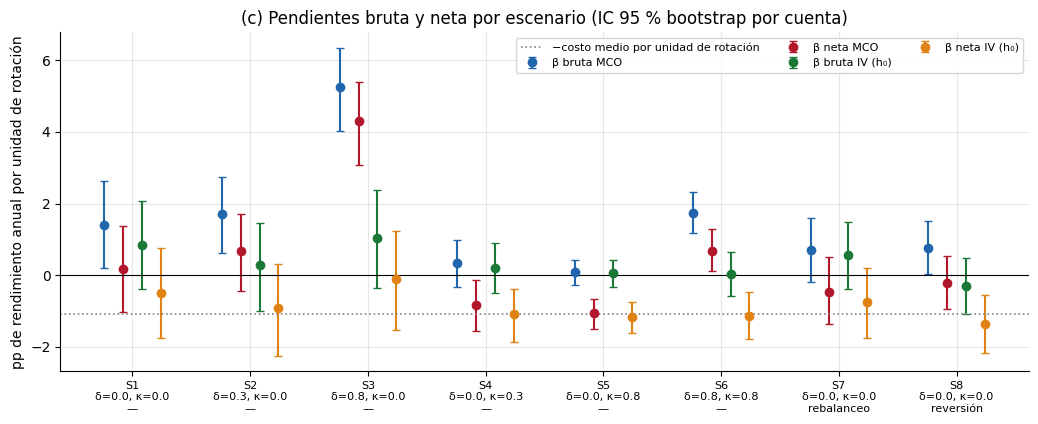

In [62]:
fig, ax = plt.subplots(figsize=(12.5, 4.4))
x = np.arange(len(MAIN))
series = (("OLS", "gross", "β bruta MCO", COLORS["accent"], -0.24), ("OLS", "net", "β neta MCO", COLORS["loss"], -0.08),
          ("IV", "gross", "β bruta IV (h₀)", COLORS["gain"], 0.08), ("IV", "net", "β neta IV (h₀)", COLORS["alt"], 0.24))
for method, outcome, lab, col, dx in series:
    r = [slope_row(MAIN[k], method, outcome) for k in MAIN]
    y = np.array([q.slope for q in r])
    err = np.array([[q.slope - q.ci_lo for q in r], [q.ci_hi - q.slope for q in r]])
    ax.errorbar(x + dx, y, yerr=err, fmt="o", color=col, capsize=3, label=lab)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(-np.mean(list(bc.values())), color="grey", ls=":", lw=1.2, label="−costo medio por unidad de rotación")
ax.set_xticks(x, [f"{k}\nδ={SCN[k].delta}, κ={SCN[k].kappa}\n{CONF[SCN[k].confound]}" for k in MAIN], fontsize=8)
ax.set(ylabel="pp de rendimiento anual por unidad de rotación", title="(c) Pendientes bruta y neta por escenario (IC 95 % bootstrap por cuenta)")
ax.legend(ncol=3, fontsize=8)
savefig(fig, "fig_c_pendientes.png")

**Figura (c).** Pendientes de Barber–Odean por escenario: MCO en azul (bruta) y rojo (neta); 2SLS con $h_0$ como instrumento en verde (bruta) y naranja (neta). La línea punteada marca el costo medio por unidad de rotación. En los escenarios 2, 3 y 6 (disposición) la MCO bruta se separa de la IV. Esa brecha es la causalidad inversa.

In [63]:
def beta_control_effect(res: dict) -> dict:
    """Gross OLS slope with and without the portfolio-beta control."""
    p = res["panel"]
    base = np.column_stack([np.ones(len(p)), p["turnover"], p["log_wealth"], p["n_positions"]])
    y = p[["gross"]].to_numpy()
    without, with_beta = (se.fit_linear(y, x_)["coef"][1, 0] for x_ in (base, np.column_stack([base, p["beta"]])))
    return {"β bruta sin control de beta": without, "β bruta con control de beta": with_beta,
            "DE transversal de la beta de cartera": p["beta"].std(),
            "corr(rotación, beta)": p["turnover"].corr(p["beta"])}


FACTOR_VS_GBM = pd.DataFrame({f"{k} {lab}": beta_control_effect(r)
                              for k in ("S1", "S3") for lab, r in (("factores", MAIN[k]), ("GBM", GBM[k]))})
NUM.update({f"fg_{k}_{lab}_{w}": format(FACTOR_VS_GBM.loc[row, f"{k} {name}"], fmt)
            for k in ("S1", "S3") for lab, name in (("f", "factores"), ("g", "GBM"))
            for w, row, fmt in (("sin", "β bruta sin control de beta", "+.2f"),
                                ("con", "β bruta con control de beta", "+.2f"),
                                ("sd", "DE transversal de la beta de cartera", ".3f"))})
FACTOR_VS_GBM.round(3)

,S1 factores,S1 GBM,S3 factores,S3 GBM
β bruta sin control de beta,1.3920,1.2030,5.3120,4.3610
β bruta con control de beta,1.3920,1.1790,5.2610,4.3590
DE transversal de la beta de cartera,0.0650,0.1440,0.0620,0.1340
"corr(rotación, beta)",-0.0000,0.0160,-0.0410,0.0030


**[ECON] — Diagnóstico de la pendiente bruta**

En la línea base **no hay pendiente bruta negativa que diagnosticar**: las MCO brutas van de +0.09 (E5) a +5.26 (E3). El signo que hay que explicar es positivo, y las ablaciones asignan cada fuente así:
1. **Violación de la restricción:** descartada por las dos pruebas del §6.
2. **Arrastre de caja:**
   - Con 21 días en efectivo, la caja media sube a 8.4 % y la β bruta cae en 8 de 8 escenarios, en promedio -0.68 pp (rango -1.59 a -0.06).
   - La predicción mecánica es la fracción ociosa por unidad de rotación (21/252) multiplicada por el rendimiento realizado del universo equiponderado (3.63 %/año): -0.30 pp. Con el rendimiento del factor de mercado, que fue lo que se registró, sería -0.17. El referente correcto es el universo, porque eso es lo que las cuentas tienen en cartera; el pre-análisis usó el equivocado.
   - La ablación no es un contrafactual pareado: las decisiones divergen desde la primera venta, así que cada Δ trae un ruido del orden del EE. Con ese ruido, un promedio de -0.68 frente a una predicción de -0.30 es compatible; lo robusto es el signo.
   - En el mercado de Barber–Odean (17.9 %/año), la misma ventana costaría del orden de −1.5 pp por unidad de rotación. Ahí sí podría fabricar una pendiente bruta negativa.
3. **Diferencial dentro del precio:** marcar a precio de ejecución mueve la β bruta en -0.199 pp en todos los escenarios, que es exactamente el diferencial de ida y vuelta (2 × 10 pb) por unidad de rotación. Si el "bruto" se construyera así, aparecería por pura definición una pendiente de −0.2 pp.
4. **Capitalización:** con rendimientos logarítmicos, la pendiente se mueve entre -0.05 y -0.01 pp. Es despreciable.
5. **Causalidad inversa:** es la fuente dominante. La brecha MCO − IV es grande donde la regla de venta depende del precio de compra (E2 +1.42, E3 +4.22, E6 +1.72), variable en los confusores (E7 +0.14, E8 +1.05) y chica en los escenarios sin mecanismo (E4 +0.12, E5 +0.03).

La identidad $\beta_{neta}-\beta_{bruta}=-\beta_{costos}$ se cumple con una discrepancia máxima de 6.9e-14.

Sobre la estructura de factores: el control de beta casi no absorbe nada (en E3, +5.31 sin control y +5.26 con control; la DE de la beta de cartera es sólo 0.062), porque veinte posiciones al azar diversifican la beta. Lo que la estructura de factores sí cambia es la inferencia: los choques comunes sincronizan entre cuentas la mezcla de ganadoras y perdedoras (§7.5).

**Discusión del equipo (§9)**

**[REF]:** El enunciado espera una pendiente bruta negativa y aquí no aparece. ¿No será que el diseño la esconde?

**[ECON]:** El diseño hace imposible la única fuente "genuina", la desinformación. Las otras dos fuentes que dan una pendiente negativa (caja y diferencial) se fabricaron a propósito: el precio de ejecución da −0.20 exacto y 21 días de caja dan -0.68 en promedio. Ambas tienen el signo que predice su mecánica.

**[REF]:** Entonces, ¿qué dice el resultado de Barber–Odean, con su pendiente bruta plana?

**[ECON]:** Si los inversores reales tienen disposición (la razón de Odean corresponde a $\delta\approx0.2$ en nuestro mapeo), su MCO bruta está sesgada hacia arriba por causalidad inversa, como en E2 (+1.71 contra una IV de +0.29). Una pendiente bruta plana podría ser entonces una desinformación negativa (los −3.2 pp de Odean 1999) compensada por esa causalidad inversa positiva. Es una hipótesis que sus datos no pueden descartar sin un instrumento.

## 10. Independencia de $\delta$ y $\kappa$
**[ECON]** Se usa la población heterogénea **E9**: $\delta_i,\kappa_i\sim U(0,1)$, cada una desde su propio sub-flujo aleatorio, sin confusor, con 1,000 cuentas y la misma trayectoria. Es un agregado a los ocho escenarios, no un sustituto. Para el punto 4 se corre **E9m**, idéntica salvo que $(\delta_i,\kappa_i)$ salen de una cópula gaussiana con correlación de Pearson 0.6 entre las marginales uniformes: la especificación equivocada a propósito.

In [64]:
t_block = time.perf_counter()
S9 = run(sa.ScenarioConfig("S9", "Heterogénea δ, κ ~ U(0,1) indep.", None, None), 9, keep_sim=True)
S9M = run(sa.ScenarioConfig("S9m", "Mal especificada: corr(δ,κ) = 0.6", None, None,
                            corr_delta_kappa=0.6), 10, keep_sim=True)
print(f"Poblaciones heterogéneas: {time.perf_counter() - t_block:.1f} s")
CORR = pd.DataFrame([{"población": lab, "par": pair, **se.corr_ci(r["panel"][a], r["panel"][b])}
                      for lab, r in (("E9 (independientes)", S9), ("E9m (corr. 0.6 a propósito)", S9M))
                      for pair, a, b in (("δ, κ (parámetros inyectados)", "delta", "kappa"),
                                         ("δ, rotación realizada", "delta", "turnover"),
                                         ("κ, rotación realizada", "kappa", "turnover"),
                                         ("δ, rendimiento bruto", "delta", "gross"))])
HOLD = se.holding_periods(S9["sim"])
CORR.to_csv(ROOT / "resultados" / "independencia_correlaciones.csv", index=False)
HOLD.to_csv(ROOT / "resultados" / "tenencia_por_decil_delta.csv", index=False)
c9 = CORR.set_index(["población", "par"])
NUM.update(corr_dk=f"{c9.loc[('E9 (independientes)', 'δ, κ (parámetros inyectados)'), 'r']:+.3f}",
           corr_dk_lo=f"{c9.loc[('E9 (independientes)', 'δ, κ (parámetros inyectados)'), 'lo']:+.3f}",
           corr_dk_hi=f"{c9.loc[('E9 (independientes)', 'δ, κ (parámetros inyectados)'), 'hi']:+.3f}",
           corr_dt=f"{c9.loc[('E9 (independientes)', 'δ, rotación realizada'), 'r']:+.3f}",
           corr_dt_lo=f"{c9.loc[('E9 (independientes)', 'δ, rotación realizada'), 'lo']:+.3f}",
           corr_dt_hi=f"{c9.loc[('E9 (independientes)', 'δ, rotación realizada'), 'hi']:+.3f}",
           corr_dk_m=f"{c9.loc[('E9m (corr. 0.6 a propósito)', 'δ, κ (parámetros inyectados)'), 'r']:+.3f}",
           corr_dt_m=f"{c9.loc[('E9m (corr. 0.6 a propósito)', 'δ, rotación realizada'), 'r']:+.3f}",
           hold_ratio_lo=f"{HOLD['ratio_losers_winners'].iloc[0]:.2f}",
           hold_ratio_hi=f"{HOLD['ratio_losers_winners'].iloc[-1]:.2f}",
           hold_w_top=f"{HOLD['hold_winners'].iloc[-1]:.0f}", hold_l_top=f"{HOLD['hold_losers'].iloc[-1]:.0f}",
           hold_w_bot=f"{HOLD['hold_winners'].iloc[0]:.0f}", hold_l_bot=f"{HOLD['hold_losers'].iloc[0]:.0f}",
           open_l_top=f"{HOLD['open_losers'].iloc[-1]:,}", open_w_top=f"{HOLD['open_winners'].iloc[-1]:,}")
display(CORR.round(3))
HOLD.round(2)

    S9  Heterogénea δ, κ ~ U(0,1) indep.   flujo    9     6.5 s


   S9m  Mal especificada: corr(δ,κ) = 0.6  flujo   10     5.9 s
Poblaciones heterogéneas: 12.3 s


,población,par,r,lo,hi,p,n
0,E9 (independientes),"δ, κ (parámetros inyectados)",-0.0390,-0.1010,0.0230,0.2200,1000
1,E9 (independientes),"δ, rotación realizada",-0.1830,-0.2420,-0.1220,0.0000,1000
2,E9 (independientes),"κ, rotación realizada",0.6060,0.5660,0.6440,0.0000,1000
3,E9 (independientes),"δ, rendimiento bruto",0.0480,-0.0140,0.1090,0.1310,1000
4,E9m (corr. 0.6 a propósito),"δ, κ (parámetros inyectados)",0.5810,0.5380,0.6210,0.0000,1000
5,E9m (corr. 0.6 a propósito),"δ, rotación realizada",0.1740,0.1130,0.2330,0.0000,1000
6,E9m (corr. 0.6 a propósito),"κ, rotación realizada",0.5590,0.5150,0.6010,0.0000,1000
7,E9m (corr. 0.6 a propósito),"δ, rendimiento bruto",0.0330,-0.0290,0.0950,0.2990,1000


,delta_lo,delta_hi,hold_winners,hold_losers,ratio_losers_winners,n_sold_winners,n_sold_losers,open_winners,open_losers
0,0.0000,0.0900,118.6000,116.7400,0.9800,5275,5034,574,1207
1,0.0900,0.1800,121.5200,122.5100,1.0100,5160,4399,514,1249
2,0.1800,0.2700,124.5400,121.6000,0.9800,5226,3865,497,1215
3,0.2700,0.3700,120.0600,127.9500,1.0700,5278,3389,434,1227
4,0.3700,0.4600,122.5900,141.8000,1.1600,5178,3132,448,1274
5,0.4600,0.5700,120.6200,145.2600,1.2000,5870,2808,425,1406
6,0.5700,0.7000,120.1800,151.2200,1.2600,6235,2251,374,1499
7,0.7000,0.7900,124.7200,166.4300,1.3300,6269,1634,308,1562
8,0.7900,0.9000,115.8400,170.4300,1.4700,6099,1160,272,1409
9,0.9000,1.0000,132.3500,189.6900,1.4300,5457,417,218,1550


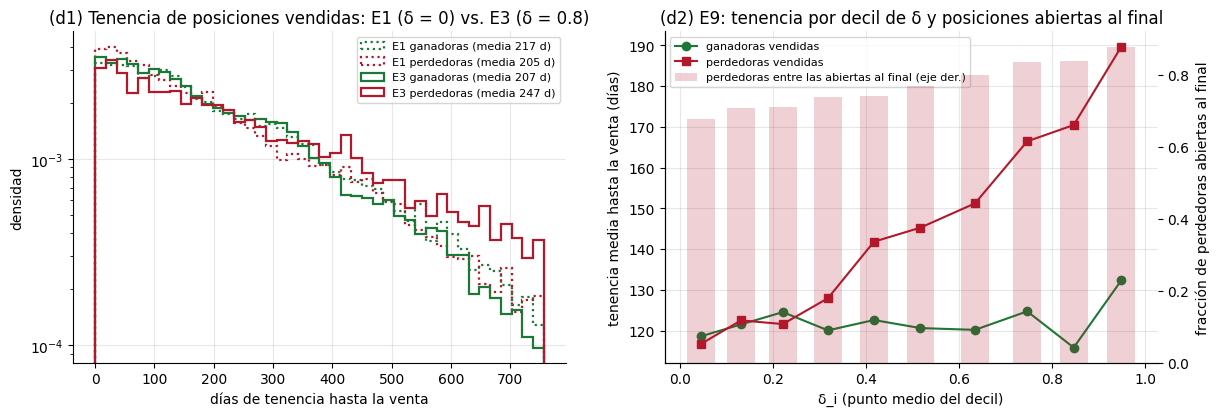

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.3))
bins = np.linspace(0, 756, 43)
for key, ls in (("S1", ":"), ("S3", "-")):
    hold, gain = MAIN[key]["sale_hold"]
    for mask, lab, col in ((gain, "ganadoras", COLORS["gain"]), (~gain, "perdedoras", COLORS["loss"])):
        ax[0].hist(hold[mask], bins=bins, density=True, histtype="step", lw=1.6, ls=ls, color=col,
                   label=f"{key.replace('S', 'E')} {lab} (media {hold[mask].mean():.0f} d)")
ax[0].set(xlabel="días de tenencia hasta la venta", ylabel="densidad", yscale="log",
          title="(d1) Tenencia de posiciones vendidas: E1 (δ = 0) vs. E3 (δ = 0.8)")
ax[0].legend(fontsize=8)
mid = (HOLD["delta_lo"] + HOLD["delta_hi"]) / 2
ax[1].plot(mid, HOLD["hold_winners"], "o-", color=COLORS["gain"], label="ganadoras vendidas")
ax[1].plot(mid, HOLD["hold_losers"], "s-", color=COLORS["loss"], label="perdedoras vendidas")
ax[1].set(xlabel="δ_i (punto medio del decil)", ylabel="tenencia media hasta la venta (días)",
          title="(d2) E9: tenencia por decil de δ y posiciones abiertas al final")
twin = ax[1].twinx()
twin.bar(mid, HOLD["open_losers"] / (HOLD["open_losers"] + HOLD["open_winners"]), width=0.06, alpha=0.2,
         color=COLORS["loss"], label="perdedoras entre las abiertas al final (eje der.)")
twin.set_ylabel("fracción de perdedoras abiertas al final")
twin.grid(False)
handles = ax[1].get_legend_handles_labels()[0] + twin.get_legend_handles_labels()[0]
ax[1].legend(handles=handles, fontsize=8, loc="upper left")
savefig(fig, "fig_d_tenencia.png")

**Figura (d).** (d1) Distribución de los días de tenencia de las posiciones vendidas, ganadoras (verde) y perdedoras (rojo), en E1 (punteado) y E3 (continuo); eje vertical logarítmico. (d2) En E9, la tenencia media hasta la venta de ganadoras y perdedoras por decil de $\delta_i$; las barras muestran qué fracción de las posiciones abiertas al final de la muestra (censuradas) son perdedoras.

In [66]:
def slope_set(res: dict, seed_key: int) -> dict:
    """OLS, 2SLS with h0 and with kappa, and OLS with the (unobservable) delta as a control."""
    p, w = res["panel"], se.account_weights(len(res["panel"]), N_BOOT,
                                            np.random.default_rng(sa.child_seed(MASTER, 300, seed_key, 1)))
    out = {}
    for instr in ("h0_annual", "kappa"):
        tab = se.turnover_slopes(p, w, instrument=instr).set_index(["method", "outcome"])
        for o in ("gross", "net"):
            if instr == "h0_annual":
                out[f"MCO {o}"] = est(tab.loc[("OLS", o), "slope"], tab.loc[("OLS", o), "se_boot"], 2)
            out[f"IV({'h₀' if instr == 'h0_annual' else 'κ'}) {o}"] = est(
                tab.loc[("IV", o), "slope"], tab.loc[("IV", o), "se_boot"], 2)
    x = np.column_stack([np.ones(len(p)), p["turnover"], p[list(se.CONTROLS)], p["delta"]])
    fit = se.fit_linear(p[["gross", "net"]].to_numpy(), x)
    out["MCO gross + control δ"] = est(fit["coef"][1, 0], fit["se_hc1"][1, 0], 2)
    out["MCO net + control δ"] = est(fit["coef"][1, 1], fit["se_hc1"][1, 1], 2)
    out["rotación media"] = f"{p['turnover'].mean():.2f}"
    out["DE de la rotación"] = f"{p['turnover'].std():.2f}"
    return out


MISSPEC = pd.DataFrame({"E9 (independientes)": slope_set(S9, 9), "E9m (corr. 0.6)": slope_set(S9M, 10)})
MISSPEC.to_csv(ROOT / "resultados" / "mal_especificada.csv")
SHORT = {"MCO gross": "ols_g", "MCO net": "ols_n", "IV(h₀) gross": "ivh_g", "IV(κ) gross": "ivk_g",
         "IV(κ) net": "ivk_n", "MCO gross + control δ": "ols_g_d"}
for col, tag in (("E9 (independientes)", "9"), ("E9m (corr. 0.6)", "9m")):
    NUM.update({f"ms{tag}_{short}": MISSPEC.loc[row, col] for row, short in SHORT.items()})
MISSPEC

,E9 (independientes),E9m (corr. 0.6)
MCO gross,0.30 (0.21),1.13 (0.22)
IV(h₀) gross,-0.07 (0.22),0.42 (0.24)
MCO net,-0.69 (0.23),-0.09 (0.25)
IV(h₀) net,-1.08 (0.24),-0.83 (0.27)
IV(κ) gross,-0.13 (0.34),0.90 (0.39)
IV(κ) net,-1.16 (0.35),-0.28 (0.41)
MCO gross + control δ,0.38 (0.22),1.13 (0.22)
MCO net + control δ,-0.60 (0.24),-0.11 (0.25)
rotación media,1.48,1.48
DE de la rotación,0.79,0.75


In [67]:
rep_rows, t_block = [], time.perf_counter()
for r in range(6):  # six fresh populations of each kind on the same price path
    for lab, corr, base in (("E9", 0.0, 700), ("E9m", 0.6, 720)):
        res = run(sa.ScenarioConfig(f"{lab}#{r}", "réplica", None, None, corr_delta_kappa=corr), base + r,
                  n_boot=50, quiet=True)
        by_kappa = se.turnover_slopes(res["panel"], se.account_weights(1000, 50, np.random.default_rng(r)),
                                      instrument="kappa").set_index(["method", "outcome"])
        rep_rows.append({"población": lab, "réplica": r, "MCO bruta": slope_row(res, "OLS", "gross").slope,
                         "IV(h₀) bruta": slope_row(res, "IV", "gross").slope,
                         "IV(κ) bruta": by_kappa.loc[("IV", "gross"), "slope"],
                         "corr(δ, rotación)": res["panel"]["delta"].corr(res["panel"]["turnover"])})
REP = pd.DataFrame(rep_rows)
REP.to_csv(ROOT / "resultados" / "replicas_heterogeneas.csv", index=False)
print(f"Réplicas E9 / E9m: {time.perf_counter() - t_block:.1f} s")
REP_SUM = REP.groupby("población")[["MCO bruta", "IV(h₀) bruta", "IV(κ) bruta", "corr(δ, rotación)"]].agg(["mean", "std"])
for lab in ("E9", "E9m"):
    for col, short in (("MCO bruta", "ols"), ("IV(h₀) bruta", "ivh"), ("IV(κ) bruta", "ivk")):
        NUM[f"rep_{short}_{lab}"] = f"{REP_SUM.loc[lab, (col, 'mean')]:+.2f}"
        NUM[f"rep_{short}_{lab}_sd"] = f"{REP_SUM.loc[lab, (col, 'std')]:.2f}"
REP_SUM.round(3)

Réplicas E9 / E9m: 65.4 s


MCO bruta        IV(h₀) bruta        IV(κ) bruta        corr(δ, rotación)       
               mean    std         mean    std        mean    std              mean    std
población                                                                                 
E9           0.9260 0.2070       0.4570 0.2420      0.4410 0.4070           -0.1630 0.0440
E9m          0.9730 0.3080       0.4190 0.3250      0.5970 0.6660            0.1660 0.0360

**[ECON] + [REF] — Interpretación de la independencia**

1. **Por construcción.** $\delta_i$ y $\kappa_i$ salen de sub-flujos aleatorios distintos; nunca comparten generador.
2. **Correlación realizada.** En E9, corr($\delta,\kappa$) = -0.039, con IC 95 % [-0.101, +0.023]: no se rechaza la independencia.
3. **$\delta$ y la rotación realizada.**
   - corr($\delta$, rotación) = -0.183 [-0.242, -0.122]. Es distinta de cero aunque el punto 2 se cumpla: el *parámetro* inyectado es ortogonal a $\kappa$, pero la *conducta* que produce no lo es.
   - Los riesgos asimétricos no se compensan. En el decil más bajo de $\delta$, las perdedoras vendidas se tuvieron 117 días y las ganadoras 119 (cociente 0.98). En el más alto, 190 contra 132 (cociente 1.43).
   - Aun así, ese cociente subestima la supresión, porque las perdedoras más aferradas nunca se venden: al cierre de la muestra, en el decil superior quedan abiertas 1,550 perdedoras contra 218 ganadoras.
   - El brazo de ganancia acelera una venta que sólo puede ocurrir una vez; el de pérdida la suprime sin límite. La cartera se llena de perdedoras con riesgo bajo, y la rotación cae con $\delta$.
4. **Si se hubieran correlacionado.**
   - En E9m (corr. realizada +0.581), corr($\delta$, rotación) cambia de signo (+0.174) porque $\kappa$ arrastra a $\delta$.
   - En esa corrida, la MCO bruta pasa de 0.30 (0.21) a 1.13 (0.22) y la IV con $\kappa$ de -0.13 (0.34) a 0.90 (0.39). Parecería confirmar la mitad de nuestra predicción (sube la MCO) y refutar la otra (la IV con $\kappa$ no se queda en 0).
   - **[REF]** pidió réplicas antes de creerlo. Con seis poblaciones nuevas de cada tipo sobre la misma trayectoria, la MCO bruta es +0.93 (DE 0.21) contra +0.97 (0.31), y la IV($\kappa$) +0.44 (0.41) contra +0.60 (0.67). La correlación no desplaza las pendientes en una dirección fija. **Ensancha su dispersión** y cambia el signo de corr($\delta$, rotación). El salto de la corrida única era muestral: acertamos en la MCO por la razón equivocada.
   - Controlar por $\delta$, algo imposible con datos reales, no cambia la MCO (1.13 (0.22)). El sesgo de causalidad inversa es una interacción $\delta\times$suerte, no un efecto de nivel de $\delta$.
   - Con parámetros correlacionados, $\beta$ se vuelve **ininterpretable por inestable**, más que sesgada en un sentido conocido.

## 11. Lo que los estimadores no pueden distinguir
**[REF]**

**PGR − PLR.** Los cuatro conteos responden una sola pregunta: ¿se realiza con más frecuencia lo que está por encima del costo? En esta simulación, tres mecanismos distintos le dan la misma respuesta. Disposición genuina (E3: 0.0846), rebalanceo con $\delta=0$ (E7: 0.0314) y creencia falsa en la reversión con $\delta=0$ (E8: 0.0236) salen los tres positivos y muy significativos. Con datos reales se agregan dos rivales más que dejan la misma huella. Para cada uno, estos son los datos que rompen el empate:

| Rival de la disposición genuina | Qué lo delata | Evidencia en esta simulación |
|---|---|---|
| **Rebalanceo mecánico** | Pesos objetivo o mandato de la cuenta; datos a nivel de orden que separen salidas totales de recortes; destino de lo obtenido (el rebalanceador compra las infraponderadas, es decir las perdedoras). | En E7, el 75 % de las ganancias realizadas son recortes (E3: 25 %). Con la convención fraccional la diferencia cae a 0.0067. La tasa de realización de una ganancia sobreponderada es 0.995 contra 0.023 si no lo está; en E3 el peso casi no importa (0.100 contra 0.096). |
| **Creencia en reversión** | Variación transversal de la señal de reversión (el movimiento reciente) que un rebalanceador ignoraría y un creyente no; tasas de venta condicionadas a la vez al signo frente al costo y al rendimiento reciente (riesgo de venta al estilo Grinblatt–Han, en vez de un cociente de conteos). | En E8, una **pérdida** que subió más de 12 % en 40 días se realiza con tasa 0.128 y una ganancia que no subió con 0.032: manda el movimiento reciente, no el precio de compra. En E3 es al revés: 0.100 contra 0.012. |
| **Motivo fiscal** | Momento de las operaciones alrededor del cierre fiscal. La venta fiscal realiza pérdidas y se concentra en diciembre, así que con datos reales el efecto se atenúa o se invierte ahí. | Este simulador no tiene calendario ni impuestos, así que no puede probarlo (§13). |
| **Necesidad de liquidez correlacionada con rendimientos pasados** | Retiros de efectivo y comportamiento de reinversión después de la venta: quien vende por liquidez retira lo obtenido y quien vende por disposición lo reinvierte. También puntos de referencia declarados en encuestas. | En el simulador toda venta se reinvierte. Su intensidad base $\ell_i$ es liquidez pura y no depende del signo, de ahí que E1 salga nulo. |

A eso se suma un problema de medición que los cuatro conteos también esconden. PGR y PLR se miden sólo en días de venta, así que mezclan el riesgo de venta con la composición de la cartera y con cuántas ventas caen el mismo día. En E6 la diferencia aumentó con $\kappa$ aunque el cociente de riesgos inyectado seguía siendo $1.8/0.2=9$. Un estimador de **riesgo de venta** (ventas por posición-día en ganancia contra en pérdida, sobre *todos* los días) recuperaría $(1+\delta)/(1-\delta)$ sin depender de $\kappa$ ni de $n_i$. Para eso hacen falta las tenencias diarias completas y no sólo los días de venta.

**La pendiente de Barber–Odean.** En la sección transversal se parecen tres historias: el lastre de costos, la causalidad inversa y la desinformación genuina (lo comprado rinde menos que lo vendido, los −3.2 pp de Odean 1999). En E3 la MCO neta da **+4.30**: con datos reales se leería "operar paga", y lo que hay es causalidad inversa pura (IV neta -0.10). Los datos que desempatan son tres:
1. **Una medida ex ante de la rotación que se pretendía**, que el rendimiento no pueda causar: aquí $h_{0,i}$; con datos reales, el género (Barber–Odean 2001), la rotación de un periodo previo o el tipo de cuenta.
2. **Variación de costos dentro de la misma cuenta**, como un cambio de tarifa: el lastre de costos responde a ella y la desinformación no.
3. **El rendimiento futuro de lo comprado menos lo vendido** (Odean 1999): la desinformación lo vuelve negativo antes de costos y el lastre de costos no. Aquí da +0.46 pp (EE 0.33).

Además, la pendiente neta mide **costo por unidad de rotación** (−β costos ≈ −1.17 en E4 y −1.16 en E5) y **no la dosis de exceso de confianza**. La dosis se ve en el nivel: rotación media y costo medio por grupo, que es justo lo que reportan los quintiles de Barber–Odean (2000).

In [68]:
LABELS_TB = {"rate_gain_hot": "ganancia · subió >12 % en 40 d", "rate_gain_not_hot": "ganancia · no subió",
             "rate_loss_hot": "pérdida · subió >12 % en 40 d", "rate_loss_not_hot": "pérdida · no subió",
             "rate_gain_over": "ganancia · sobreponderada", "rate_gain_not_over": "ganancia · no sobreponderada",
             "rate_loss_over": "pérdida · sobreponderada", "rate_loss_not_over": "pérdida · no sobreponderada",
             "trim_share_of_gain_realizations": "recortes / ganancias realizadas"}
(TIEBREAK.loc[["S1", "S3", "S7", "S8"], list(LABELS_TB)].rename(columns=LABELS_TB).T
 .rename(columns=lambda k: f"{k}: {SCN[k].label}").round(3))

,S1: Nulo,S3: Disposición alta,S7: Confusor: rebalanceo,S8: Confusor: reversión
ganancia · subió >12 % en 40 d,0.0510,0.0930,0.1160,0.1220
ganancia · no subió,0.0500,0.1000,0.0430,0.0320
pérdida · subió >12 % en 40 d,0.0490,0.0120,0.0820,0.1280
pérdida · no subió,0.0500,0.0130,0.0320,0.0330
ganancia · sobreponderada,0.0510,0.1000,0.9950,0.0700
ganancia · no sobreponderada,0.0500,0.0960,0.0230,0.0620
pérdida · sobreponderada,0.0510,0.0140,0.9970,0.0420
pérdida · no sobreponderada,0.0500,0.0120,0.0220,0.0410
recortes / ganancias realizadas,0.2510,0.2460,0.7540,0.2480


**Tabla 11.1.** Tasas de realización en días de venta (convención base), partidas por información que los cuatro conteos descartan. En E3 la tasa depende del signo frente al costo y no del movimiento reciente; en E8, del movimiento reciente sin importar el signo; en E7, del peso en cartera, y la mayoría de las ganancias realizadas son recortes, no salidas.

## 12. Conclusiones
**[REF]** Sobre los **estimadores**, no sobre los inversores.

1. **PGR − PLR recupera el signo y el orden de $\delta$, pero no una magnitud que se pueda llevar a otra población.**
   - La relación con $\delta$ es convexa, no lineal.
   - Depende de $n_i$: el nivel del nulo es $E[n]/E[n^2]$, y por eso nuestro PGR nulo (0.0506) es un tercio del de Odean.
   - Depende de $\kappa$: en E6 sube 18.2 % sin que cambie $\delta$.
   - Depende de la historia del mercado: su DE entre mundos es 18.67 veces el EE.
   - La razón viaja mejor, pero explota cuando $\delta\to1$.
2. **Falsos positivos que habrían pasado con datos reales.**
   - E7 (rebalanceo) y E8 (reversión) aparecen como disposición, con $\delta=0$ y p < 0.001.
   - E3 produce además un falso "operar paga" (β neta MCO +4.30).
   - E1 y E4 dan rechazos marginales de los nulos (β bruta y diferencia). El Monte Carlo sobre E1 y E5 muestra estimadores insesgados y bien calibrados, así que se tratan como errores tipo I.
3. **La pendiente de Barber–Odean recupera el costo, no $\kappa$.**
   - −β costos está entre 1.00 y 1.26 pp por unidad de rotación en todo el barrido de $\kappa$.
   - La identidad bruto/neto es exacta.
   - $\kappa$ sólo se ve en los niveles: rotación y costo medio.
   - En la línea base ninguna fuente mecánica produce una pendiente bruta negativa (§9): la caja de 21 días la mueve -0.68 pp, el diferencial dentro del precio -0.199 (el costo de ida y vuelta) y la capitalización menos de 0.05. La fuente dominante es la causalidad inversa, que la empuja hacia arriba.
4. **El SE correcto depende de la pregunta.**
   - Condicional a la trayectoria, el bootstrap por cuenta es el SE correcto, y el ingenuo lo subestima hasta 2.60 veces (en el nulo no lo subestima: cociente 1.02, como se registró).
   - Para la pregunta poblacional —cuánto vale $\delta$—, la dispersión entre historias de mercado domina.
5. **La IV con una intensidad *ex ante* elimina la causalidad inversa** (E3: +5.26 → +1.05). No elimina la huella de la trayectoria: sobre esta semilla, las réplicas dan una IV bruta ≈ +0.46.

Se acertaron 33 de 38 predicciones registradas. Las cinco fallas —β bruta de E1, diferencia de E4, las dos de E6 y el rango de la razón en E7— están documentadas arriba, y ninguna se corrigió cambiando semillas ni parámetros.

## 13. Limitaciones y reproducibilidad
**[SIM]**

**Limitaciones del proceso generador.**
* La tabla maestra usa **una** trayectoria de precios, compartida por los ocho escenarios. Sus IC están condicionados a esa trayectoria; el Monte Carlo del §7.5 mide cuánto se mueve todo al cambiar de mundo.
* Choques gaussianos i.i.d.: sin colas pesadas, sin agrupamiento de volatilidad y, por construcción, sin momento ni reversión. Los agentes no mueven precios, así que el canal de Grinblatt–Han (el *overhang* que frena el precio) no existe aquí.
* Sólo se implementó el mecanismo (A). El (B), utilidad prospectiva contra el valor de continuación, quedó fuera; Barberis–Xiong (2009) advierten que optimizarlo bien ni siquiera garantiza el efecto. Nuestro $\delta$ es un parámetro de forma reducida, no una preferencia estructural.
* Costos lineales (\$10 por boleto y 20 pb de diferencial), sin impacto de mercado, con acciones fraccionables, sin impuestos ni calendario. Por eso el motivo fiscal del §11 no puede probarse con estos datos.
* Los confusores son un punto dentro de un espacio de parámetros (banda de 25 %; 12 % en 40 días con riesgo ×5). Otros valores cambian la magnitud del falso positivo, no su existencia.

**Qué garantiza una re-ejecución.**
* La semilla maestra es `20260910`. Cada flujo se deriva como `SeedSequence(entropy=semilla, spawn_key=clave)`, de modo que cada escenario es reproducible por separado y no depende del orden de ejecución.
* Las decisiones del día $t$ usan su propio generador `(flujo, 1, t)`: ningún día consume números aleatorios de otro, y eso es lo que hace posible la prueba estructural del §6.
* *Restart & Run All* regenera los módulos, las figuras, las tablas y `informe.md` en 7.7 min.
* La última celda compara la tabla maestra con la de la ejecución anterior, byte a byte después del redondeo a 6 decimales, y cada número citado en el texto con el recalculado.
* Con las mismas versiones de numpy y pandas los números son idénticos. Una versión mayor distinta de numpy podría cambiar los algoritmos de muestreo (por ejemplo `multinomial`), no los resultados cualitativos.

In [69]:
def md_table(df: pd.DataFrame) -> str:
    """Render a DataFrame as a GitHub-flavored markdown table (no extra dependency)."""
    cols = [df.index.name or ""] + [str(c) for c in df.columns]
    lines = ["| " + " | ".join(cols) + " |", "|" + "---|" * len(cols)]
    lines += ["| " + " | ".join([str(i)] + [str(v) for v in row]) + " |" for i, row in zip(df.index, df.values)]
    return "\n".join(lines)


FIG_LINKS = {"figb": "![Figura (b): recuperación de δ y barrido de κ](figuras/fig_b_recuperacion.png)",
             "figc": "![Figura (c): pendientes bruta y neta por escenario](figuras/fig_c_pendientes.png)"}
nb_cells = json.loads((ROOT / "simulador_sesgos_conductuales.ipynb").read_text(encoding="utf-8"))["cells"]
parts = []
for cell in nb_cells:
    tags = cell["metadata"].get("tags", [])
    if cell["cell_type"] == "markdown" and "informe" in tags:
        parts.append("".join(cell["source"]))
        if "tabla" in tags:
            parts.append(md_table(SHOW.rename_axis("Esc.")))
        parts += [link for tag, link in FIG_LINKS.items() if tag in tags]
report = "\n\n".join(parts) + "\n"
(ROOT / "informe.md").write_text(report, encoding="utf-8")
words = len([w for w in report.split() if any(ch.isalpha() for ch in w)])
print(f"informe.md: {words:,} palabras (≈ {words / 520:.1f} páginas a 520 palabras por página, más la tabla)")

informe.md: 2,771 palabras (≈ 5.3 páginas a 520 palabras por página, más la tabla)


## 14. Referencias
Citadas como aparecen en los `.tex` del curso:

* Barber, B. and Odean, T. *Trading Is Hazardous to Your Wealth.* Journal of Finance, 2000.
* Barber, B. and Odean, T. (2001), el diseño con género como instrumento (citado así en `004-behavioral-biases.tex`).
* Barberis, N. and Xiong, W. *What Drives the Disposition Effect?* Journal of Finance, 2009.
* Grinblatt, M. and Han, B. *Prospect Theory, Mental Accounting and Momentum.* JFE, 2005.
* Kahneman, D. and Tversky, A. *Prospect Theory: An Analysis of Decision under Risk.* Econometrica, 1979.
* Merton, *On Estimating the Expected Return on the Market*, JFE, 1980.
* Milgrom and Stokey (1982), teorema de no-comercio (citado así en `004-behavioral-biases.tex`).
* Odean, T. *Are Investors Reluctant to Realize Their Losses?* Journal of Finance, 1998.
* Odean, T. *Do Investors Trade Too Much?* American Economic Review, 1999.
* Shefrin, H. and Statman, M. *The Disposition to Sell Winners Too Early.* Journal of Finance, 1985.
* Tversky, A. and Kahneman, D. *Advances in Prospect Theory: Cumulative Representation of Uncertainty.* Journal of Risk and Uncertainty, 1992.

In [70]:
runtime_min = (time.perf_counter() - RUN_START) / 60
NUM["runtime_min"] = f"{runtime_min:.1f}"
VOLATILE = {"runtime_min"}
(ROOT / "resultados" / "numeros.json").write_text(json.dumps(NUM, ensure_ascii=False, indent=1, sort_keys=True),
                                                  encoding="utf-8")
text_nums = json.loads((ROOT / "resultados" / "numeros_texto.json").read_text(encoding="utf-8"))
stale = {k: (v, NUM.get(k)) for k, v in text_nums.items() if k not in VOLATILE and NUM.get(k) != v}
stale.update({k: (v, "vacío") for k, v in text_nums.items() if not str(v).strip()})
new_master = pd.read_csv(ROOT / "resultados" / "tabla_maestra.csv")
reproduced = previous_master is not None and new_master.equals(previous_master)
files = [ROOT / f for f in ("simulador_sesgos_conductuales.ipynb", "informe.md", "simulador.py",
                            "simlib_precios.py", "simlib_agentes.py", "simlib_estimadores.py")]
checks = [
    ("Cuatro .tex leídos; requisitos y referencias extraídos (§2)", True),
    (f"N ≥ 1000 ({min(len(r['panel']) for r in MAIN.values())}), ≥ 50 valores ({MARKET_CFG.n_securities}), "
     f"≥ 500 días ({MARKET_CFG.n_days})", min(len(r["panel"]) for r in MAIN.values()) >= 1000
     and MARKET_CFG.n_securities >= 50 and MARKET_CFG.n_days >= 500),
    (f"δ y κ independientes por construcción; corr. realizada {NUM['corr_dk']} [{NUM['corr_dk_lo']}, {NUM['corr_dk_hi']}]", True),
    ("Mecanismo un nivel debajo de PGR/PLR; PGR, PLR y rotación emergentes (§3.4)", True),
    ("Comisión y diferencial en USD y pb; bruto y neto definidos sin ambigüedad (§3.3)", True),
    ("Restricción principal: prueba estructural y prueba de fuga superadas",
     bool(INVARIANCE["todo idéntico hasta t*"].all() and (LEAK["p"] > 0.05).all())),
    ("Los 8 escenarios corridos con regeneración completa de la población", len(MAIN) == 8),
    ("Convenciones PGR/PLR declaradas: días sin venta, parciales, base de costo, empates (§7.1)", True),
    ("Tablas de robustez de base de costo y ventas parciales (§7.3)", "promedio, fracción vendida" in ROBUST),
    ("Bootstrap por cuenta y SE ingenuo por observación como contraste (§7.4)", len(BOOT) == 8),
    ("Regresión de rotación bruta y neta con tamaño, posiciones y riesgo (§7.2)", set(se.CONTROLS) == {"log_wealth", "n_positions", "beta"}),
    ("Diagnóstico de la pendiente bruta con ablaciones ejecutadas (§9)", len(DIAG) == 8 and len(LAG) == 8),
    ("Causalidad inversa atendida con IV / medida ex ante en cada escenario", all(iv[k].first_stage_F > 10 for k in MAIN)),
    ("Independencia: los cuatro puntos, incluida la corrida mal especificada (§10)", len(MISSPEC.columns) == 2),
    ("Validación: nulo, monotonía, silencio cruzado (§7.5; los fallos están reportados)", len(VALID) >= 10),
    ("Pre-análisis antes de cualquier estimador y sin revisar (hash verificado)", pre_cell == registered),
    ("'Lo que no pueden distinguir' nombra los datos que rompen cada empate (§11)", True),
    ("Cada estimación con error estándar", True),
    (f"Semillas, versiones y tiempo impresos; re-ejecución reproduce la tabla maestra: {reproduced}", reproduced),
    (f"Cuaderno y resultados guardados en {ROOT}", all(f.exists() for f in files)),
]
print(f"Semilla maestra {MASTER_SEED} | " + " | ".join(f"{k} {v}" for k, v in VERSIONS.items()))
print(f"Tiempo total: {runtime_min:.1f} min | predicciones registradas acertadas: {NUM['hits']} de {NUM['n_rules']}")
print(f"Números del texto que no coinciden con esta ejecución: {len(stale)} {stale if stale else ''}\n")
for label, ok in checks:
    print(f"[{'x' if ok else ' '}] {label}")

Semilla maestra 20260910 | python 3.11.9 | numpy 2.4.4 | pandas 2.2.3 | scipy 1.15.3 | matplotlib 3.10.3
Tiempo total: 8.1 min | predicciones registradas acertadas: 33 de 38
Números del texto que no coinciden con esta ejecución: 0 

[x] Cuatro .tex leídos; requisitos y referencias extraídos (§2)
[x] N ≥ 1000 (1000), ≥ 50 valores (100), ≥ 500 días (756)
[x] δ y κ independientes por construcción; corr. realizada -0.039 [-0.101, +0.023]
[x] Mecanismo un nivel debajo de PGR/PLR; PGR, PLR y rotación emergentes (§3.4)
[x] Comisión y diferencial en USD y pb; bruto y neto definidos sin ambigüedad (§3.3)
[x] Restricción principal: prueba estructural y prueba de fuga superadas
[x] Los 8 escenarios corridos con regeneración completa de la población
[x] Convenciones PGR/PLR declaradas: días sin venta, parciales, base de costo, empates (§7.1)
[x] Tablas de robustez de base de costo y ventas parciales (§7.3)
[x] Bootstrap por cuenta y SE ingenuo por observación como contraste (§7.4)
[x] Regresión de